In [1]:
import numpy as np
import skexplain
import seaborn as sns
import plotting_config
import matplotlib as mpl
import itertools
import scipy
import xarray as xr
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor

In [2]:
from time_series_deconfounder import *
from utils.evaluation_utils import load_data, save_data
from loguru import logger

2025-12-26 07:04:24.471971: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-26 07:04:24.516830: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-26 07:04:25.234769: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
INFO:Using GPU with memory growth
2025-12-26 07:04:26.041928: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46289 MB memory:  

Number of devices: 1


In [3]:
# useful function
def _get_centres(x):
    return (x[1:] + x[:-1]) / 2

def _check_two_ints(values):
    if isinstance(values, (int, np.integer)):
        values = (values, values)
    elif len(values) == 1:
        values = (values[0], values[0])
    elif len(values) != 2:
        raise ValueError(
            "'{}' values were given. Expected at most 2.".format(len(values))
        )

    if not all(isinstance(n_bin, (int, np.integer)) for n_bin in values):
        raise ValueError(
            "All values must be an integer. Got types '{}' instead.".format(
                {type(n_bin) for n_bin in values}
            )
        )
    return values

## 0. Data Preprocessing

### 0.0 复习一下

目前变量情况： config = {'covariate_cols':['gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6', 'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density', 'entropy','flow','temperature','percipit'], 'treatment_cols':['conformity', ,'E1','E2'],

In [4]:
dataset = load_data("../data/sample_32w_add_final.h5")
for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(981651, 161, 23)
float32
outcomes
(981651, 161, 1)
float32
previous_covariates
(981651, 160, 23)
float32
previous_treatments
(981651, 160, 3)
float32
sequence_length
(981651,)
int64
treatments
(981651, 161, 3)
float32


In [5]:
# 删除previous_covariates和previous_treatments两个key
# 删除 previous_treatments 键和其数据
if 'previous_treatments' in dataset:
    del dataset['previous_treatments']

# 删除 previous_covariates 键和其数据
if 'previous_covariates' in dataset:
    del dataset['previous_covariates']

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(981651, 161, 23)
float32
outcomes
(981651, 161, 1)
float32
sequence_length
(981651,)
int64
treatments
(981651, 161, 3)
float32


把它改成：

config = {'covariate_cols':['gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6',
           'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density',
                           'entropy','flow','temperature','percipit','E1','E2'],
            'treatment_cols':['conformity'],
* 也就是把政策项E1、E2放到协变量中

In [6]:
# 将政策变量加入covariate和previous_covariates
policy_columns = dataset['treatments'][:, :, -2:]

# 将这两列合并到 covariates 的最后
dataset['covariates'] = np.concatenate((dataset['covariates'], policy_columns), axis=2)

# 从 treatments 删除最后两列
dataset['treatments'] = dataset['treatments'][:, :, :-2]

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(981651, 161, 25)
float32
outcomes
(981651, 161, 1)
float32
sequence_length
(981651,)
int64
treatments
(981651, 161, 1)
float32


In [7]:
save_data("../data/sample_32w_add.h5", dataset)

Finish ../data/sample_32w_add.h5!


### 获取32,000人的三年数据

In [4]:
def obtain_dataset(dataset, column_index, selection=1):
        dataset_part = {}
        selected_indices = np.where(dataset['covariates'][:, :, column_index] == selection)[0]
        unique_selected_indices = np.unique(selected_indices)
        for key in dataset.keys():
            dataset_part[key] = dataset[key][unique_selected_indices]
        return dataset_part

In [6]:
dataset19 = obtain_dataset(dataset, 12)
dataset20 = obtain_dataset(dataset, 13)
dataset23 = obtain_dataset(dataset, 14)

In [13]:
# 定义函数根据索引选择数据集中的个体
def select_individuals(data, indices):
    return {key: data[key][indices] for key in data}

# 假设三个数据字典分别是dataset19, dataset20, dataset23
datasets = [dataset19, dataset20, dataset23]

# 分别对三个数据字典进行选择操作
# selected_datasets = [select_individuals(dataset, 32000) for dataset in datasets]
total_samples = dataset19['covariates'].shape[0]
random_indices = np.random.choice(total_samples, size=32000, replace=False)
selected_datasets = [select_individuals(dataset, random_indices) for dataset in datasets]

# 合并三个数据字典
combined_dataset = {
    'covariates': np.concatenate([d['covariates'] for d in selected_datasets], axis=0),
    'outcomes': np.concatenate([d['outcomes'] for d in selected_datasets], axis=0),
    'sequence_length': np.concatenate([d['sequence_length'] for d in selected_datasets], axis=0),  # 假设sequence_length在三年中是一致的
    'treatments': np.concatenate([d['treatments'] for d in selected_datasets], axis=0),
}

# 输出合并后的数据字典的形状
for key, value in combined_dataset.items():
    print(f"{key}: {value.shape}")

covariates: (96000, 161, 25)
outcomes: (96000, 161, 1)
sequence_length: (96000,)
treatments: (96000, 161, 1)


In [14]:
save_data("../data/sample_3w2_add.h5", combined_dataset)

Finish ../data/sample_3w2_add.h5!


生成超参稳健性的子样本数据集

In [ ]:
# 定义函数根据索引选择数据集中的个体
def select_individuals(data, indices):
    return {key: data[key][indices] for key in data}

# 假设三个数据字典分别是dataset19, dataset20, dataset23
datasets = [dataset19, dataset20, dataset23]

# 分别对三个数据字典进行选择操作
# selected_datasets = [select_individuals(dataset, 32000) for dataset in datasets]
total_samples = dataset19['covariates'].shape[0]
random_indices = np.random.choice(total_samples, size=10000, replace=False)
selected_datasets = [select_individuals(dataset, random_indices) for dataset in datasets]

# 合并三个数据字典
combined_dataset = {
    'covariates': np.concatenate([d['covariates'] for d in selected_datasets], axis=0),
    'outcomes': np.concatenate([d['outcomes'] for d in selected_datasets], axis=0),
    'sequence_length': np.concatenate([d['sequence_length'] for d in selected_datasets], axis=0),  # 假设sequence_length在三年中是一致的
    'treatments': np.concatenate([d['treatments'] for d in selected_datasets], axis=0),
}

# 输出合并后的数据字典的形状
for key, value in combined_dataset.items():
    print(f"{key}: {value.shape}")

In [9]:
save_data("../data/sample_1w.h5", combined_dataset)

Finish ../data/sample_1w.h5!


## 1. Feature Importance (Fig2.a)

* **基于ale标准差**

### 1.1 整体三年的特征相对重要性

In [3]:
# 导入数据
dataset = load_data("../data/sample_3w2_add.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(96000, 161, 23)
float32
outcomes
(96000, 161, 1)
float32
sequence_length
(96000,)
int64
treatments
(96000, 161, 1)
float32


In [5]:
save_data("../data/sample_3w2.h5", dataset)

Finish ../data/sample_3w2.h5!


In [5]:
# 模型编号
exp_name = "base_model_optimal_v2"

In [6]:
# 定义要计算的特征
features = ['conformity', 'gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6',
            'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density','temperature','percipit','E1','E2']

**计算每个特征的一阶 ALE（含分箱）与原始取值**

In [7]:
# 对每个特征分别计算其ale
def compute_ale_for_features(
    dataset,
    features,
    exp_name,
    *,
    n_sample=1000,
    treatment_feature_name="conformity",
    covariate_tensor_key="covariates",
    treatment_tensor_key="treatments",
):
    """
    返回：
      - ALE_1ST:        {feature -> np.ndarray (n_bins 或 [n_bootstrap, n_bins])}
      - ALE_1ST_bin:    {feature -> np.ndarray (分箱中心值)}
      - feature_values: {feature -> np.ndarray (原始特征取值, shape [N, T] 或已拉平)}
    """

    ALE_1ST, ALE_1ST_bin, feature_values = {}, {}, {}

    for feature in features:
    # for feature in ['conformity', 'gender','age','income','voluntary','festivals','edu','married','density','temperature','percipit']:
        # n_bootstrap = 1
        sub_dataset = dataset_sampling(dataset, n_sample)
        # for _ in range(n_bootstrap):
        _, ale_1st, quantiles_tmp = compute_ale(sub_dataset, f'rmsn_{exp_name}', b_use_predicted_confounders=False, features = [feature])
        ALE_1ST[feature] = ale_1st
        
        quantiles_tmp = (quantiles_tmp[:-1] + quantiles_tmp[1:]) / 2
        ALE_1ST_bin[feature] = quantiles_tmp
        
        if feature == 'conformity':
            feature_values[feature]=dataset['treatments'][:,:,0]
        else:
            feature_index = features.index(feature) - 1
            feature_value = dataset['covariates'][:,:,feature_index]
            # feature_values[feature] = np.repeat(feature_value, 3, axis=0)
            feature_values[feature] = feature_value
            
            
    for key in ALE_1ST.keys():
        ALE_1ST[key] = np.array(ALE_1ST[key])

    for key in ALE_1ST_bin.keys():
        ALE_1ST_bin[key] = np.array(ALE_1ST_bin[key])

    for key in feature_values.keys():
        feature_values[key] = np.array(feature_values[key])
    
    return ALE_1ST, ALE_1ST_bin, feature_values

**组装 xarray.Dataset（便于 skexplain 读取）**

In [8]:
# data transformation
def build_ale_xarray_dataset(
    ALE_1ST, ALE_1ST_bin, feature_values, features, *, model_name="RNN_Model"
):
# model_name = 'RNN_Model'

    data_vars = {}
    for feature in features:
    # for feature in ['conformity', 'gender','age','income','voluntary','festivals','edu','married','density','temperature','percipit']:
        ale = ALE_1ST[feature]
        if ale.ndim == 1:
            ale = ale[np.newaxis, :]
        data_vars[f"{feature}__{model_name}__ale"] = (["n_bootstrap", f"n_bins__{feature}"], ale)
        
        quantiles = ALE_1ST_bin[feature]
        data_vars[f"{feature}__bin_values"] = ([f"n_bins__{feature}"], quantiles)
        
        feature_value = feature_values[feature]
        if feature_value.ndim > 1:
            flattened_value = feature_value.reshape(-1)
        else:
            flattened_value = feature_value
        data_vars[feature] = (["n_X"], flattened_value)

        
    ale_1d_dataset = xr.Dataset(
        data_vars=data_vars,
        #coords={
        #    "n_bootstrap": np.arange(ale.shape[0]), 
        #    f"n_bins__{feature_name}": np.arange(quantiles.shape[0]),  
        #    "n_X": np.arange(flattened_values.shape[0]),  
        #},
        attrs={
            "estimator_output": "raw",
            "estimators used": [model_name],
            "method": "ale",
            "dimension": "1D",
            "features used": features,
        }
    )

    for key in feature_values.keys():
        if feature_values[key].ndim > 1:
            feature_values[key] = feature_values[key].reshape(-1)
        feature_values[key] = pd.Series(feature_values[key])

    X = pd.DataFrame()
    X = X.assign(**feature_values)

    y = pd.Series(dataset['outcomes'][:,:,0].flatten())

    return ale_1d_dataset, X, y

**计算 ALE 方差 + 画图**

In [9]:
def ale_variance_and_plot(
    X,
    y,
    ale_1d_dataset,
    *,
    model_name="RNN_Model",
    extra_estimators=(),
    figsize=(8, 6),
    ax=None,
    show_topN=None, # take None or [start:stop]
    save_path="./figures/fig_1a_feature_importance_all_var.png",
    show=True,
):
    """
    执行：
      1) 计算 ALE 方差（特征重要性）
      2) 绘制水平条形图并保存
    返回：
      - ale_var_result: skexplain 的结果字典
    """
    estimators = (model_name, *extra_estimators)
    explainer = skexplain.ExplainToolkit(estimators=estimators, X=X, y=y)
    ale_var_result = explainer.ale_variance(ale=ale_1d_dataset)

    # 取排名和分数
    features_ale_var = ale_var_result['ale_variance_rankings__RNN_Model']
    scores_ale_var = ale_var_result['ale_variance_scores__RNN_Model'][:,0]

    if show_topN is not None:
        if isinstance(show_topN, (list, tuple)) and len(show_topN) == 2:
            start, stop = show_topN
            features_ale_var = features_ale_var[start:stop]
            scores_ale_var = scores_ale_var[start:stop]
        else:
            raise ValueError("show_topN 必须是形如 [start, stop] 的列表或元组，例如 [0, 10]")

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # 画图（保持你原有风格）
    palette = sns.cubehelix_palette(n_colors=len(features_ale_var), reverse=True)

    bars = ax.barh(features_ale_var, scores_ale_var, color=palette)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va='center', ha='left')

    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_xlim(0, float(scores_ale_var.max()) * 1.1 if len(scores_ale_var) else 1.0)
    ax.grid(True, linestyle='--', linewidth=0.5, which='major', axis='x')
    ax.tick_params(axis='both', which='major', labelsize=10, tick1On=False, tick2On=False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    if show:
        plt.show()

    return ale_var_result, fig, ax

**run ale pipeline**

2025-10-20 21:47:20.891 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.2215924  3.6746821  3.9659748  4.1872373  4.373621
  4.5326457  4.680782   4.8192916  4.955477   5.0915     5.229705
  5.367915   5.5130224  5.667732   5.8370495  6.0325017  6.289115
  6.5993137  7.053803  12.366792 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.30it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.60it/s]
2025-10-20 21:47:24.772 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.2215924  3.6746821  3.9659748  4.1872373  4.373621
  4.5326457  4.680782   4.8192916  4.955477   5.0915     5.229705
  5.367915   5.5130224  5.667732   5.8370495  6.0325017  6.289115
  6.5993137  7.053803  12.366792 ].


...

INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.36it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.49it/s]
2025-10-20 21:49:22.868 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [0. 1.].


[0.5]


Degrees of freedom <= 0 for slice.


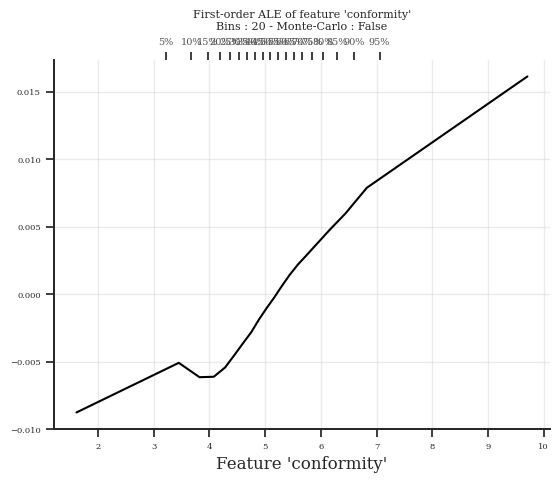

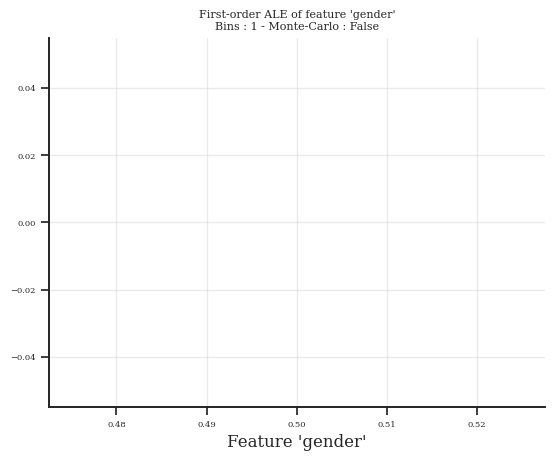

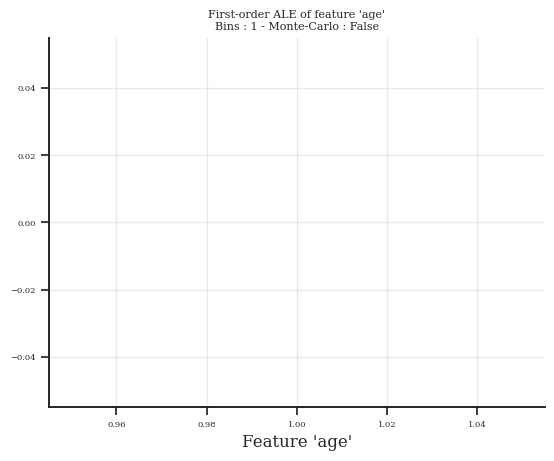

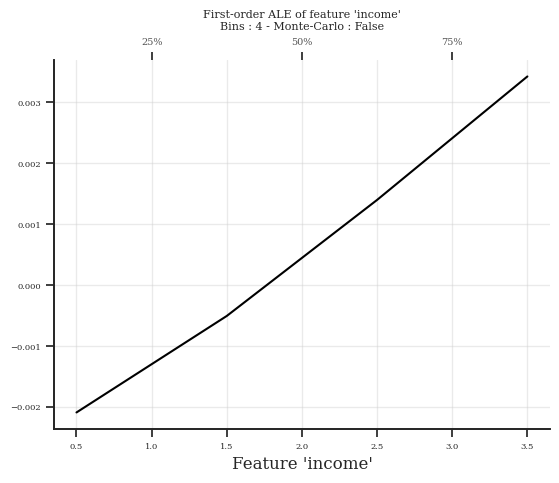

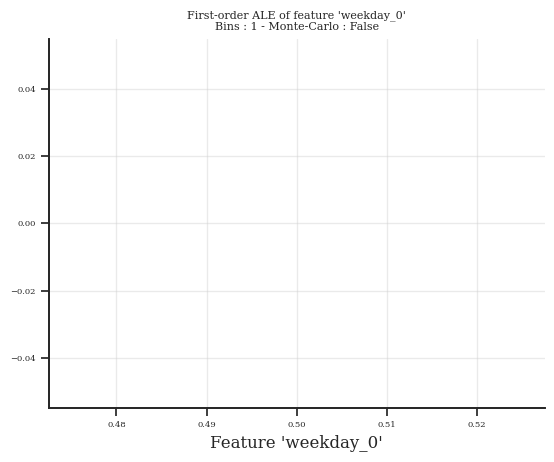

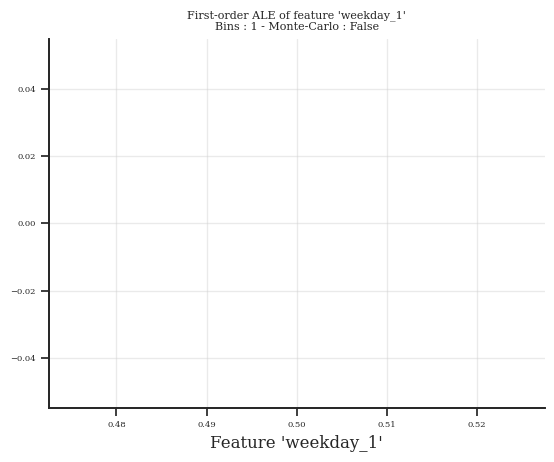

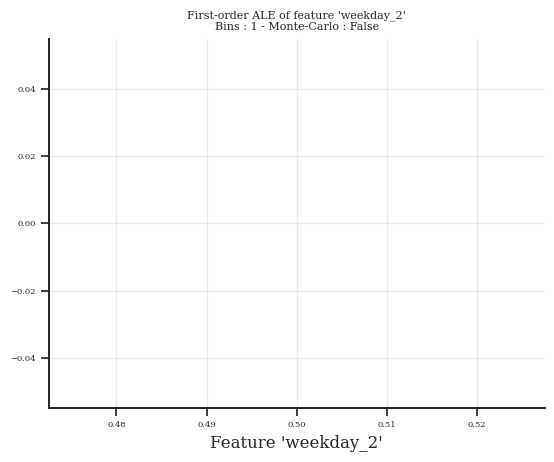

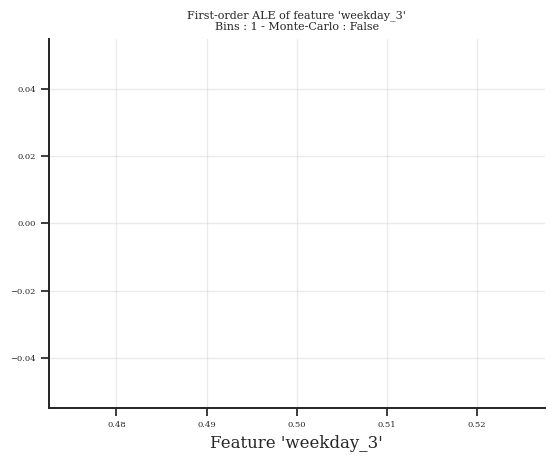

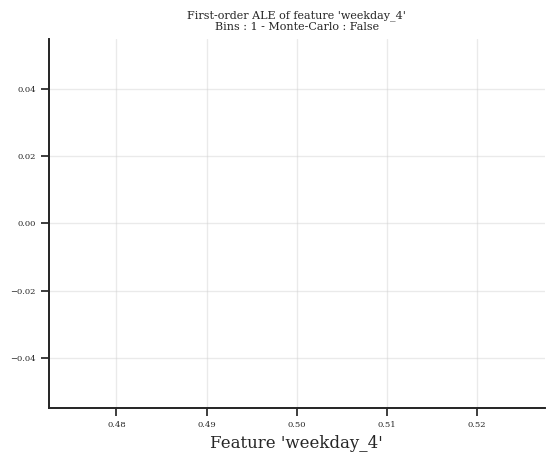

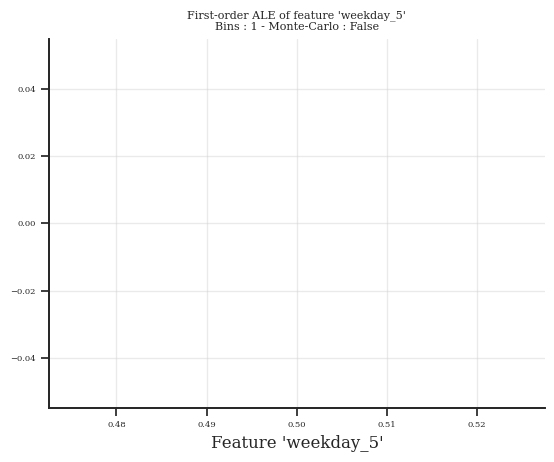

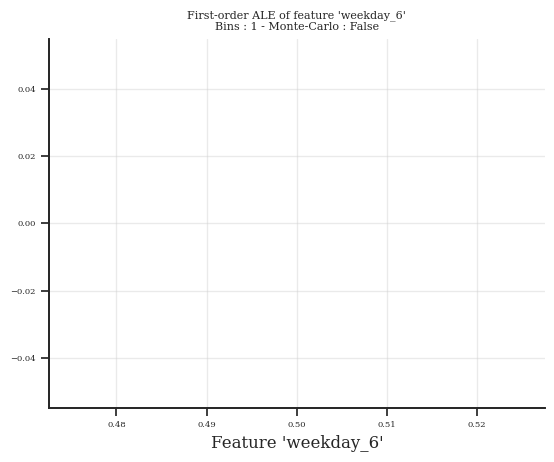

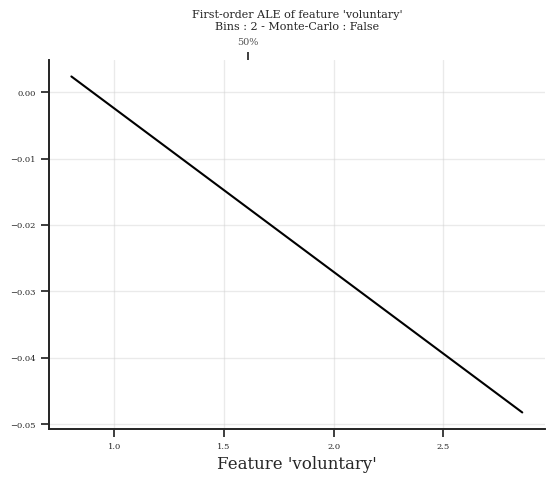

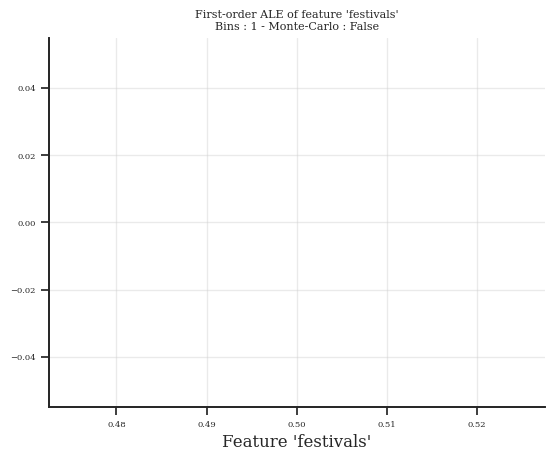

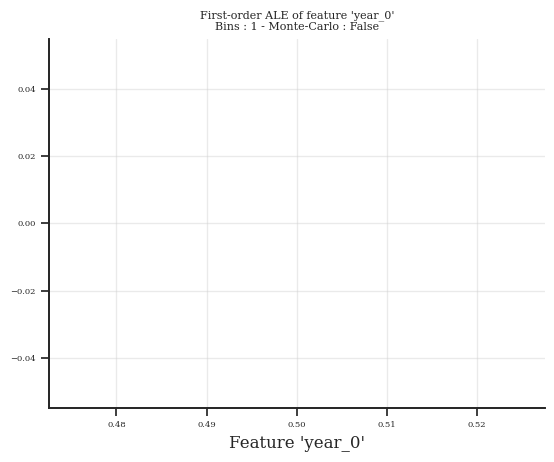

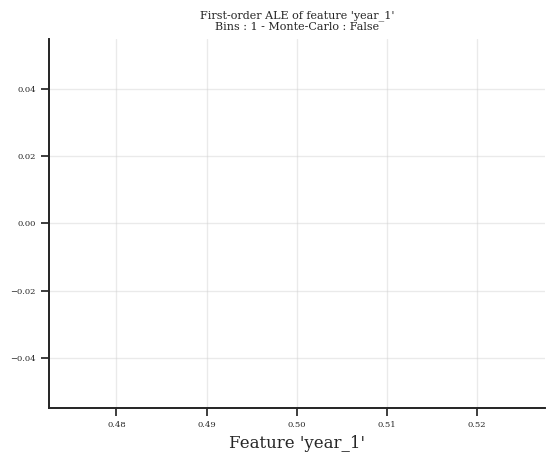

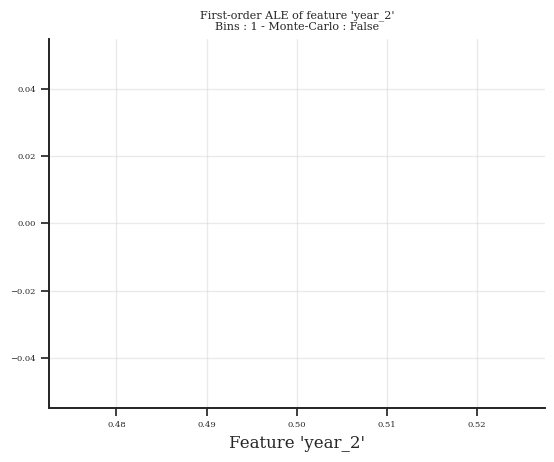

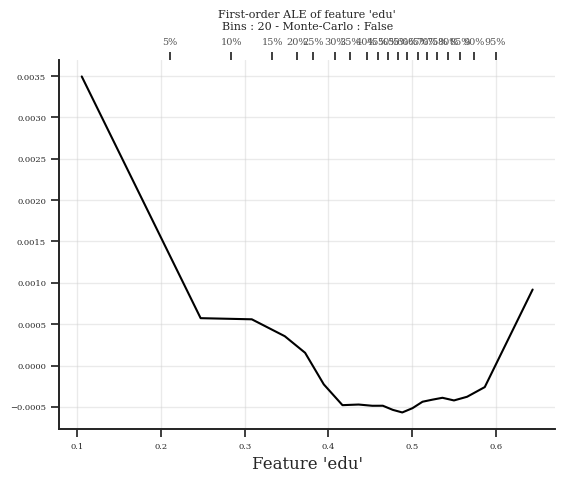

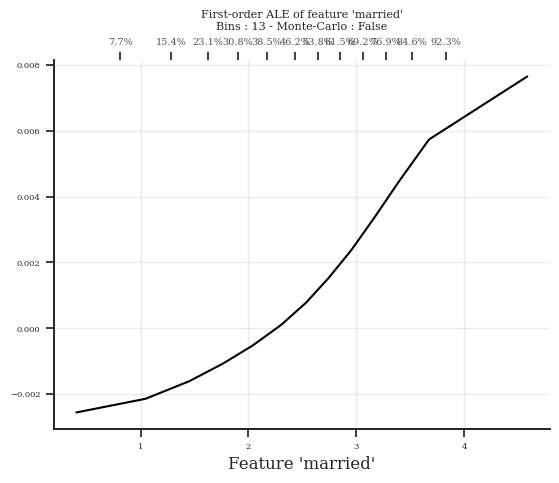

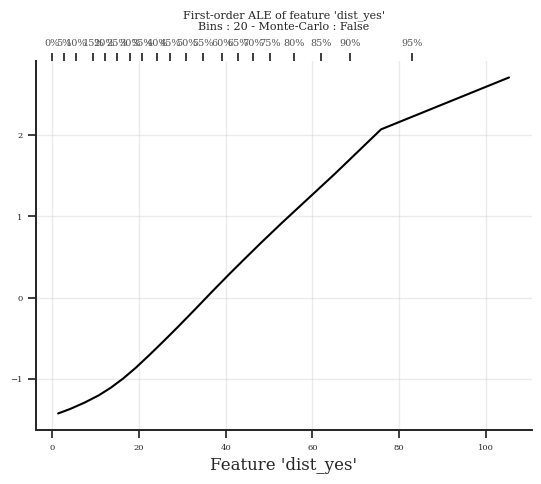

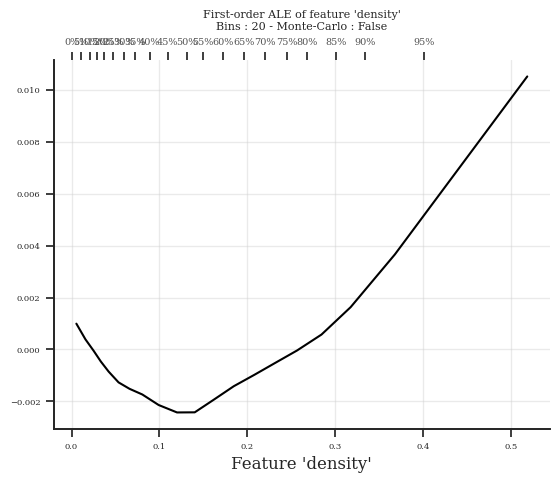

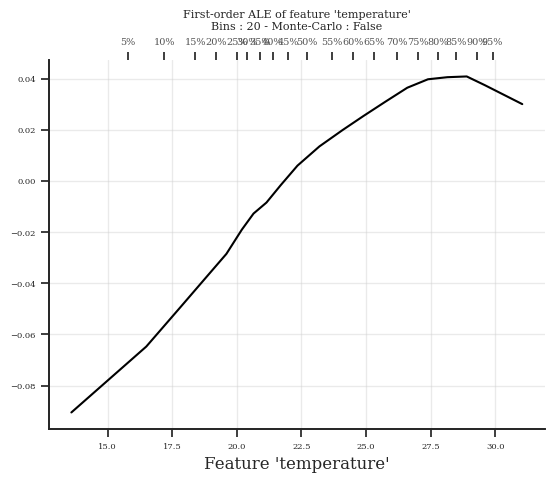

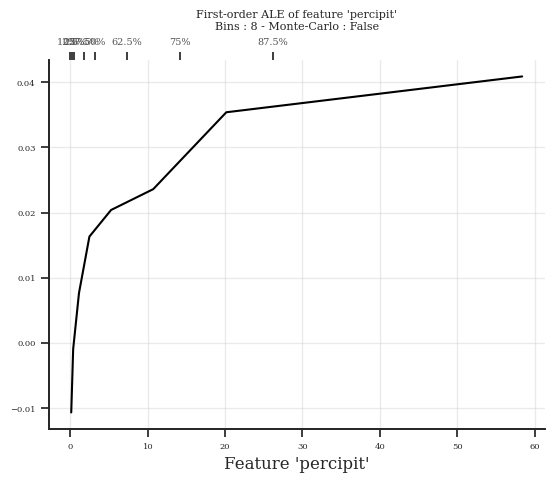

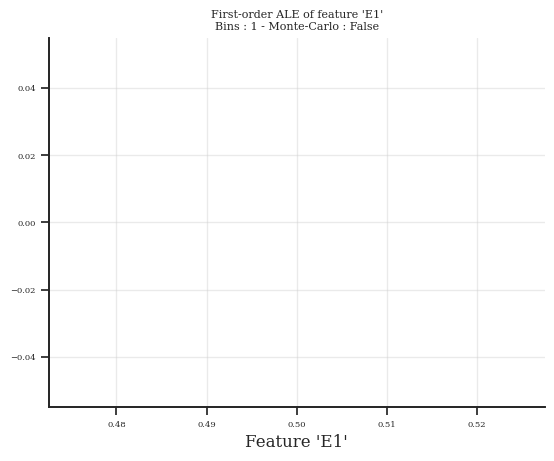

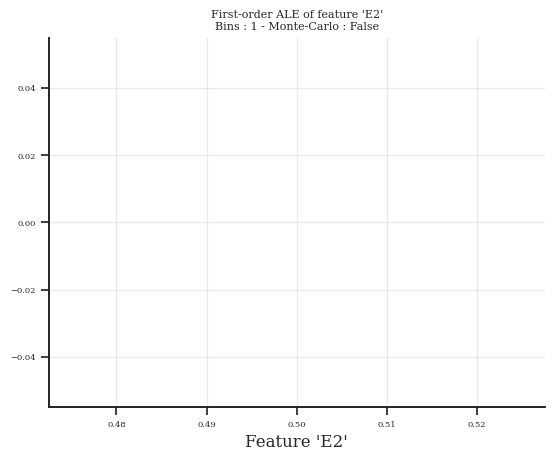

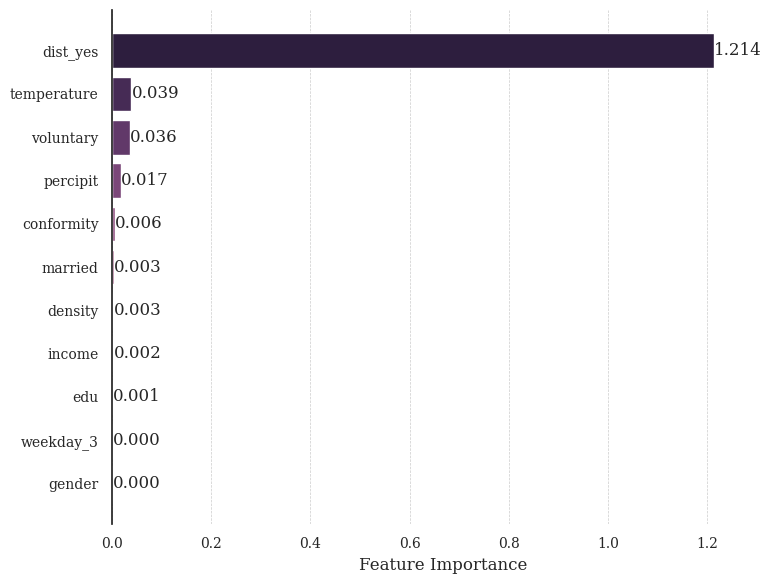

In [11]:
ALE_1ST, ALE_1ST_bin, feature_values = compute_ale_for_features(
        dataset, features, exp_name,
        n_sample=1000, treatment_feature_name="conformity"
    )

ale_ds, X, y = build_ale_xarray_dataset(
    ALE_1ST, ALE_1ST_bin, feature_values, features
)

ale_var_result, global_fig, ax = ale_variance_and_plot(
        X, y, ale_ds,
        model_name='RNN_Model',
        extra_estimators=(RandomForestRegressor(),),
        save_path=False,
        show=False,
        show_topN=[1,11]
    )

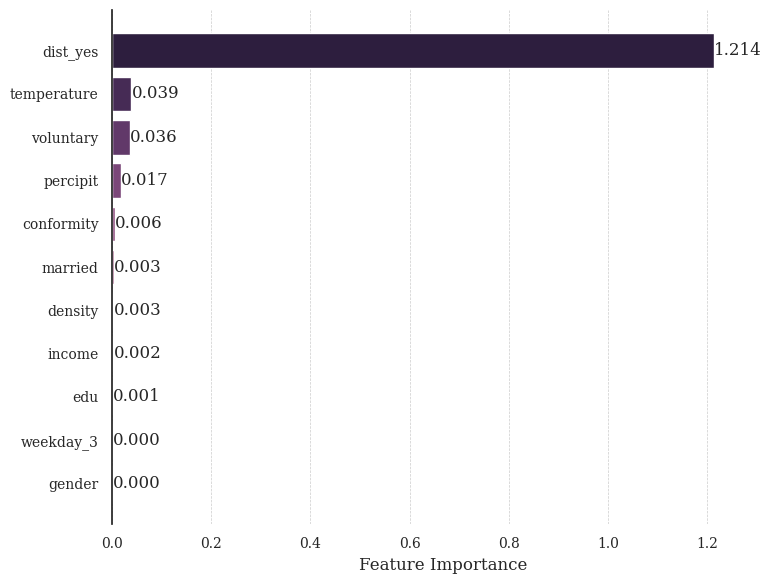

In [12]:
global_fig

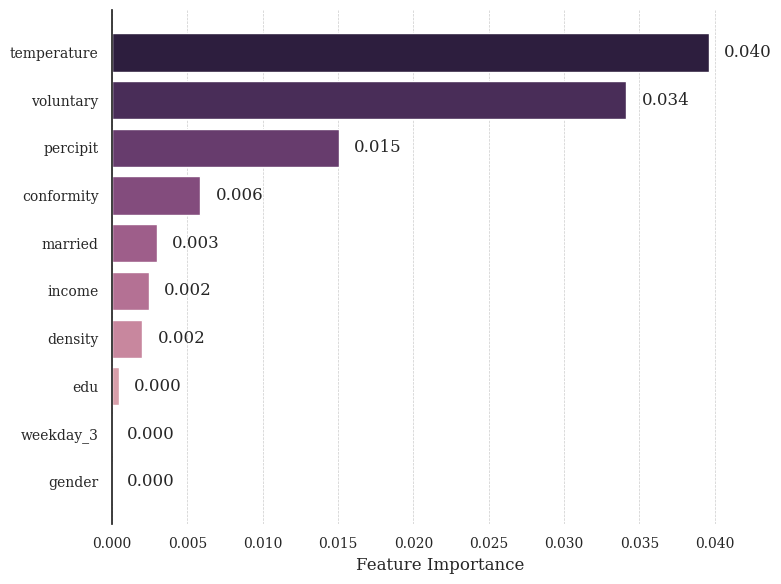

In [34]:
global_fig

### 1.2 分三年各自的特征相对重要性

In [13]:
# 先划分数据集
column_2019 = 12  # index of year 2019 indicator
column_2020 = 13  # index of year 2020 indicator
column_2023 = 14  # index of year 2023 indicator

dataset19 = obtain_dataset(dataset, column_2019)
dataset20 = obtain_dataset(dataset, column_2020)
dataset23 = obtain_dataset(dataset, column_2023)

In [17]:
# 这里要删掉与年份相关的变量以及非疫情年中与疫情相关的变量
features_19 = [f for f in features if f not in ['voluntary', 'year_0', 'year_1', 'year_2', 'E1', 'E2', 'weekday_0', 'weekday_1','weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']]
features_20 = [f for f in features if f not in ['year_0', 'year_1', 'year_2', 'weekday_0', 'weekday_1','weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6']]

Processing 2019 dataset...


2025-10-20 22:46:39.969 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.3495417  3.7819293  4.0531263  4.257332   4.4280367
  4.5767536  4.715622   4.8500094  4.975775   5.100861   5.227017
  5.360263   5.501082   5.656945   5.846439   6.0644546  6.3263564
  6.6476235  7.138324  13.235176 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.09it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


...

INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.57it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.75it/s]
2025-10-20 22:49:50.809 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.   0.3  0.5  1.5  2.5  5.5  8.4 18.  44.2 90.6].


[ 0.15  0.4   1.    2.    4.    6.95 13.2  31.1  67.4 ]


Degrees of freedom <= 0 for slice.


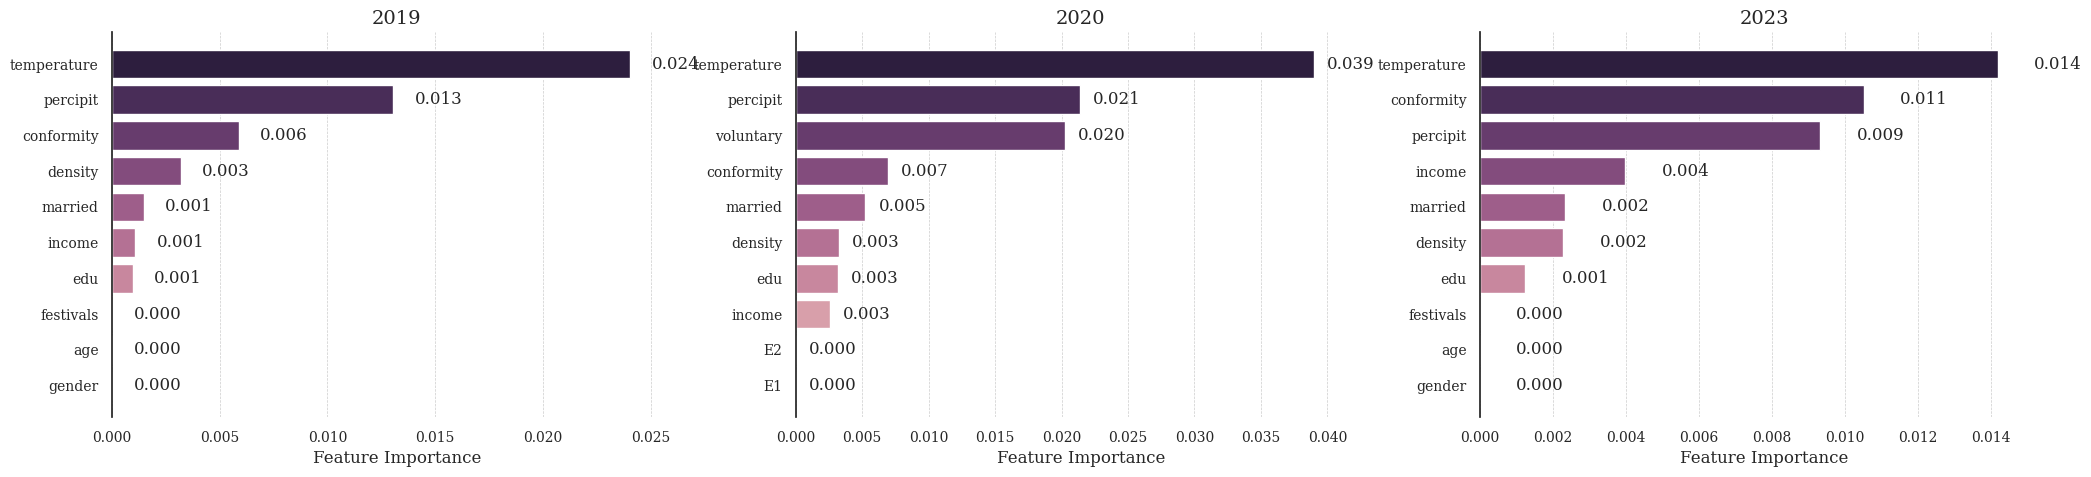

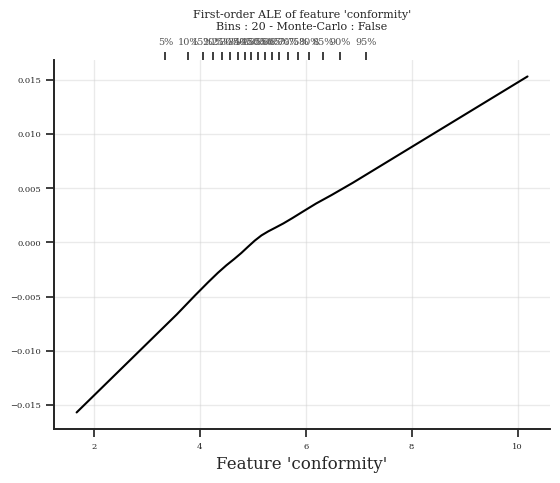

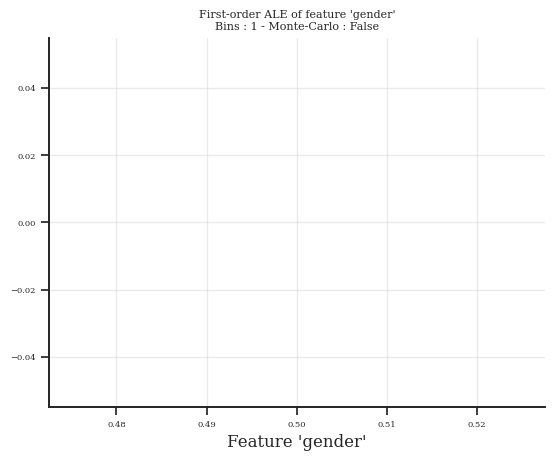

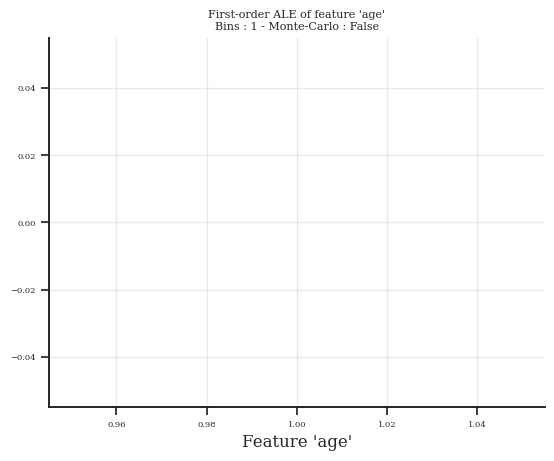

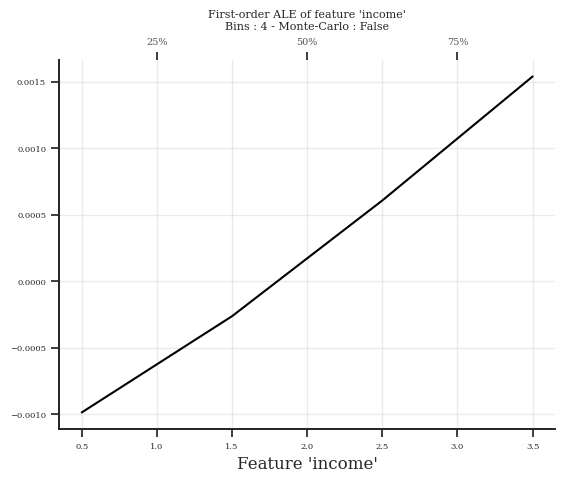

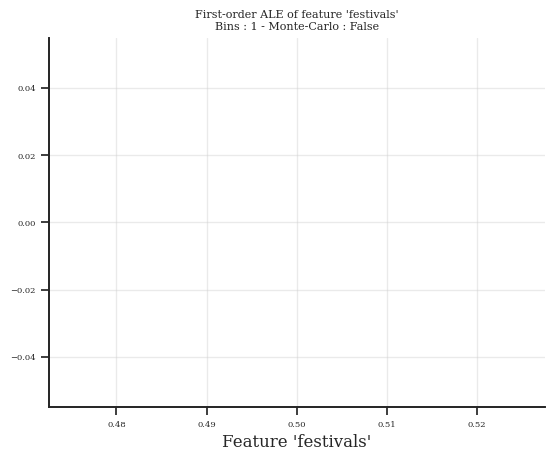

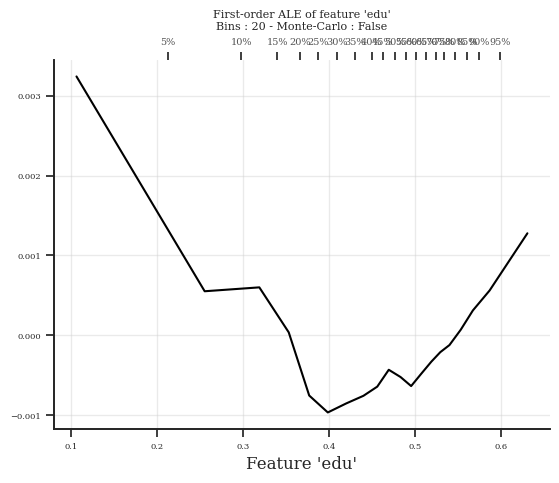

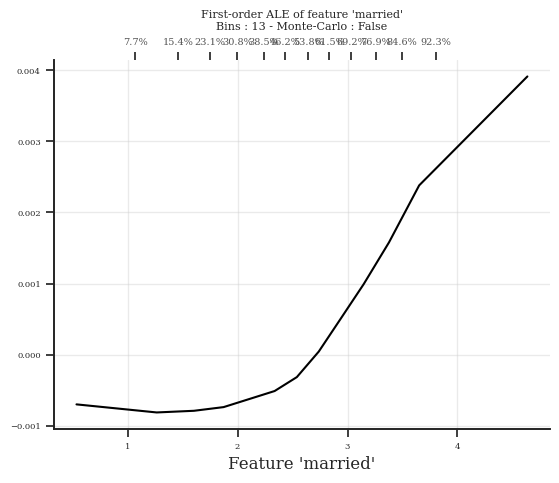

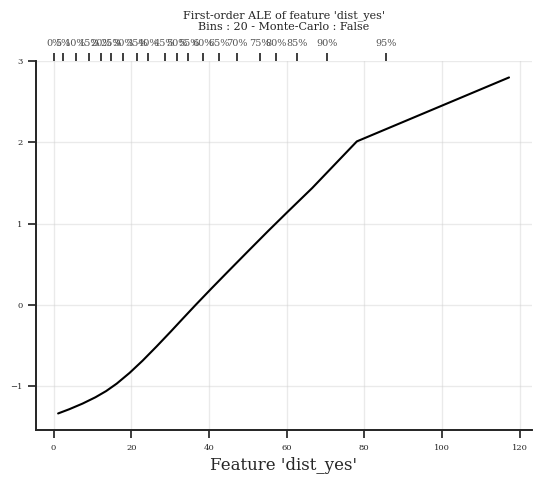

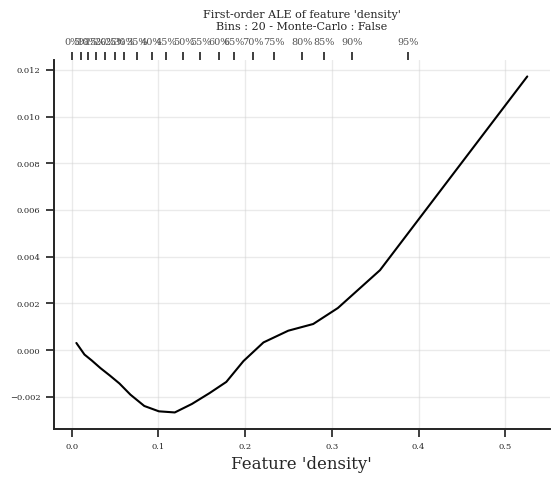

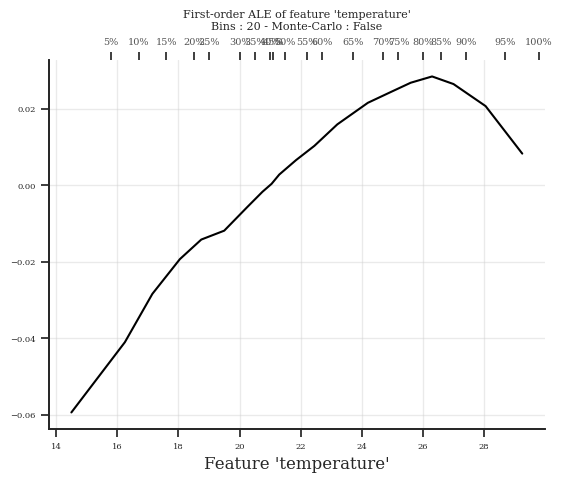

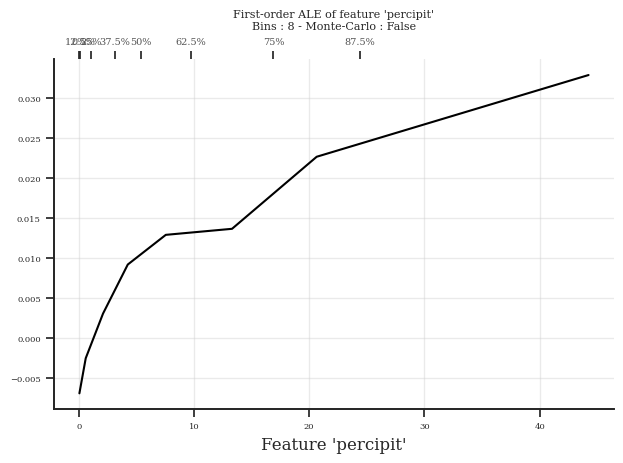

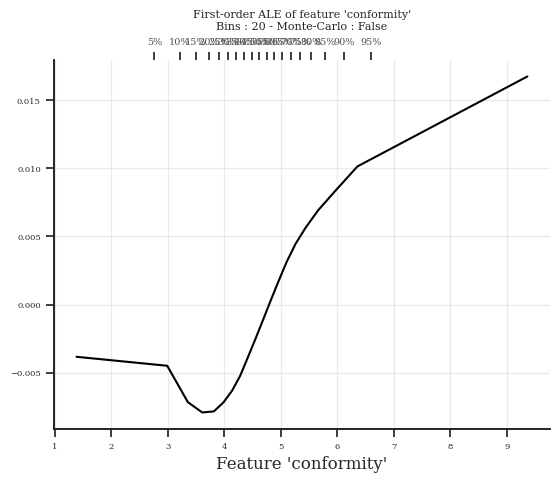

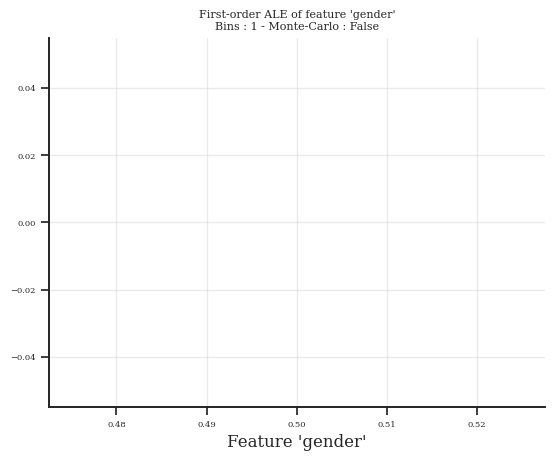

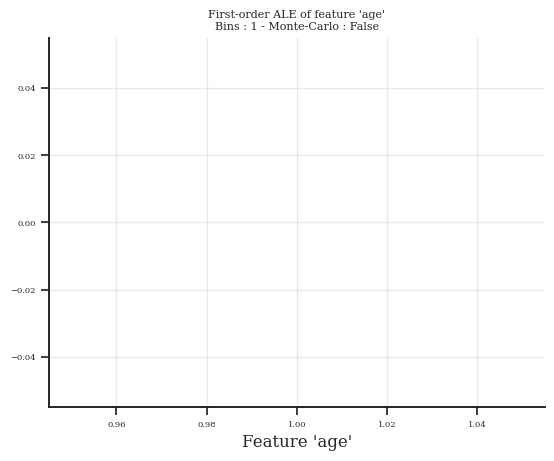

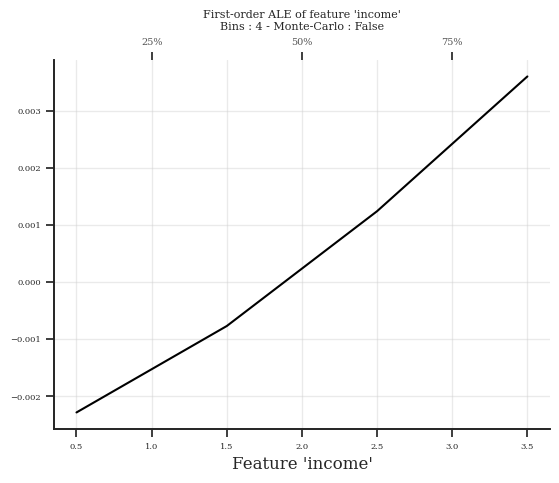

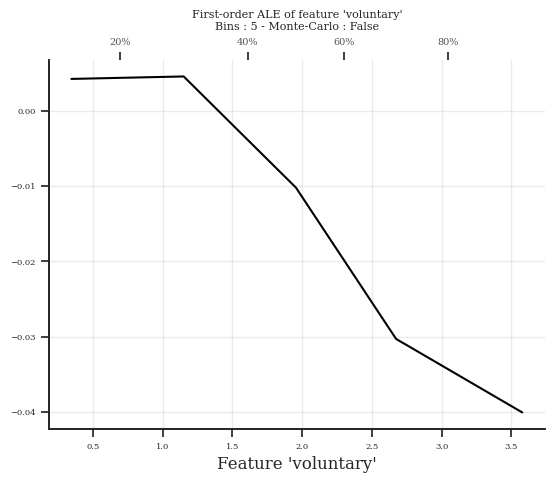

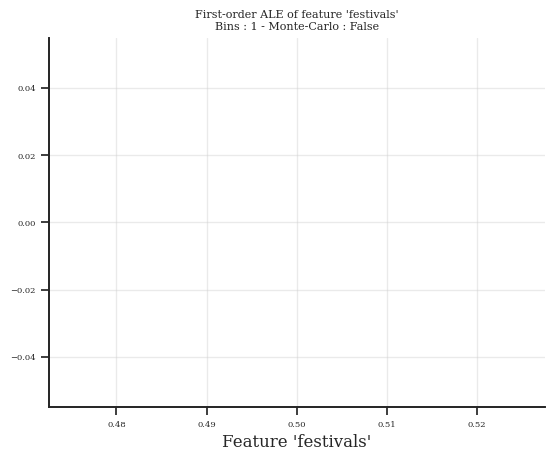

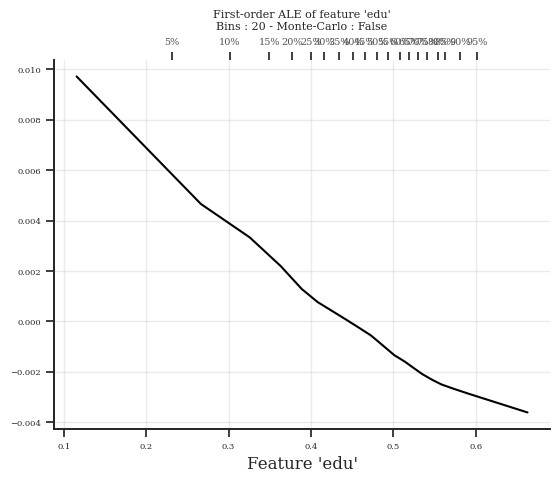

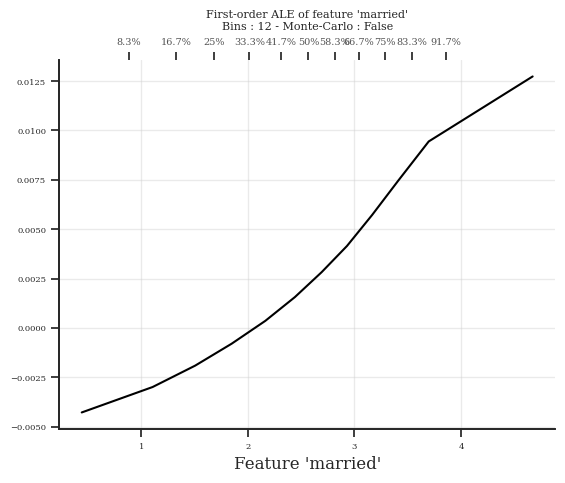

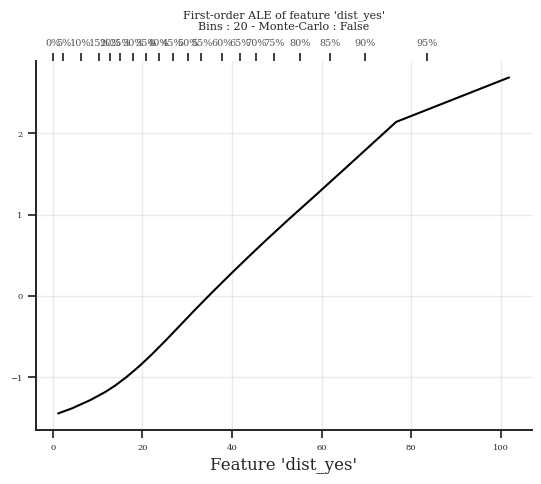

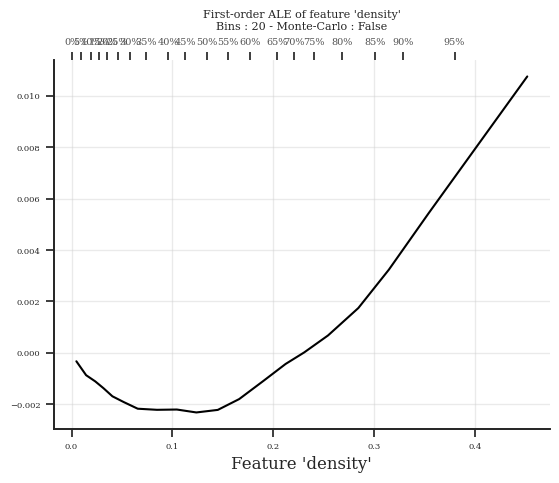

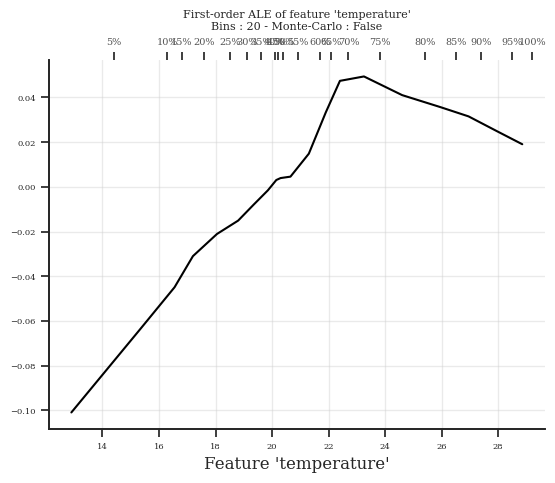

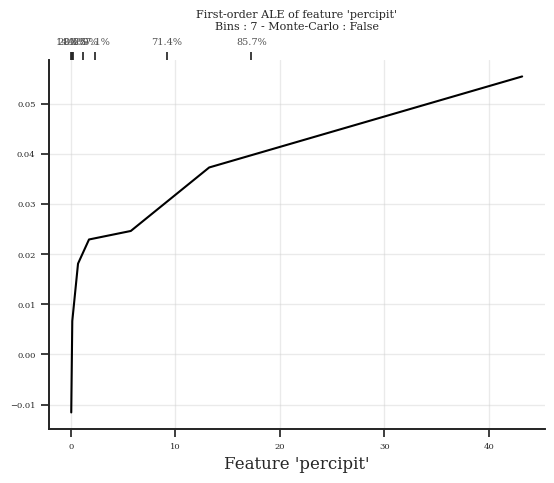

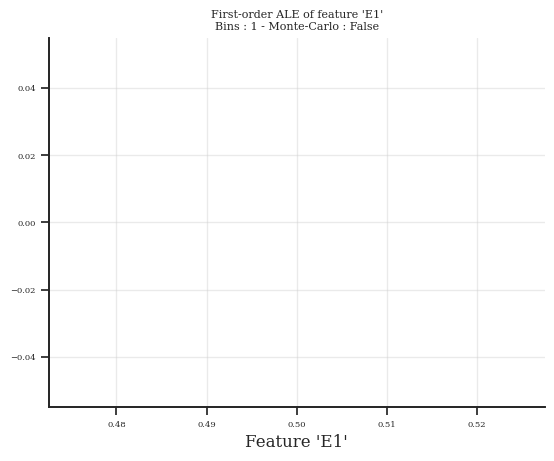

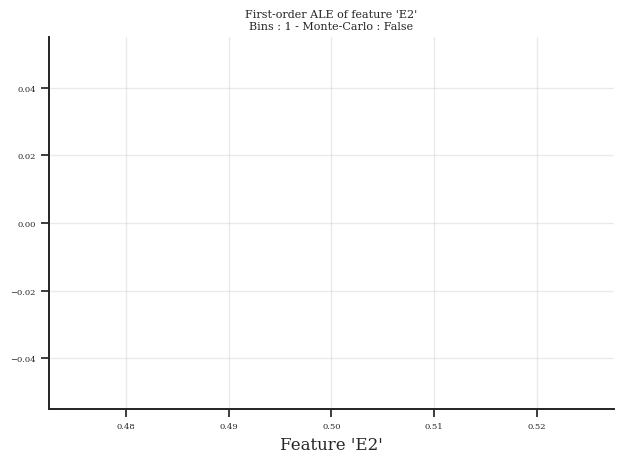

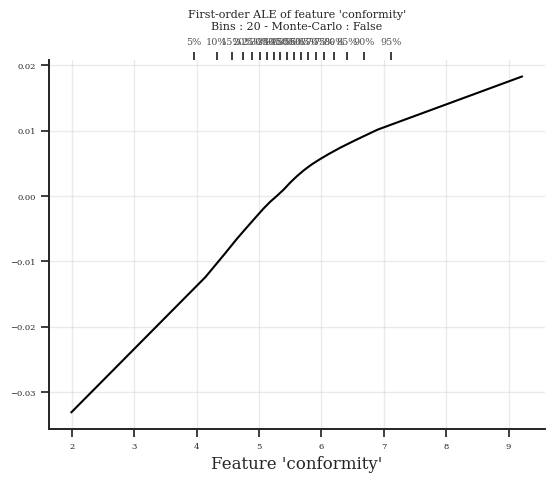

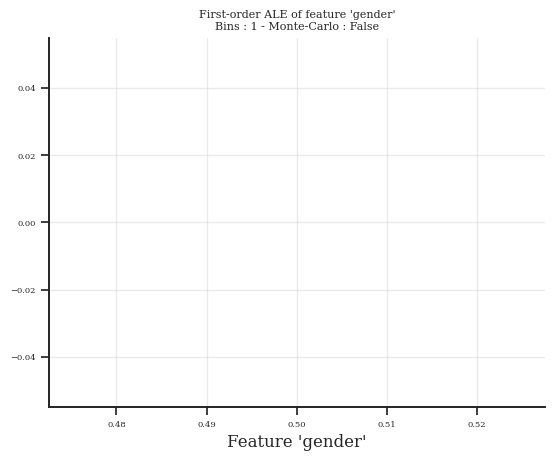

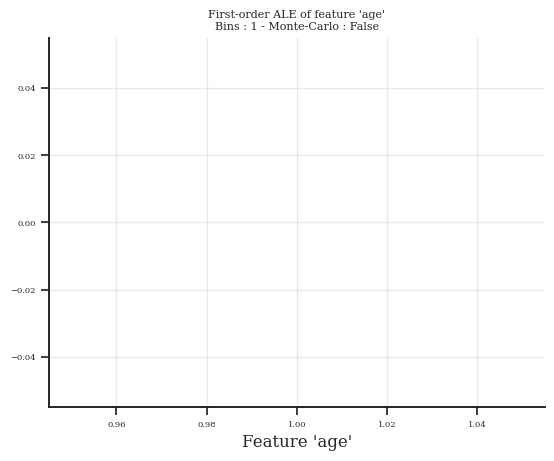

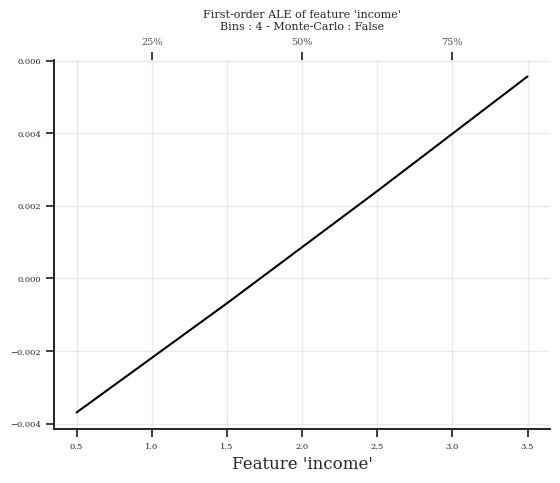

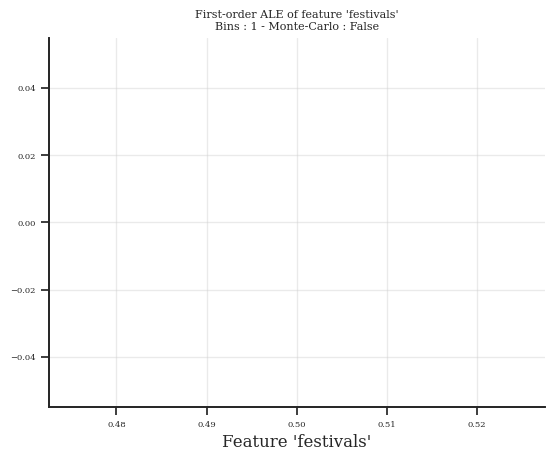

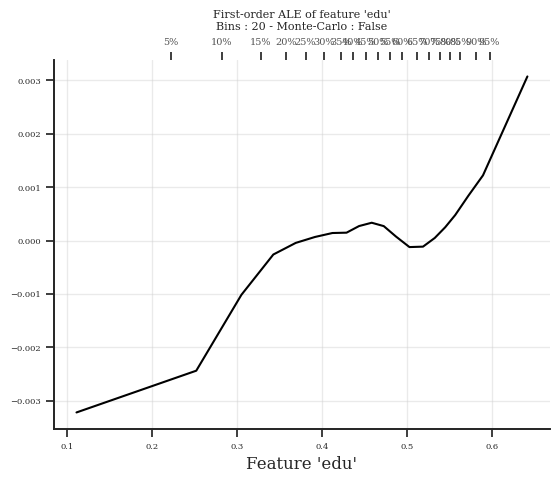

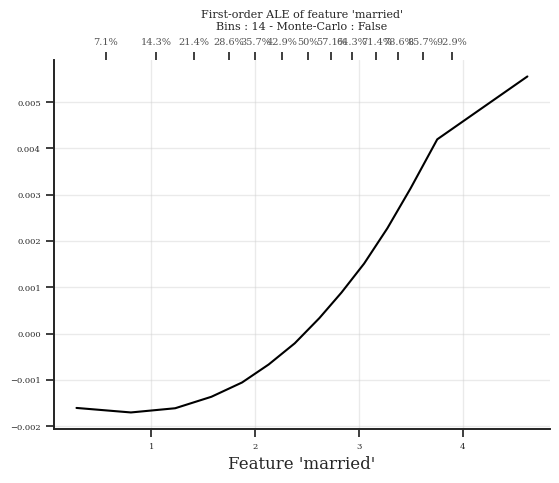

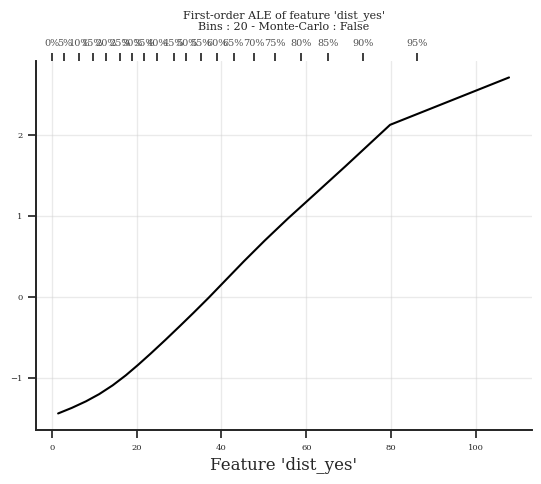

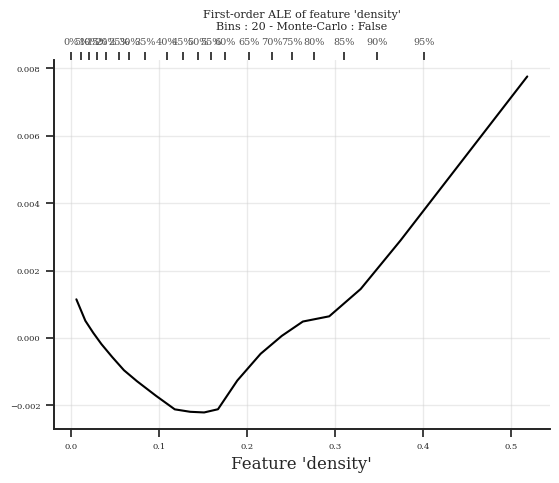

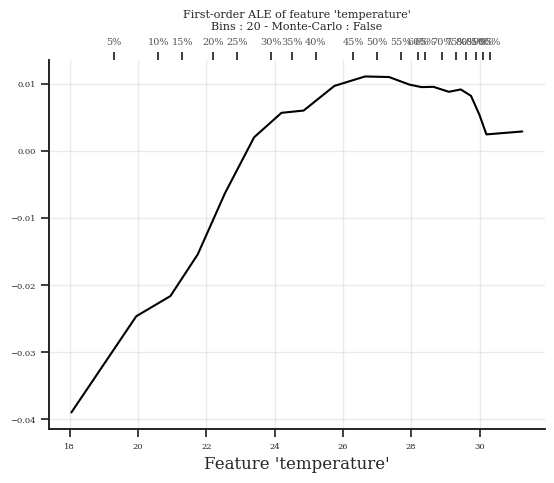

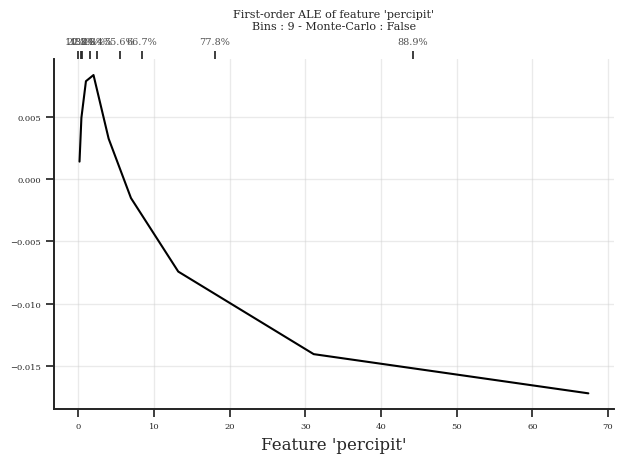

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5))  # 一行三列大图

for i, (dataset, year) in enumerate(zip([dataset19, dataset20, dataset23], ["2019", "2020", "2023"])):
    print(f"Processing {year} dataset...")
    if year != "2020":
        features_this_year = features_19
    else:
        features_this_year = features_20
        # index_to_remove = [-1,-2]
        # dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

    ALE_1ST, ALE_1ST_bin, feature_values = compute_ale_for_features(
        dataset, features_this_year, exp_name,
        n_sample=1000, treatment_feature_name="conformity",
    )

    ale_ds, X, y = build_ale_xarray_dataset(
        ALE_1ST, ALE_1ST_bin, feature_values, features_this_year
    )

    ale_var_result, global_fig, global_ax = ale_variance_and_plot(
        X, y, ale_ds,
        model_name='RNN_Model',
        extra_estimators=(RandomForestRegressor(),),
        save_path=False,
        show=False,
        ax=axes[i],
        show_topN = [1,11],
        figsize=(7,6)
    )

    axes[i].set_title(year, fontsize=14)

# plt.tight_layout()
# plt.show()

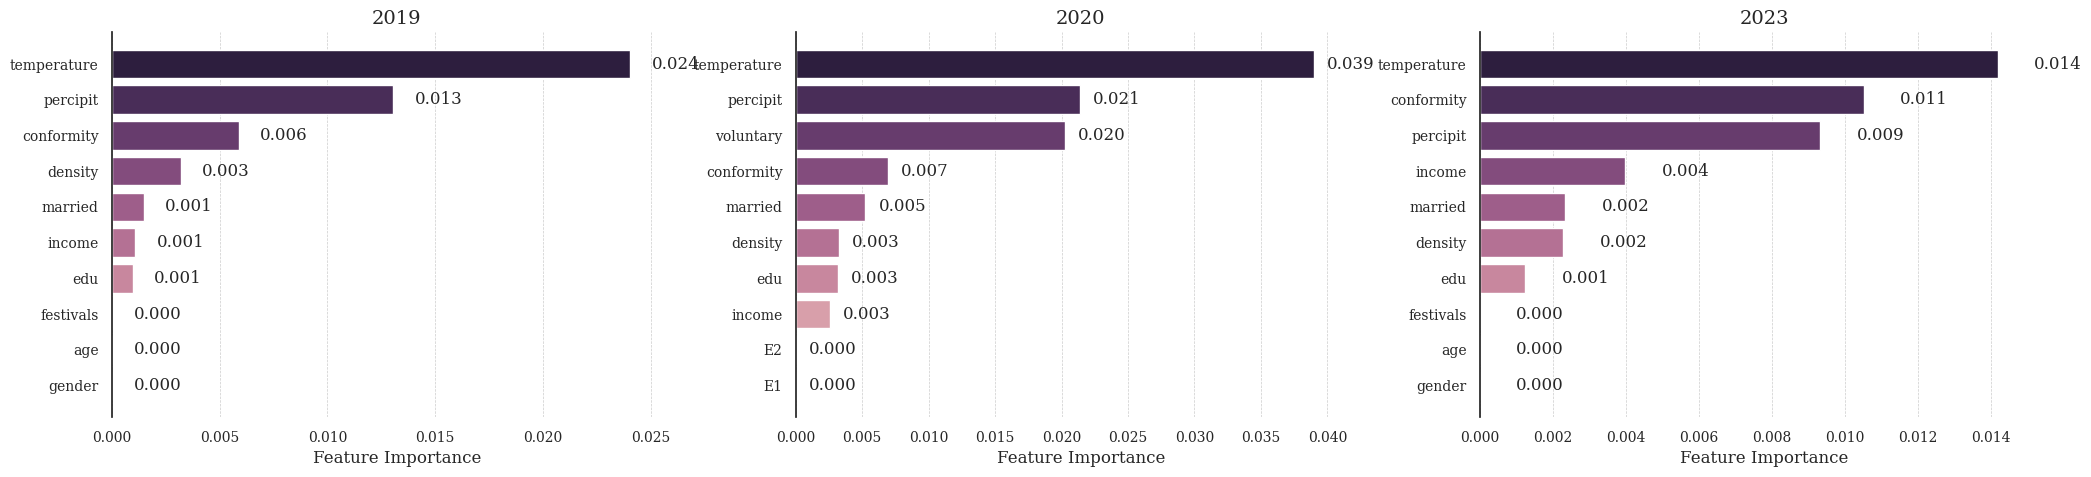

In [19]:
fig

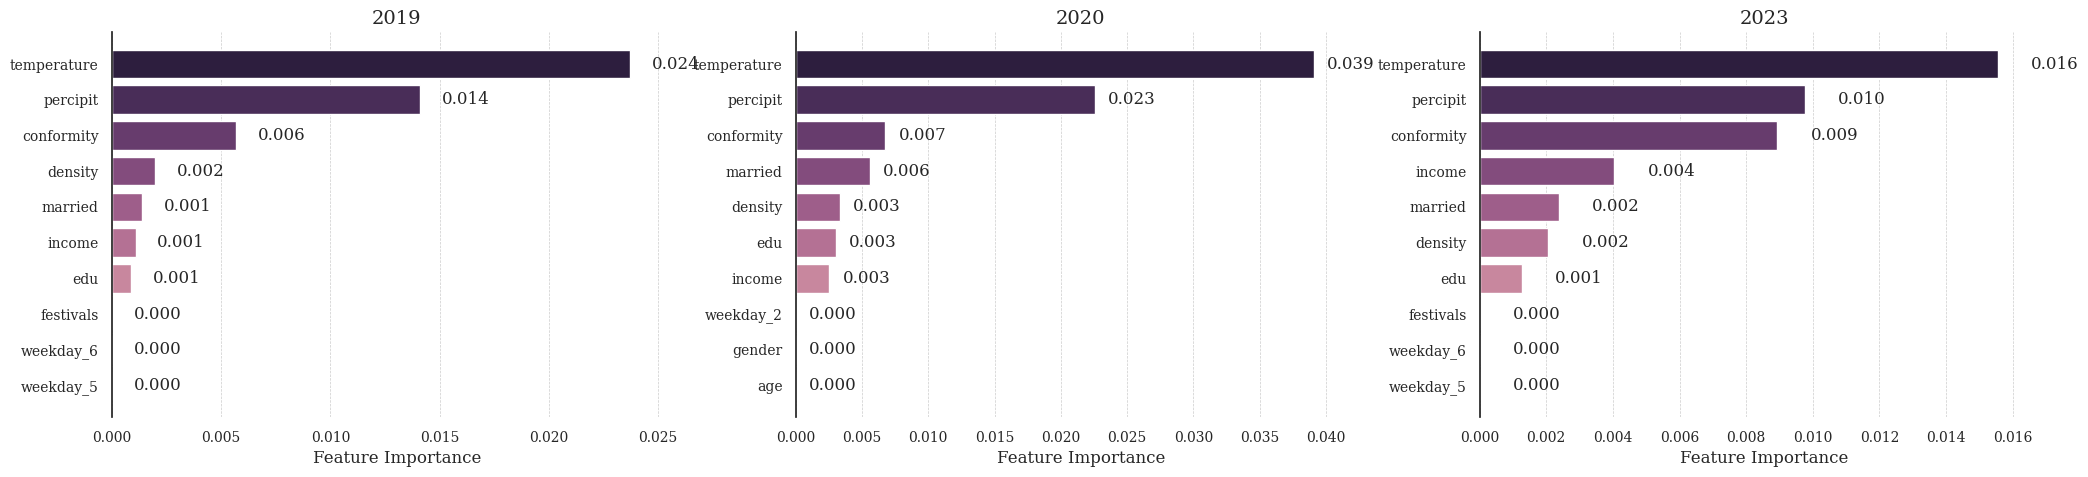

In [40]:
fig

## 2. ALE Curve (Fig2.b)

### 2.1 总体ale曲线

data load as step 1

In [4]:
dataset = load_data("../data/sample_3w2_add.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(96000, 161, 23)
float32
outcomes
(96000, 161, 1)
float32
sequence_length
(96000,)
int64
treatments
(96000, 161, 1)
float32


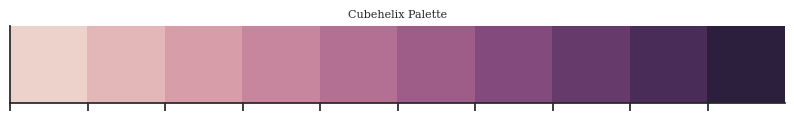

In [5]:
# 模型编号
exp_name = "base_model_optimal_v2"

# 生成 cubehelix 调色盘
cubehelix_palette = sns.cubehelix_palette(n_colors=10)
# 显示调色盘中的所有颜色
sns.palplot(cubehelix_palette)
plt.title('Cubehelix Palette')
plt.show()

the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
2025-12-26 07:04:56.020 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.1831903  3.6524384  3.9542928  4.1952214  4.3805103
  4.5426006  4.6855626  4.8203454  4.9516726  5.080186   5.211275
  5.3412437  5.475827   5.6205416  5.786409   5.9730496  6.211814
  6.523221   7.001087  13.050827 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-12-26 07:04:57.389312: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 13.52it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.64it/s]
2025-12-26 07:05:00.229 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.1831903  3.6524384  3.9542928  4.1952214  4.3805103
  4.5426006  4.6855626  4.8203454  4.9516726  5.080186   5.211275
  5.3412437  5.475827   5.6205416  5.786409   5.9730496  6.211814
  6.523221   7.001087  13.050827 ].


[ 1.5915952  3.4178143  3.8033657  4.074757   4.2878656  4.4615555
  4.6140814  4.752954   4.886009   5.015929   5.1457305  5.2762594
  5.4085355  5.5481844  5.703475   5.8797293  6.092432   6.3675175
  6.762154  10.025957 ]


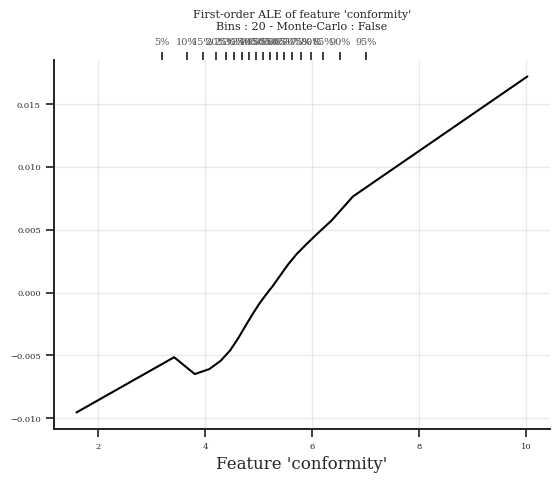

In [6]:
# 计算全局ale，转化成xarray的格式
# 似乎没有固定quantiles，需要再调整一下
bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)
ALE_1ST = {
   'RNN_Model': [],
   }
# n_bootstrap = 30
n_bootstrap = 1

for _ in range(n_bootstrap):
    sub_dataset = dataset_sampling(dataset, 1000)
    ale_fig, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_'+str(exp_name), b_use_predicted_confounders=False, features = ['conformity'], default_quantiles=quantiles)
    ALE_1ST['RNN_Model'].append(ale_1st)
    # window_ale_fig, ale, _ = compute_ale(sub_dataset, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['week', 'conformity'], default_quantiles=quantiles)
    # ale_1st = np.sum(ale, axis=0)
    # ALE_1ST['RNN_Model'].append(ale_1st)

for key in ALE_1ST.keys():
    ALE_1ST[key] = np.array(ALE_1ST[key])
ale_dataset = create_ale_dataset(ALE_1ST, quantiles, dataset['treatments'], ['RNN_Model'], 'conformity')

In [10]:
#save
# ale_dataset.to_netcdf(path='figures/figure_data/fig_1b.nc')

#save bootstrap=1
# ale_dataset.to_netcdf(path='figures/figure_data/fig_1b_noCI.nc')

#read
ale_dataset = xr.open_dataset('./figures/figure_data/fig_2b.nc')

In [48]:
ale_dataset

<xarray.Dataset>
Dimensions:                     (n_bootstrap: 1, n_bins__conformity: 20,
                                 n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model__ale  (n_bootstrap, n_bins__conformity) float64 -0....
    conformity__bin_values      (n_bins__conformity) float32 1.61 ... 10.38
    conformity                  (n_X) float32 4.845 4.79 4.408 ... 5.465 4.62
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model']
    method:            ale
    dimension:         1D
    features used:     ['conformity']

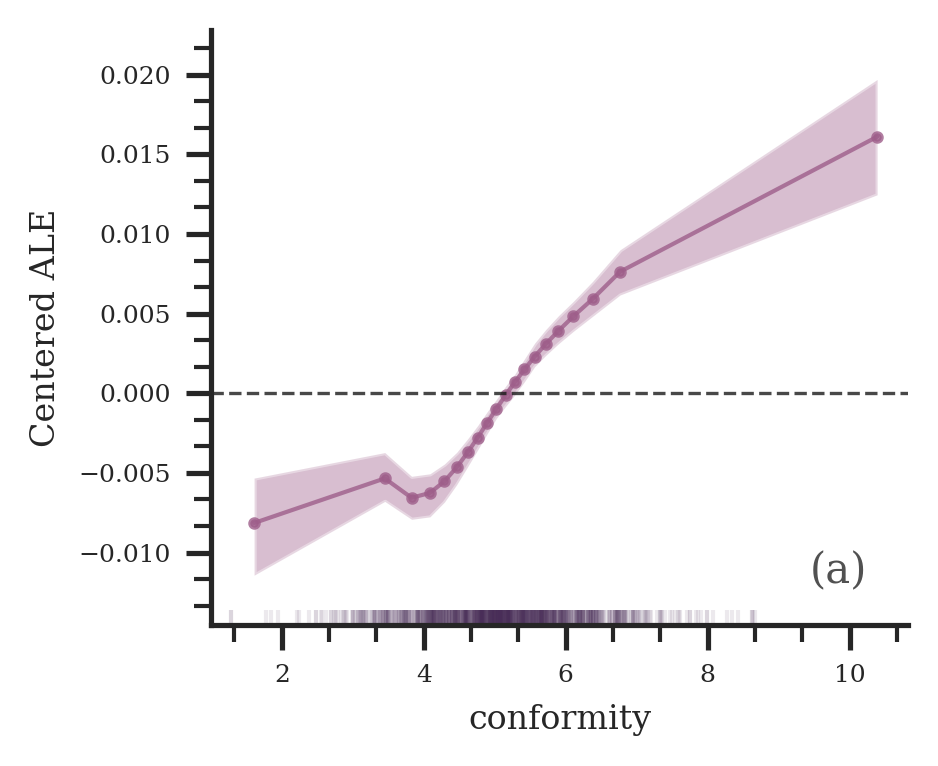

In [7]:
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

#修改可视化效果
#fig, ax = plt.subplots(dpi=300)
fig, ax = explainer.plot_ale(
                                   ale = ale_dataset,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':2,'linewidth':1, 'line_colors': [cubehelix_palette[5]]},
                                   add_hist = False,
                                  )

# ax.set_xscale('log')
ax.set_ylabel('Centered ALE', fontsize = 8)
# ax.set_xlim(right = 1000)
ax.set_xlim(left=1)

# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])

data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

# plt.savefig('./figures/fig_1b_SCI_ale_1st_log_log.png',  dpi=300)

plt.show()

In [7]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset['conformity'] = (('n_X'), conformity_original)

ale_dataset

<xarray.Dataset>
Dimensions:                     (n_bootstrap: 1, n_bins__conformity: 20,
                                 n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model__ale  (n_bootstrap, n_bins__conformity) float64 -0....
    conformity__bin_values      (n_bins__conformity) float32 4.005 ... 3.236e+04
    conformity                  (n_X) float32 126.1 119.3 81.13 ... 235.4 100.5
Attributes:
    estimator_output:  raw
    estimators used:   ['RNN_Model']
    method:            ale
    dimension:         1D
    features used:     ['conformity']

In [8]:
# 将ALE值转换为倍数
ale_values = ale_dataset['conformity__RNN_Model__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

倍数y轴

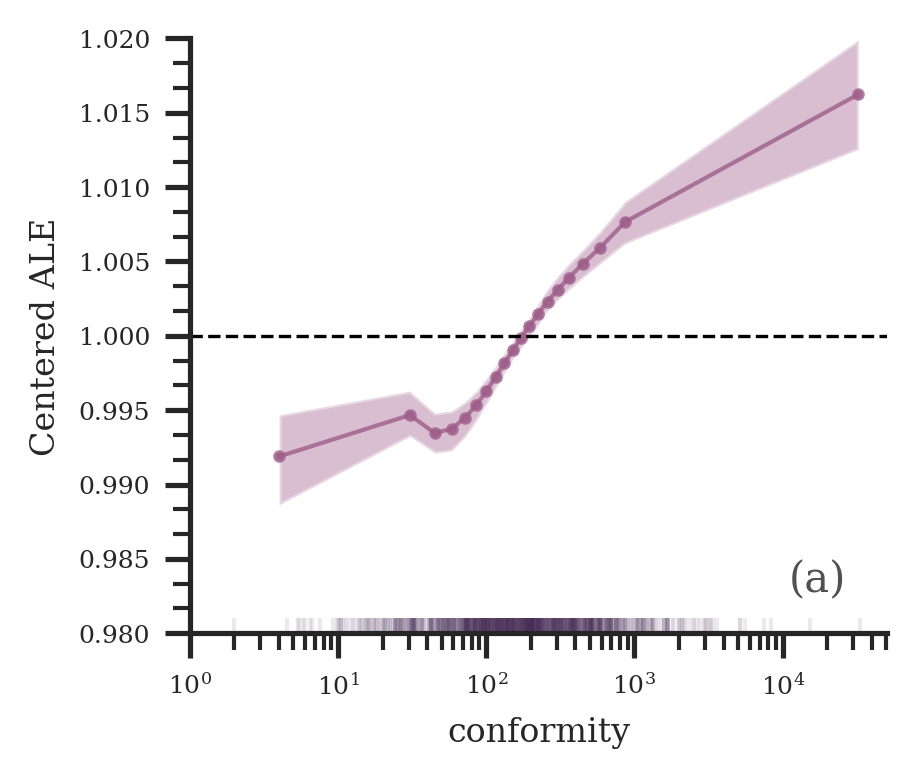

In [10]:
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

#修改可视化效果
#fig, ax = plt.subplots(dpi=300)
fig, ax = explainer.plot_ale(
                                   ale = ale_dataset,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':2,'linewidth':1, 'line_colors': [cubehelix_palette[5]]},
                                   add_hist = False,
                                  )
ax.axhline(y=1, color='black', ls='--', lw=0.8)

ax.set_xscale('log')
ax.set_ylabel('Centered ALE', fontsize = 8)
# ax.set_xlim(right = 1000)
ax.set_xlim(left=1)
ax.set_ylim(bottom = 0.98, top = 1.02)


# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])

data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

# plt.savefig('./figures/fig_1b_SCI_ale_1st_SCI_log.png',  dpi=300)

plt.show()

倍数y轴 + 整数x轴 + cut 95%

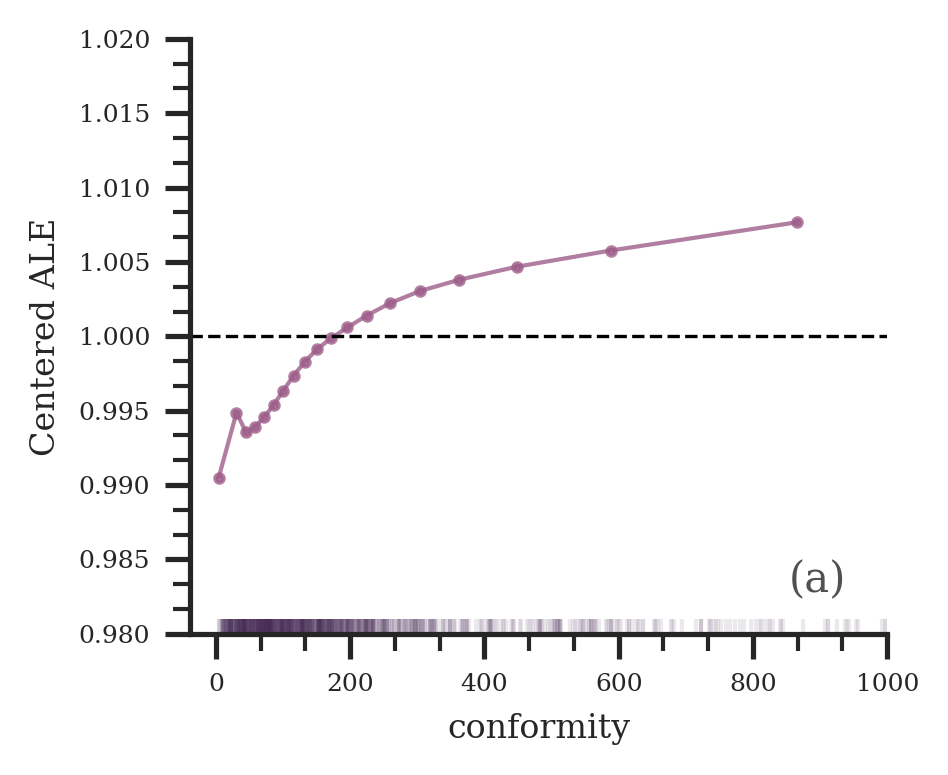

In [9]:
bins_to_keep = ale_dataset['n_bins__conformity'] != ale_dataset['n_bins__conformity'].loc[-1]
ale_dataset_select = ale_dataset.sel(n_bins__conformity=bins_to_keep)

estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

#修改可视化效果
#fig, ax = plt.subplots(dpi=300)
fig, ax = explainer.plot_ale(
                                   ale = ale_dataset_select,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':2,'linewidth':1, 'line_colors': [cubehelix_palette[5]]},
                                   add_hist = False,
                                  )
ax.axhline(y=1, color='black', ls='--', lw=0.8)

# ax.set_xscale('log')
ax.set_ylabel('Centered ALE', fontsize = 8)
ax.set_xlim(right = 1000)
# ax.set_xlim(left=1)
ax.set_ylim(bottom = 0.98, top = 1.02)


# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])

data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

plt.savefig('./figures/fig_1b_SCI_ale_1st_raw-1.png',  dpi=300)

plt.show()


### 2.2 三年的曲线画一起

In [9]:
column_2019 = 12  # index of year 2019 indicator
column_2020 = 13  # index of year 2020 indicator
column_2023 = 14  # index of year 2023 indicator

#dataset19 = obtain_dataset(dataset, column_2019)['treatments'][:,:,0]
#dataset20 = obtain_dataset(dataset, column_2020)['treatments'][:,:,0]
#dataset23 = obtain_dataset(dataset, column_2023)['treatments'][:,:,0]

dataset19 = obtain_dataset(dataset, column_2019)
dataset20 = obtain_dataset(dataset, column_2020)
dataset23 = obtain_dataset(dataset, column_2023)

the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
2025-09-28 18:01:24.391 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.354312   3.8050478  4.074179   4.2774587  4.4436812
  4.59276    4.7233944  4.8513536  4.9738426  5.096646   5.219431
  5.352123   5.4967713  5.6421633  5.821136   6.0194025  6.2626176
  6.573758   7.0379295 13.370989 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-09-28 18:01:25.789386: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 13.02it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.76it/s]
2025-09-28 18:01:28.776 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.354312   3.8050478  4.074179   4.2774587  4.4436812
  4.59276    4.7233944  4.8513536  4.9738426  5.096646   5.219431
  5.352123   5.4967713  5.6421633  5.821136   6.0194025  6.2626176
  6.573758   7.0379295 13.370989 ].


...

results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.76it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.83it/s]
2025-09-28 18:09:39.318 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.3551813  3.956017   4.3141494  4.5364814  4.7033305  4.8468547
  4.9745054  5.0906715  5.2039313  5.3174043  5.4261622  5.5362144
  5.6453557  5.7620425  5.8845983  6.0186453  6.193382   6.4119496
  6.7008424  7.167055  12.669338 ].


[2.155599  4.135083  4.4253154 4.619906  4.7750926 4.91068   5.0325885
 5.1473017 5.260668  5.3717833 5.4811883 5.590785  5.703699  5.8233204
 5.951622  6.1060133 6.3026657 6.556396  6.9339485 9.918197 ]


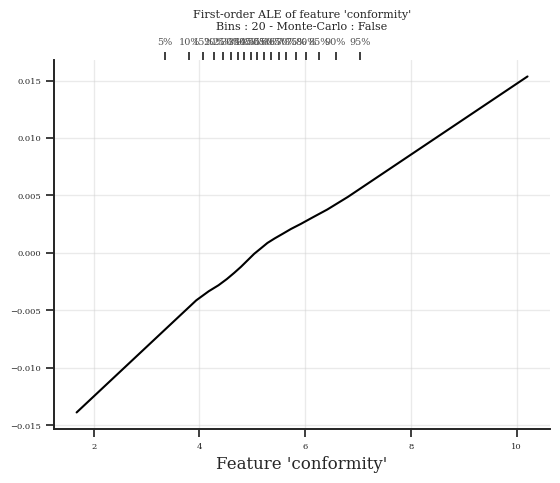

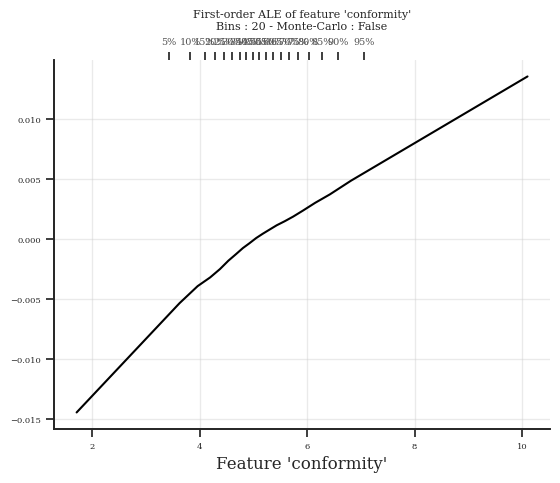

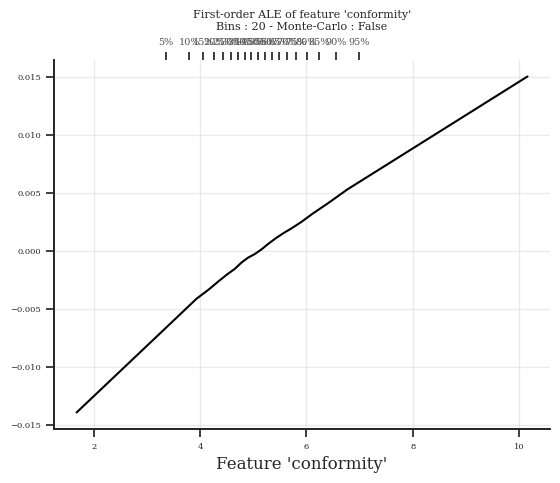

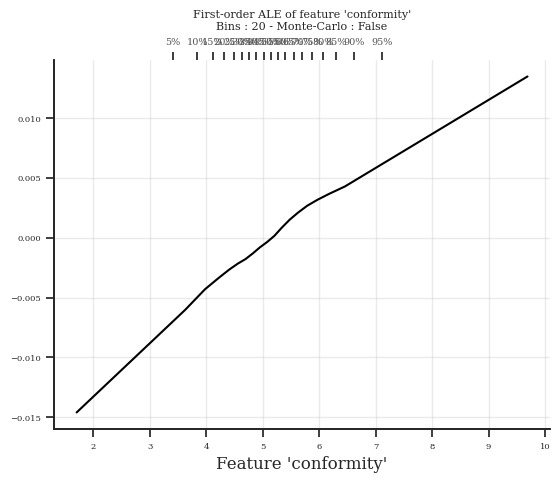

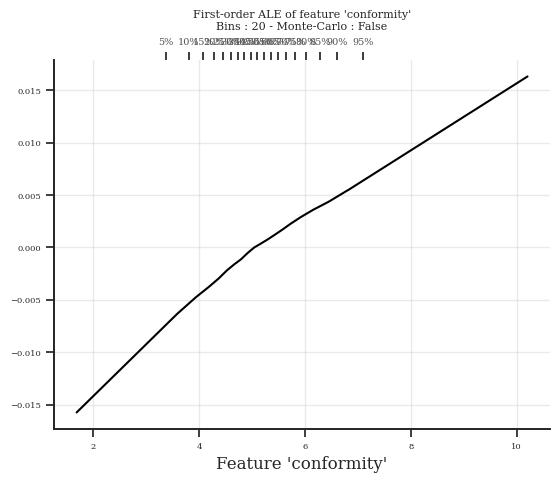

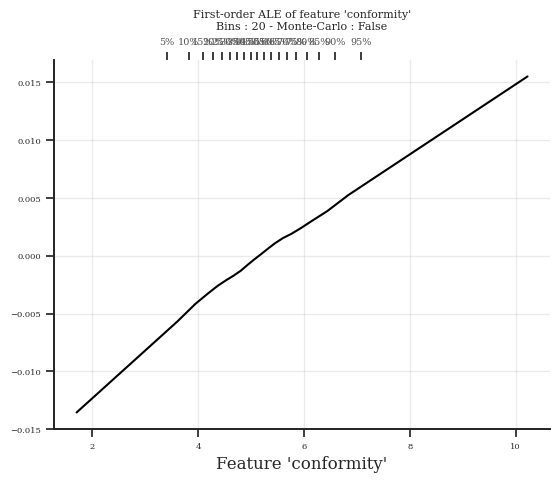

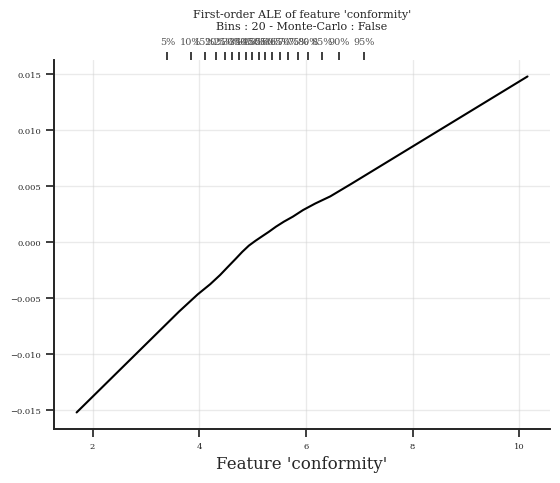

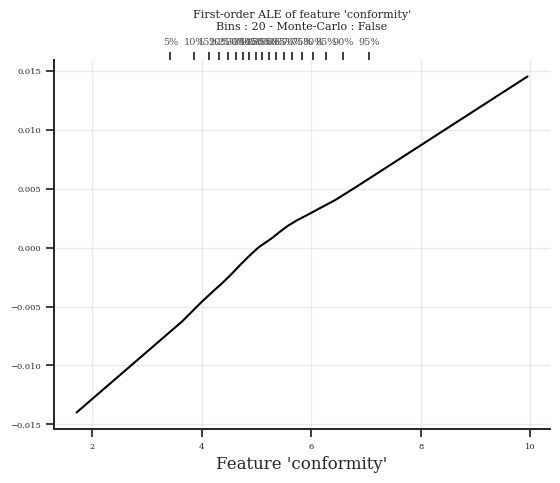

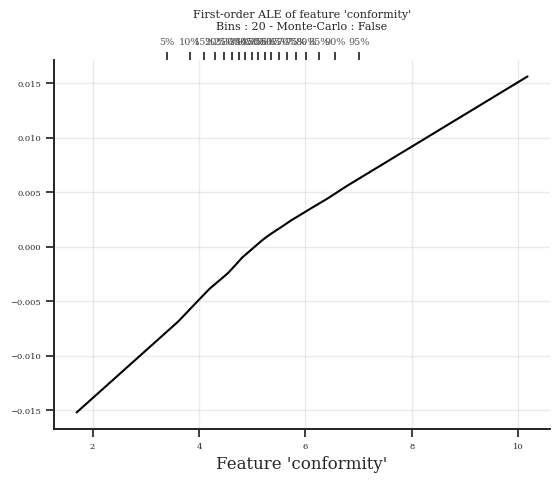

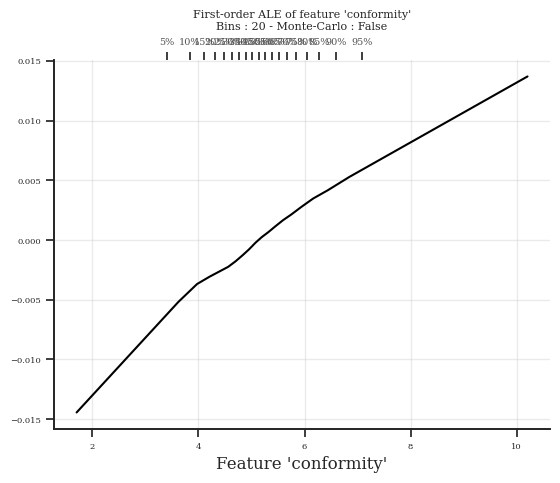

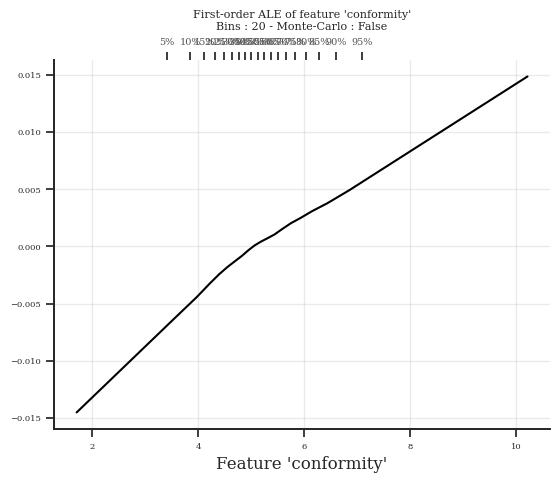

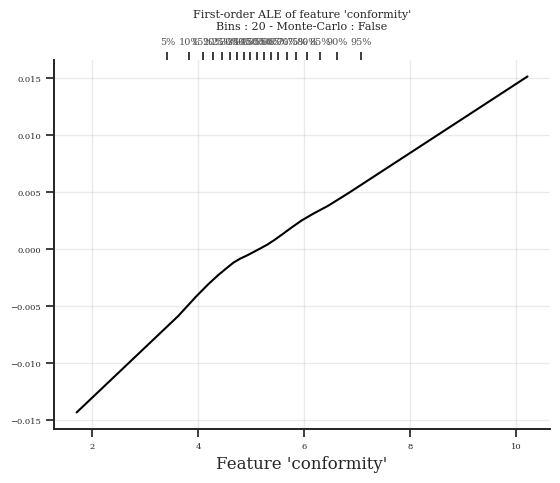

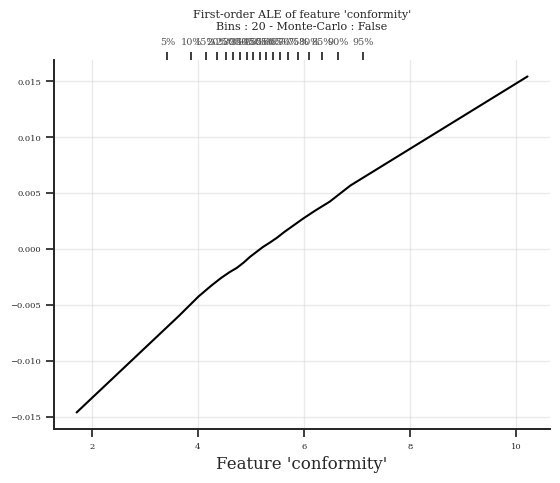

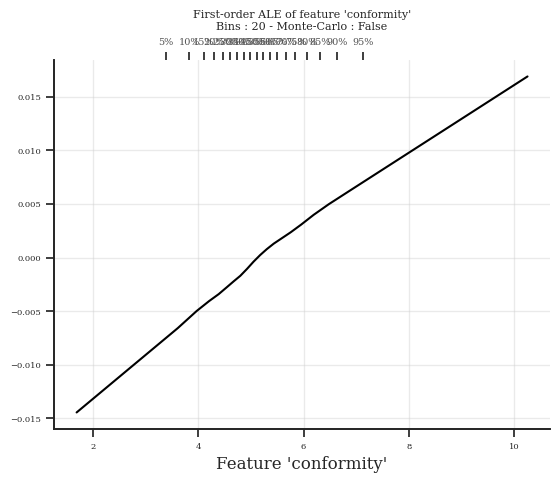

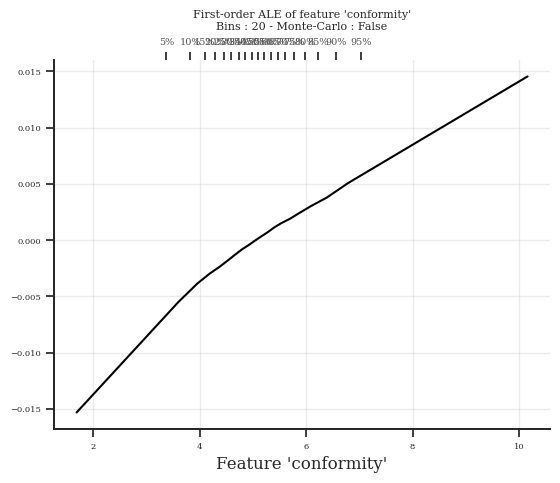

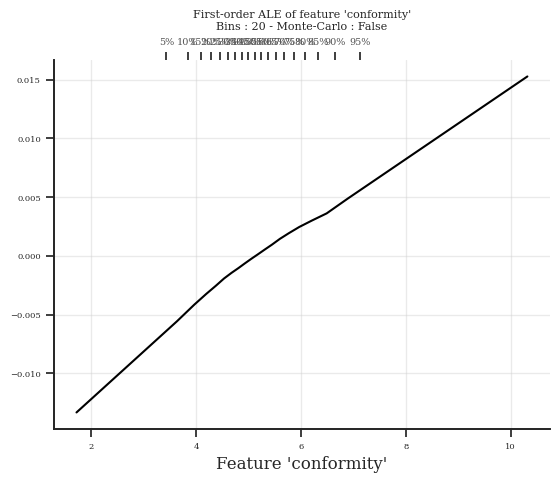

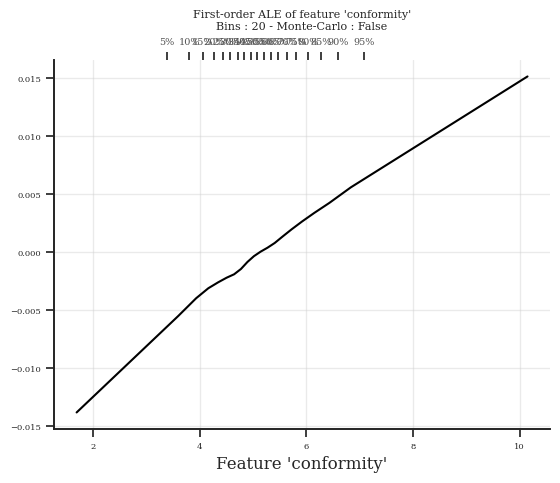

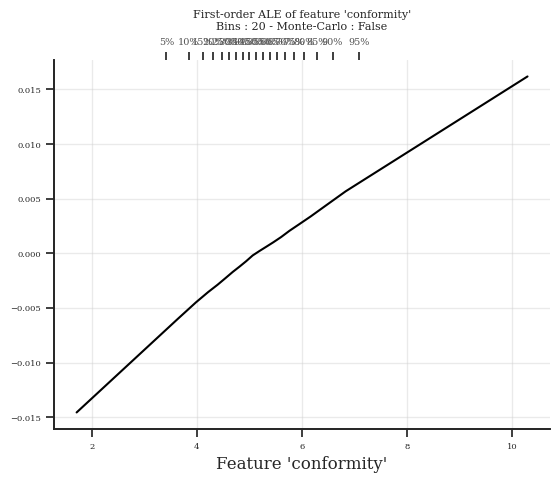

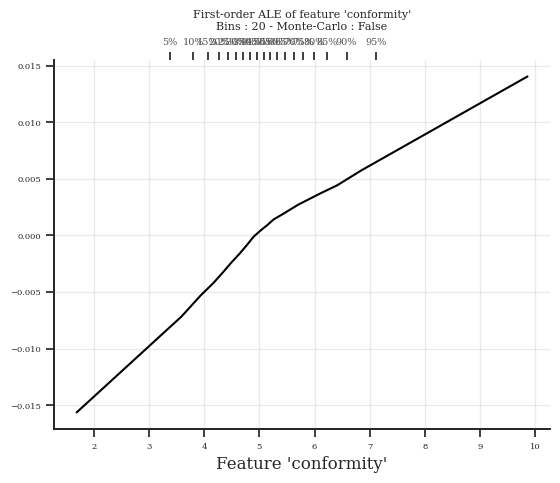

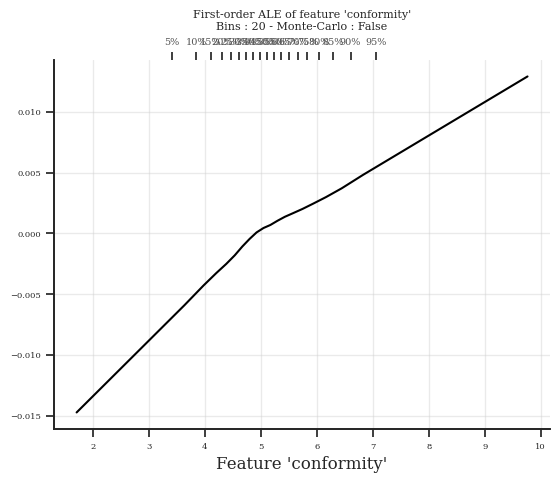

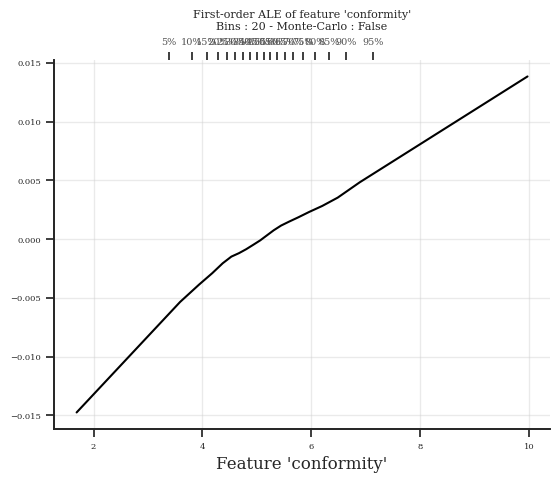

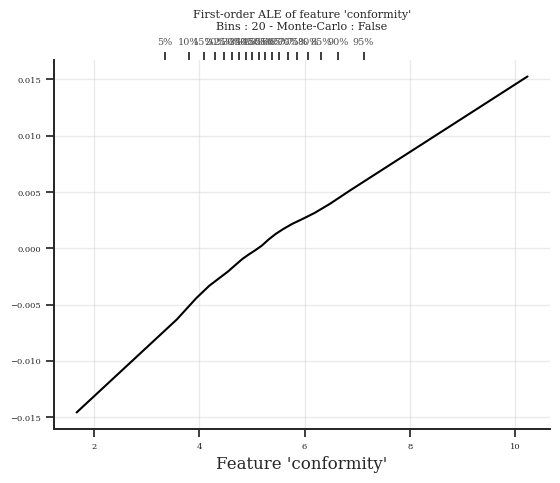

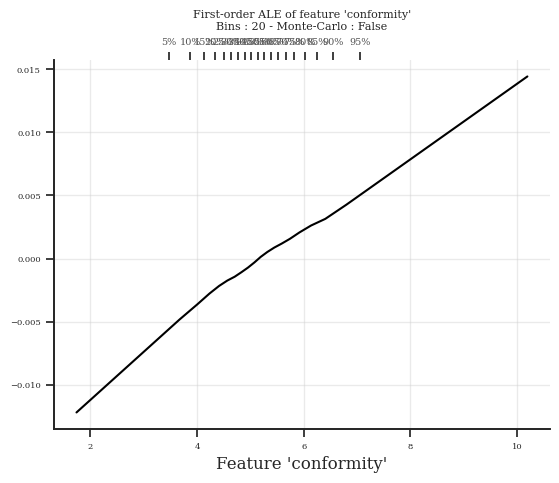

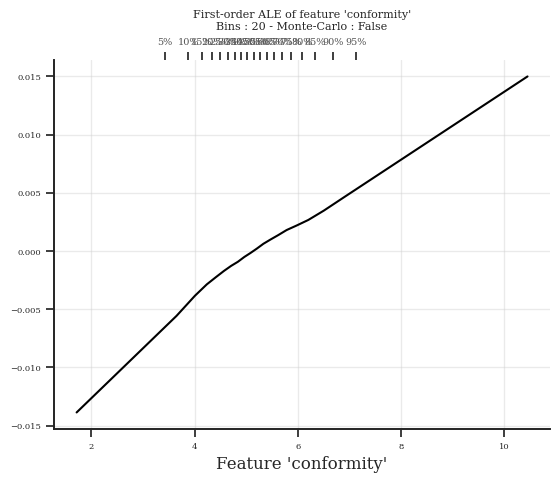

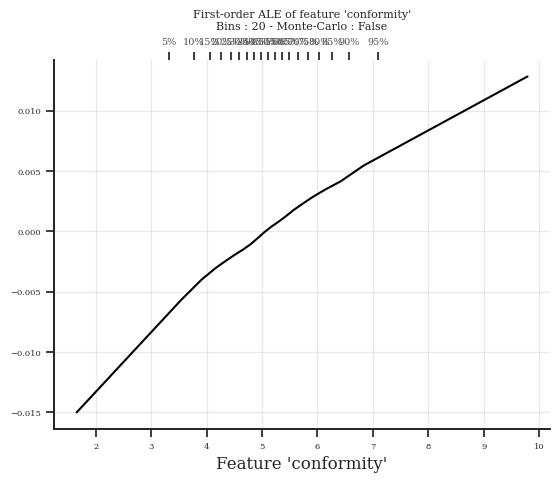

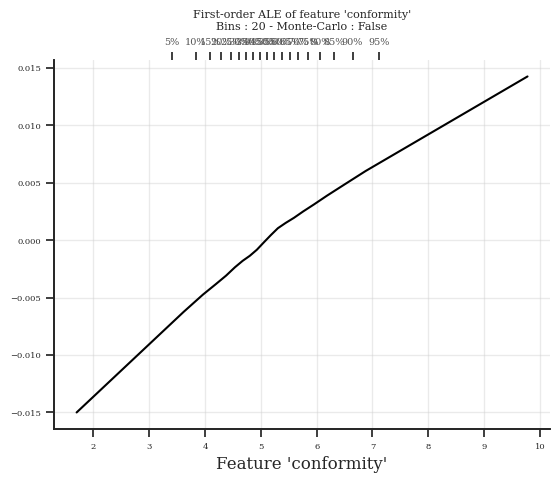

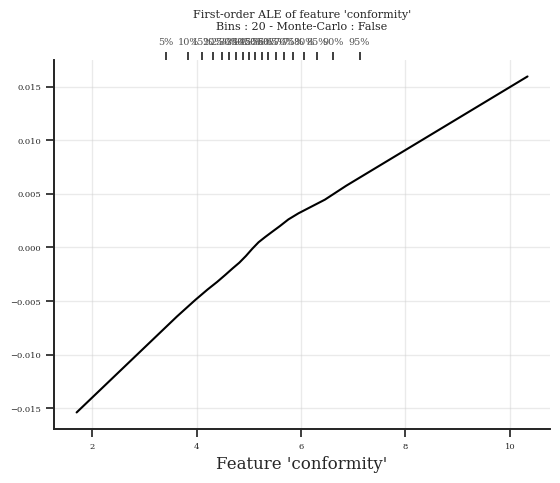

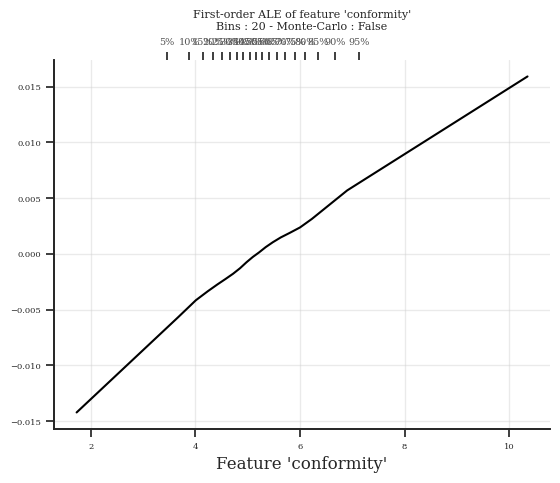

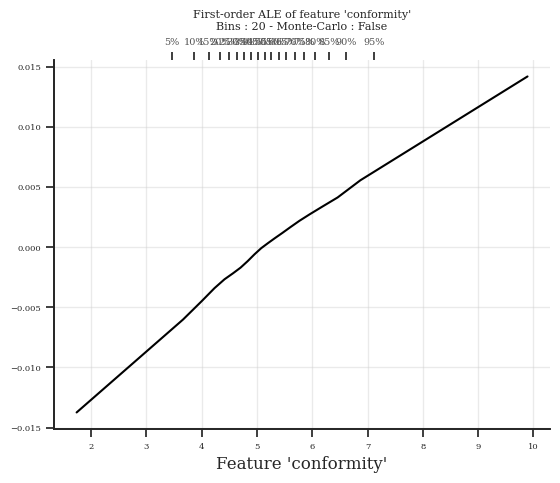

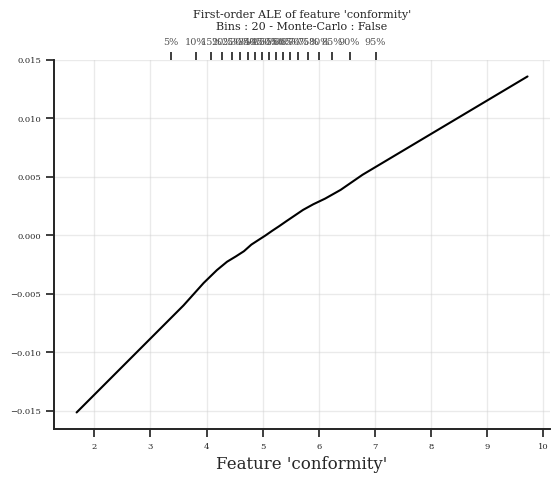

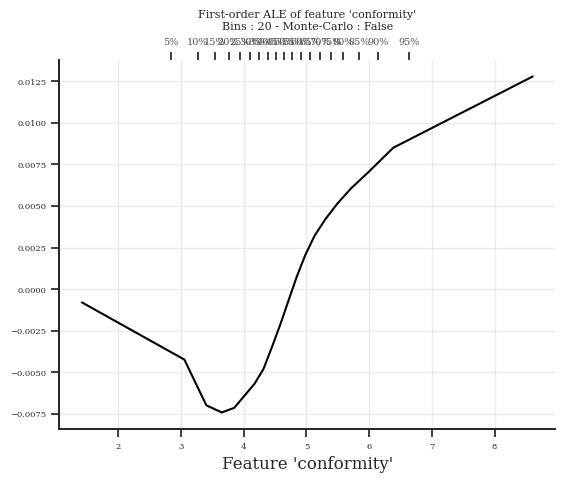

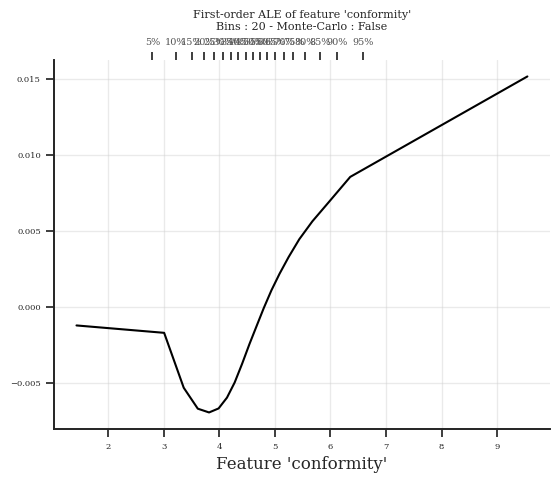

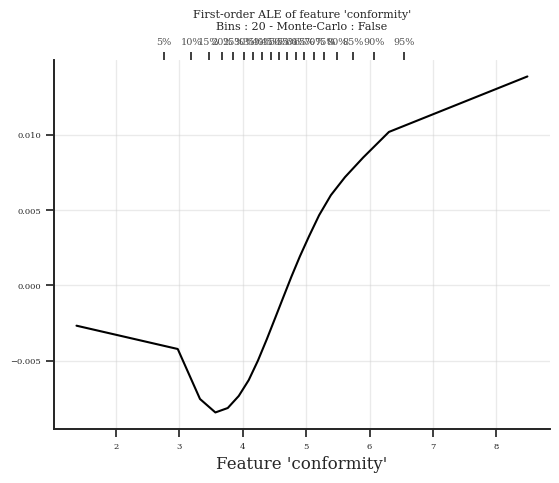

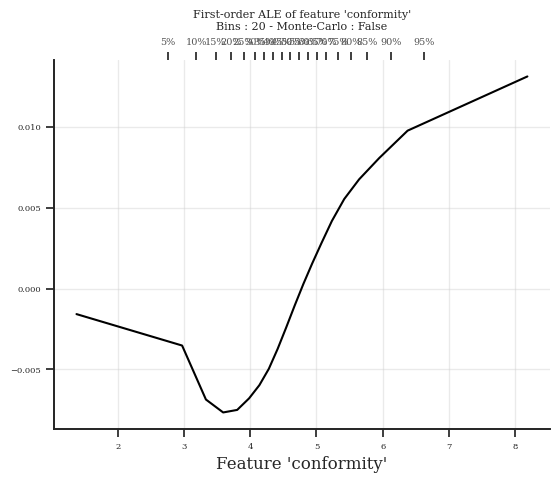

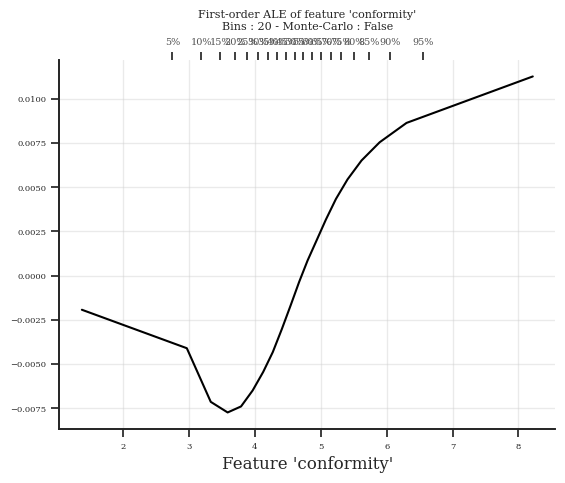

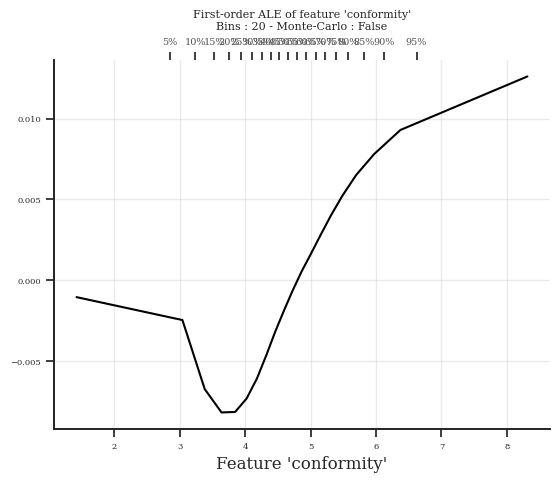

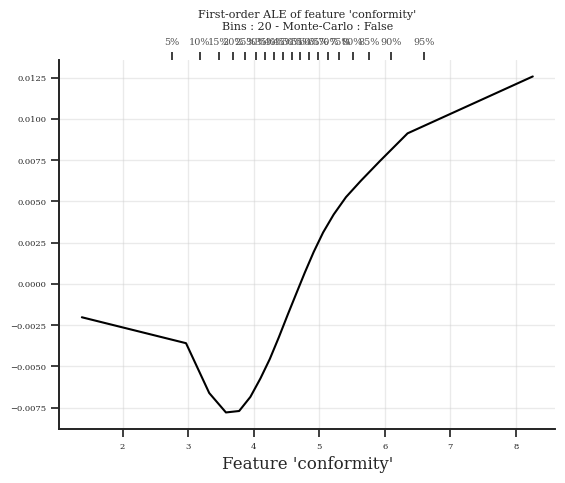

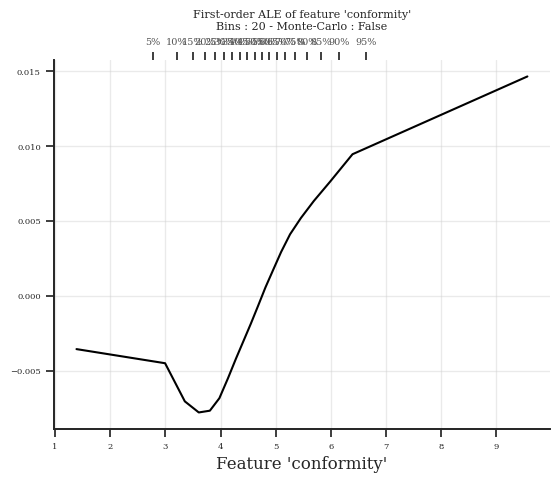

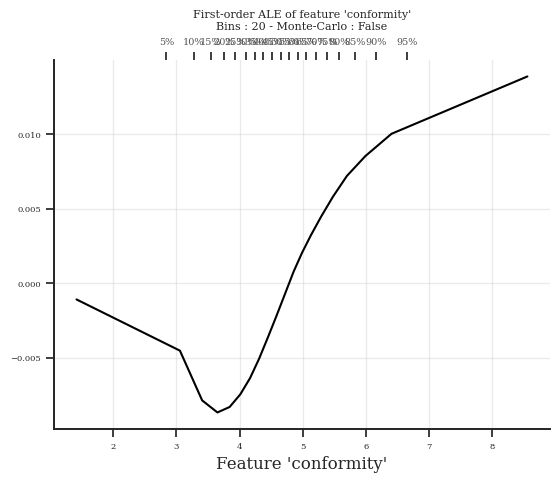

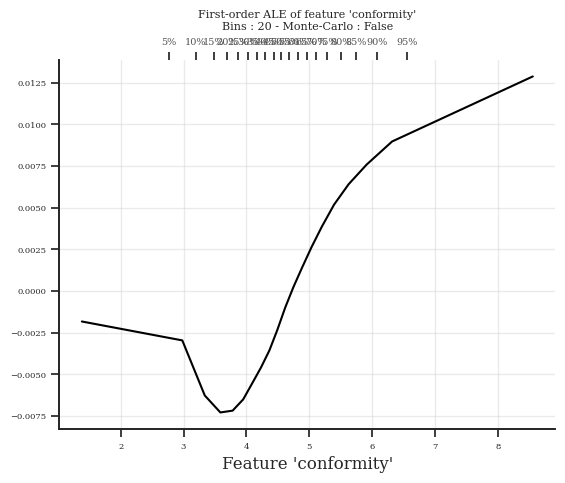

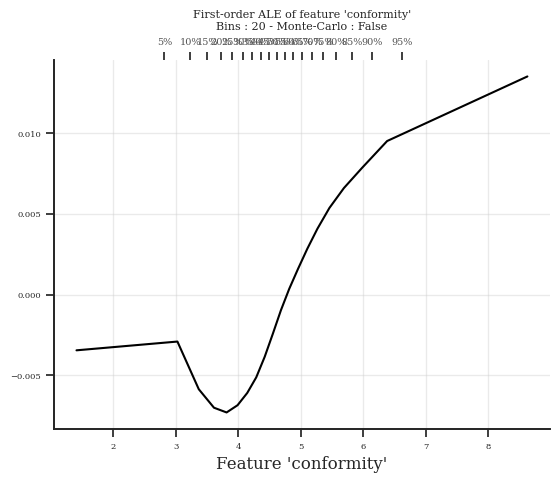

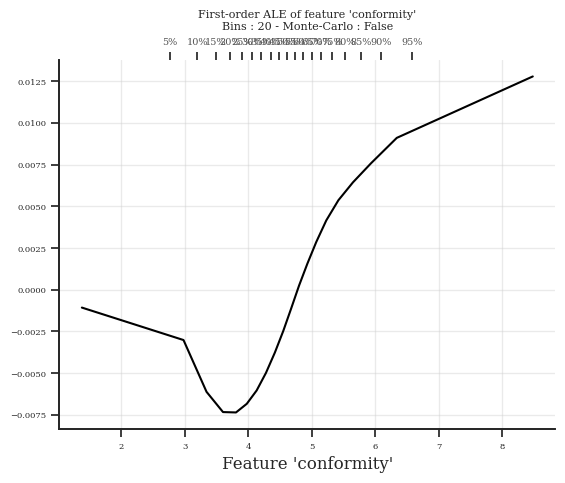

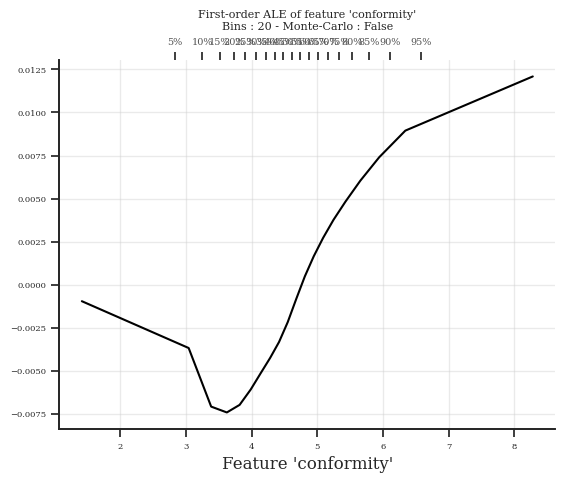

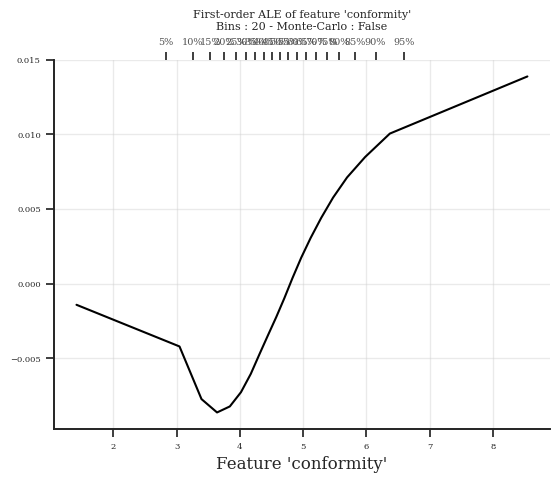

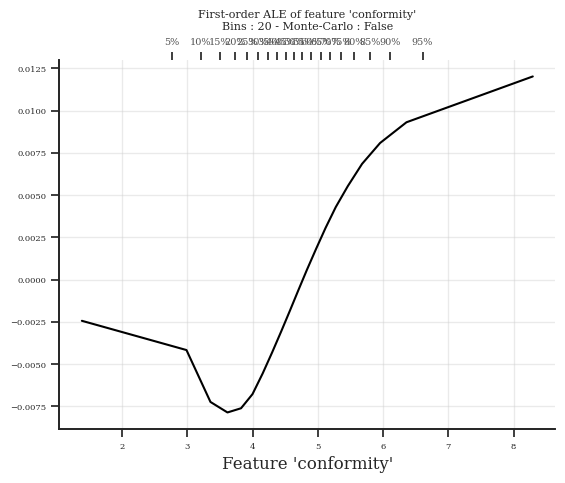

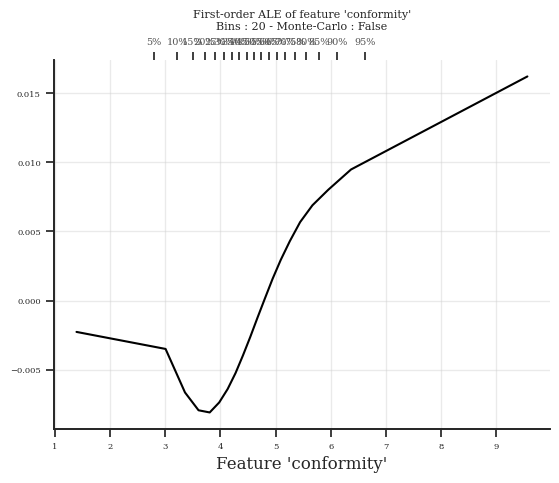

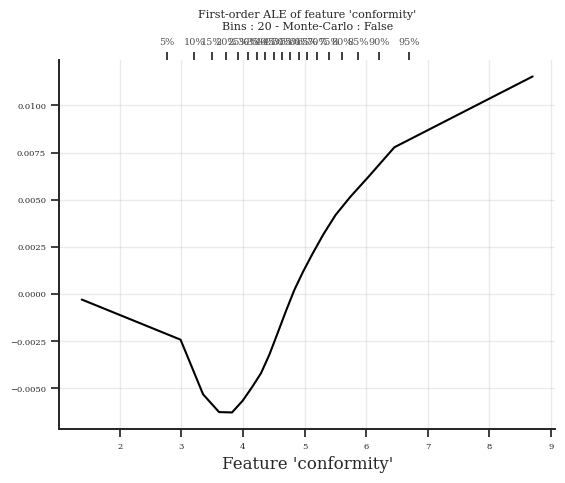

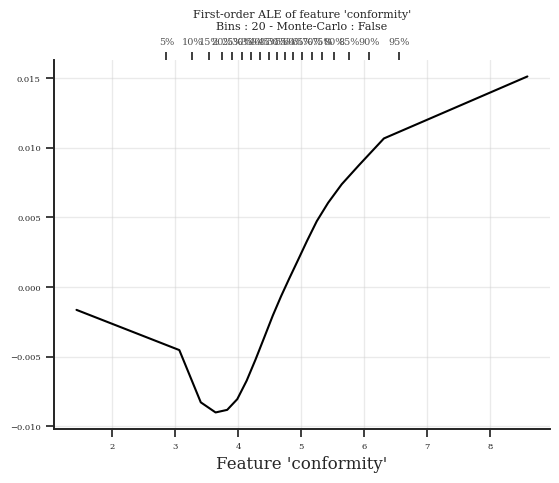

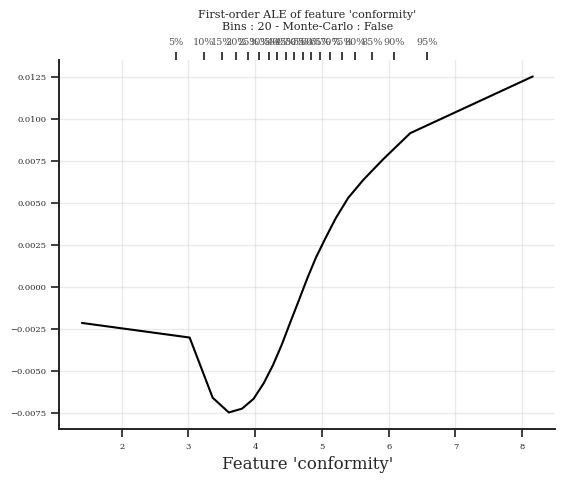

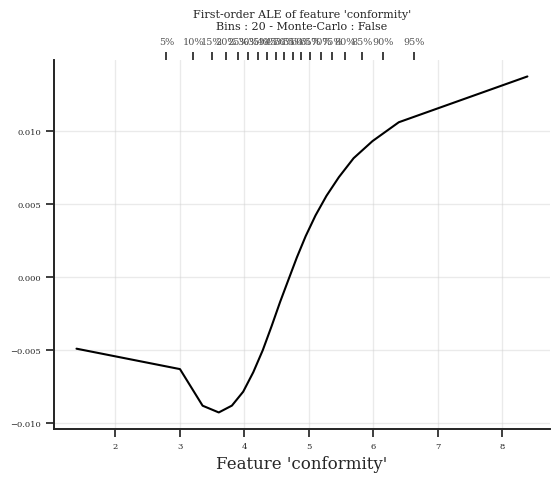

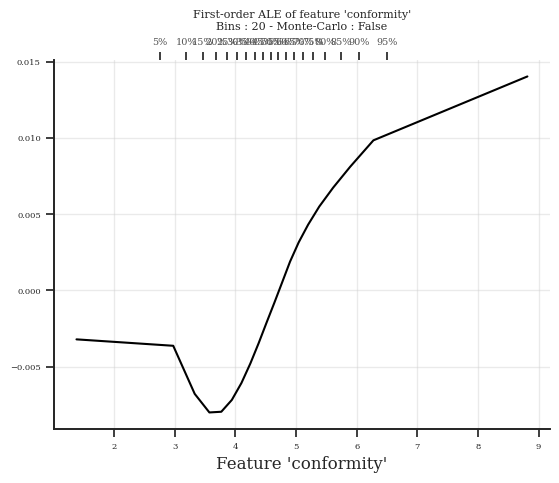

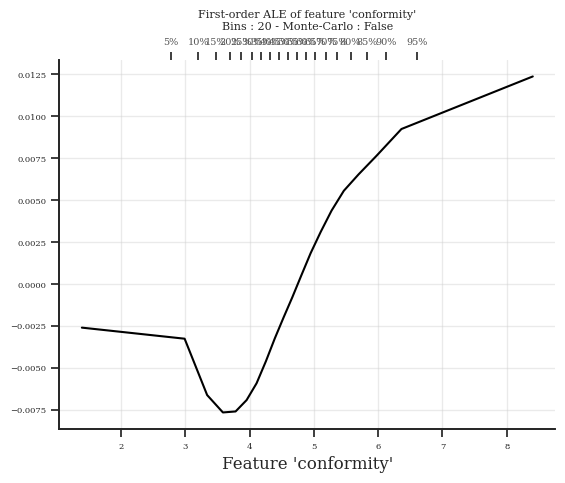

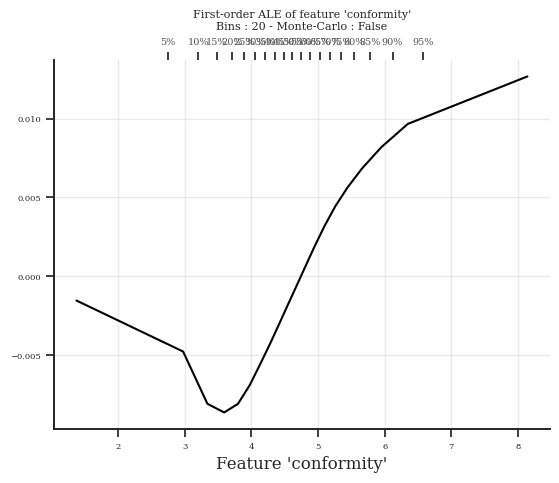

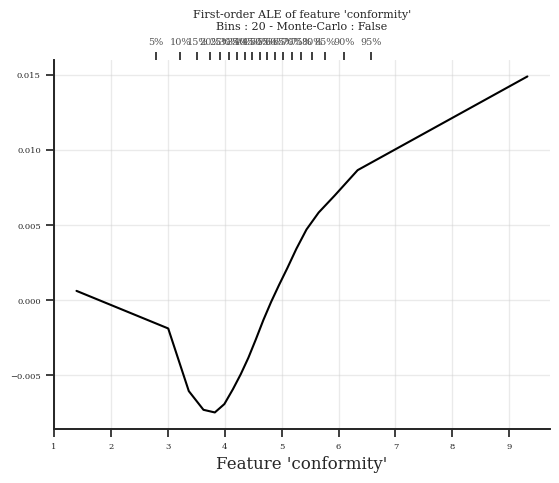

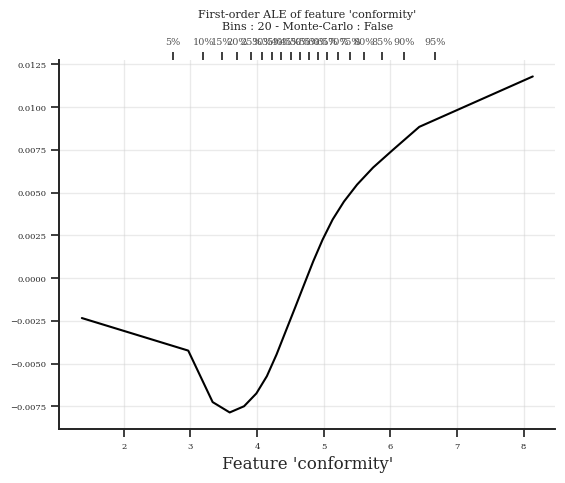

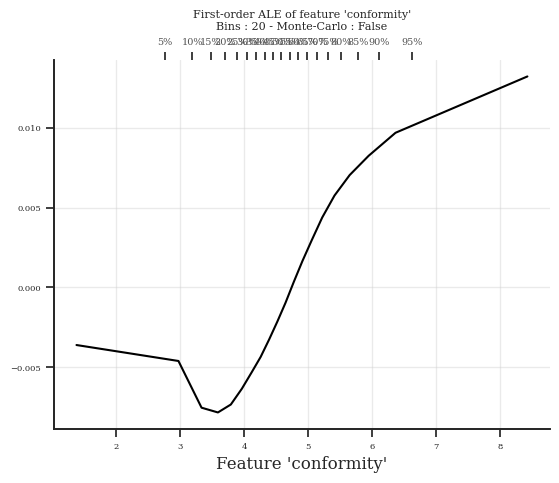

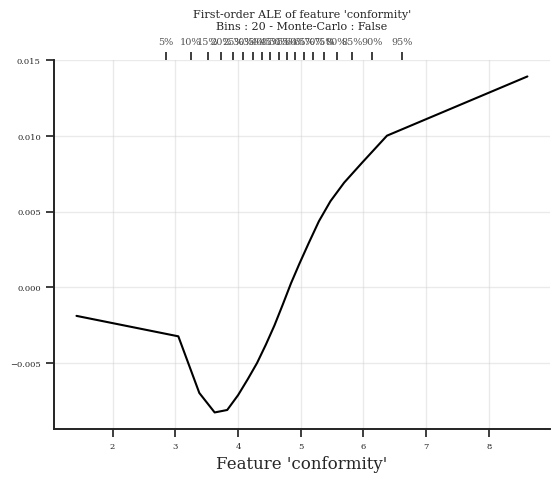

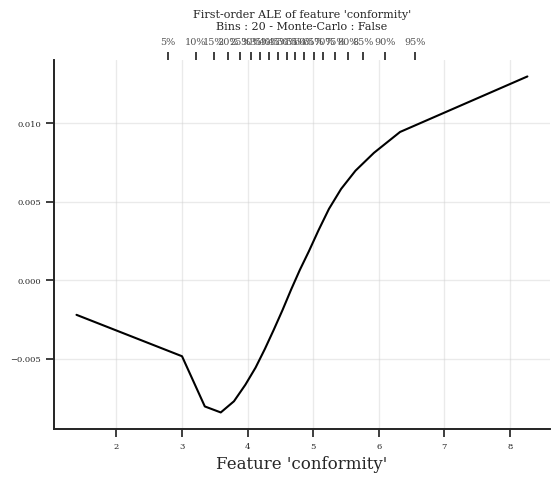

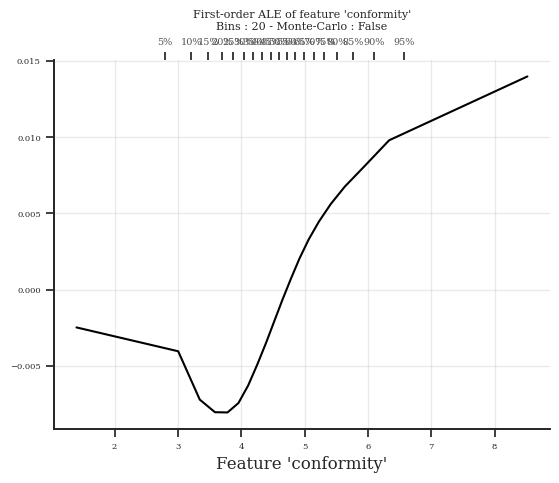

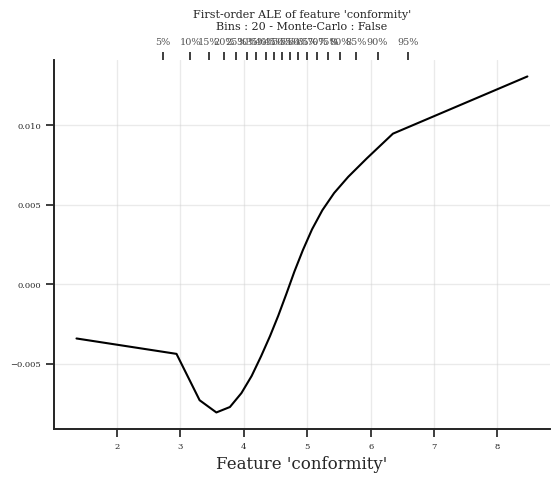

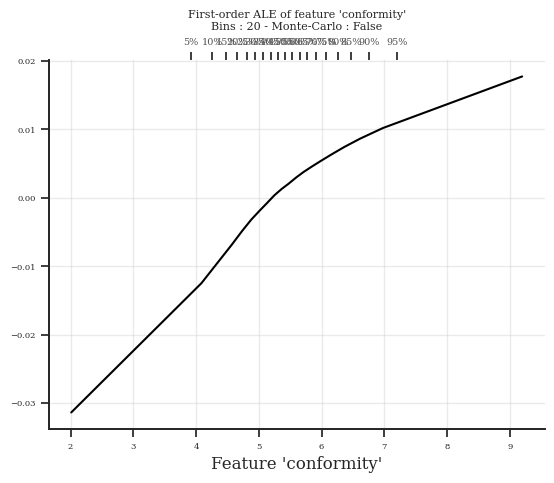

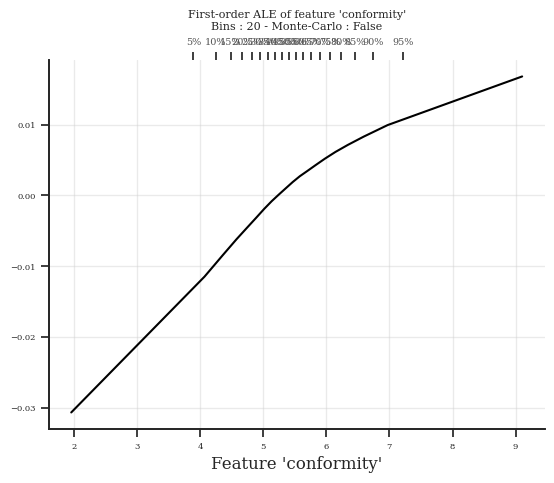

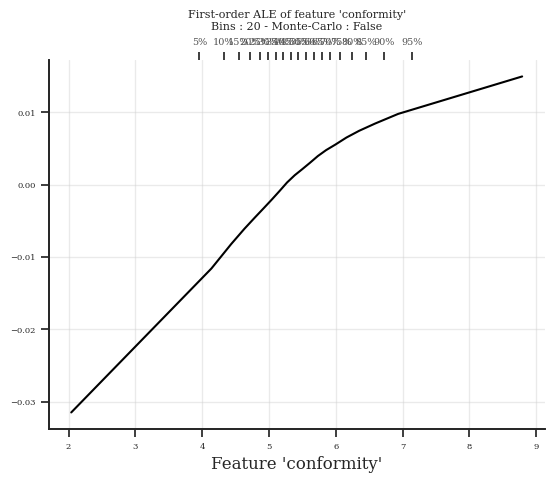

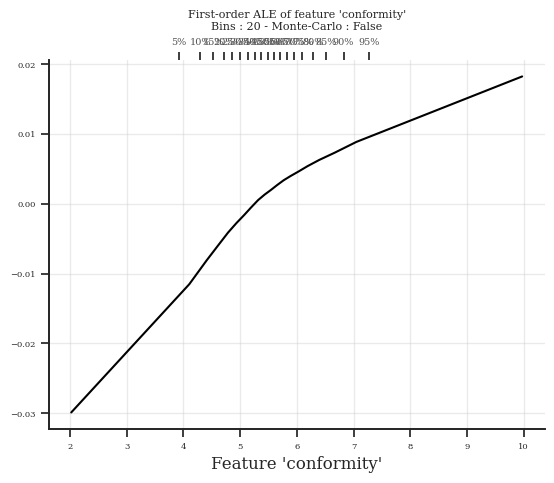

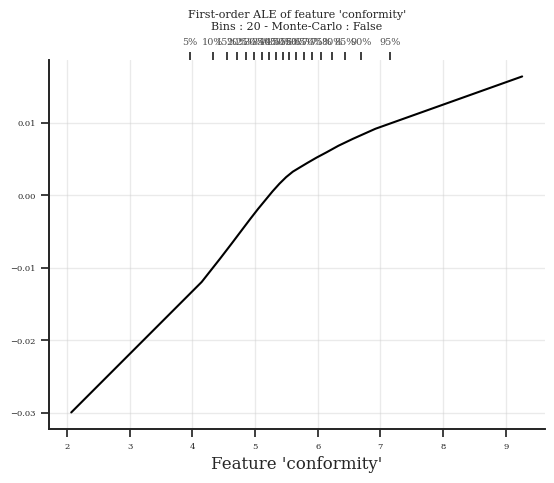

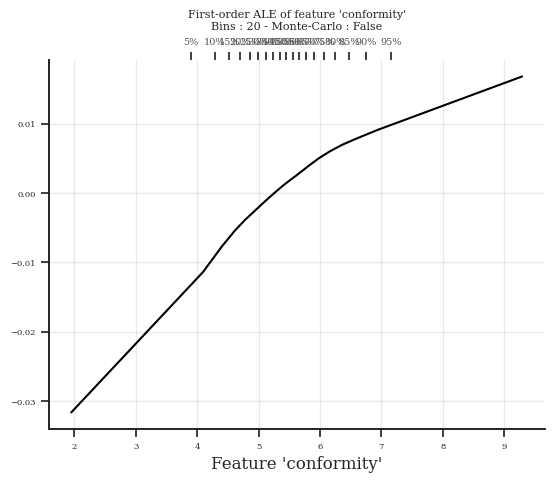

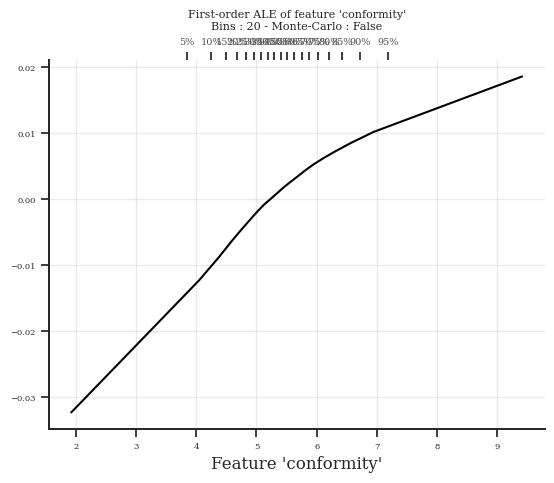

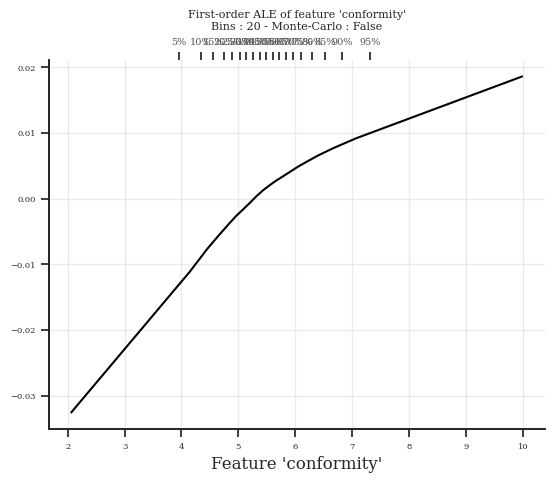

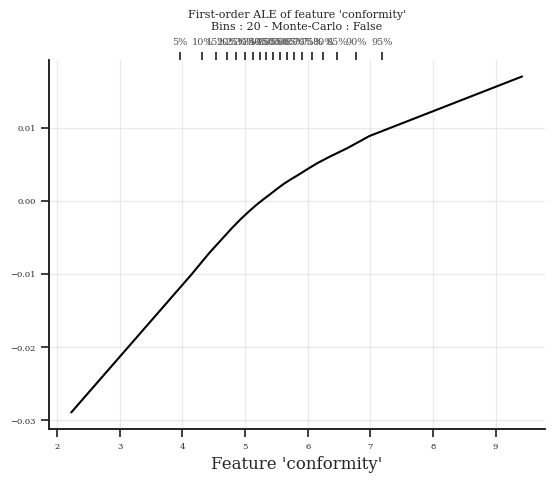

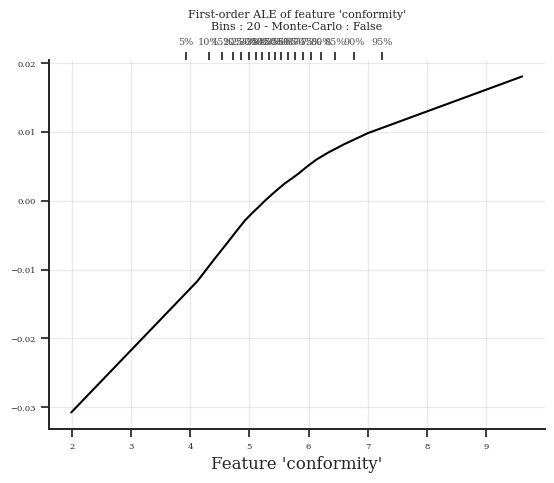

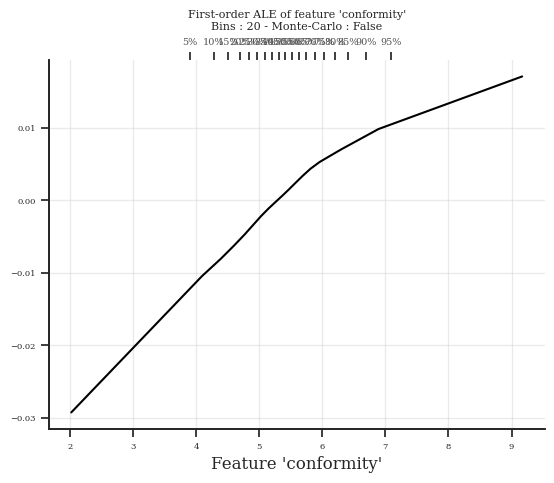

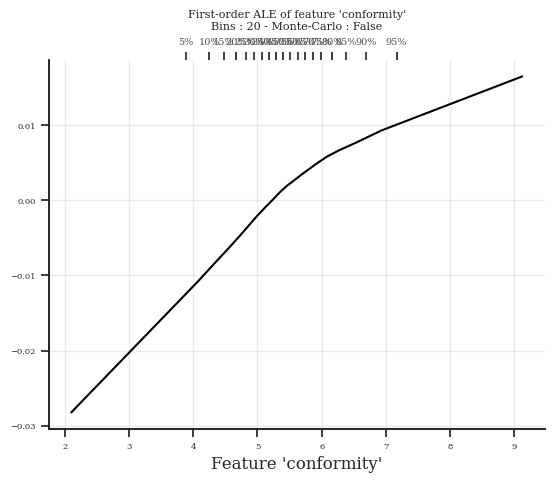

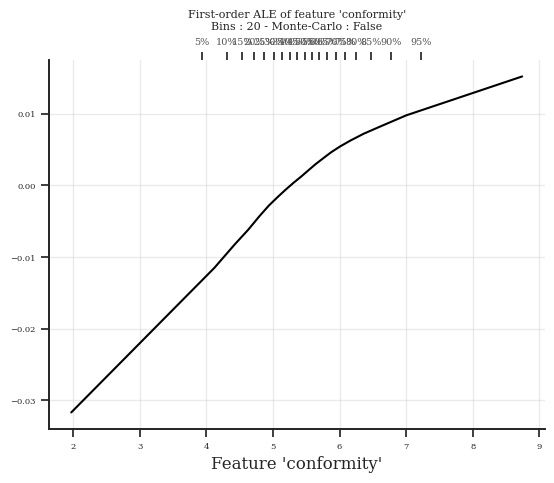

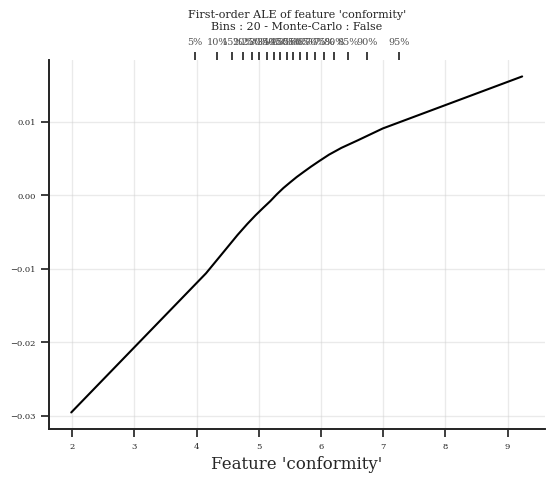

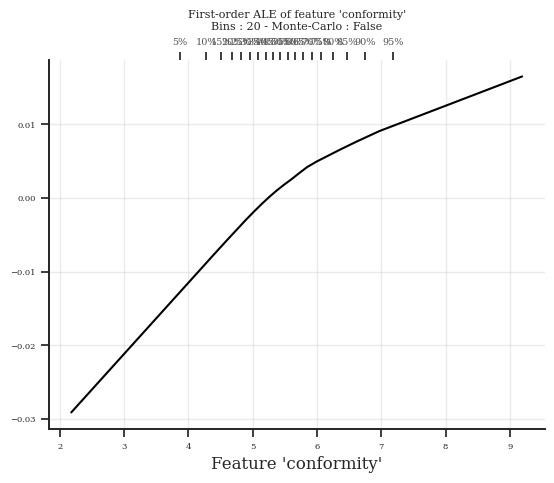

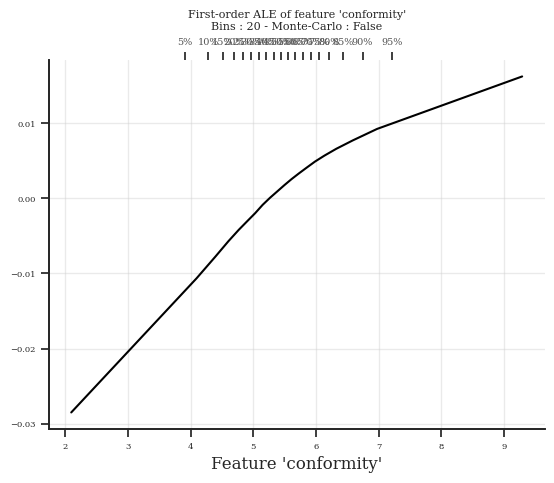

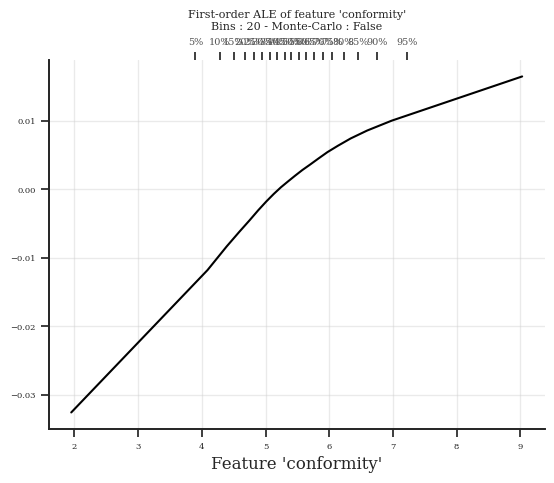

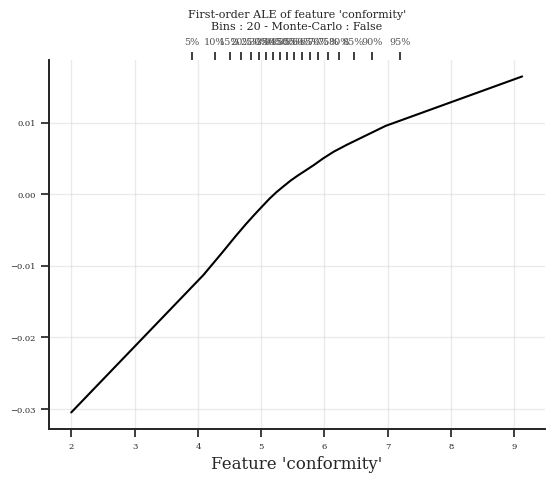

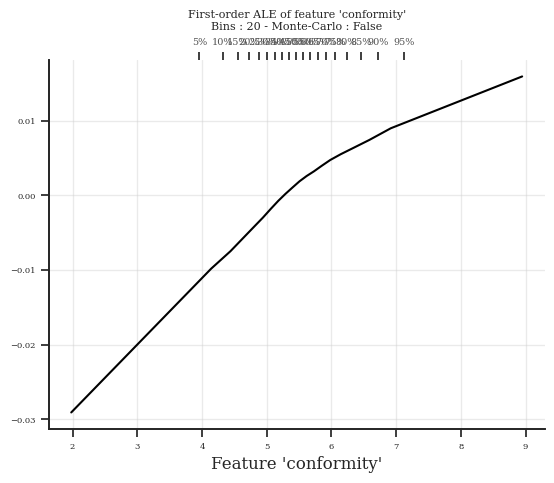

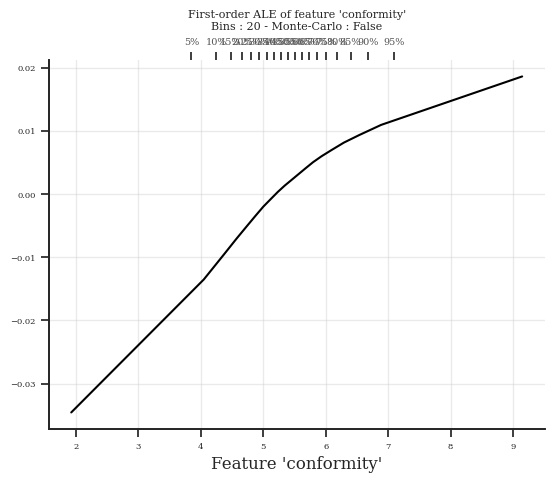

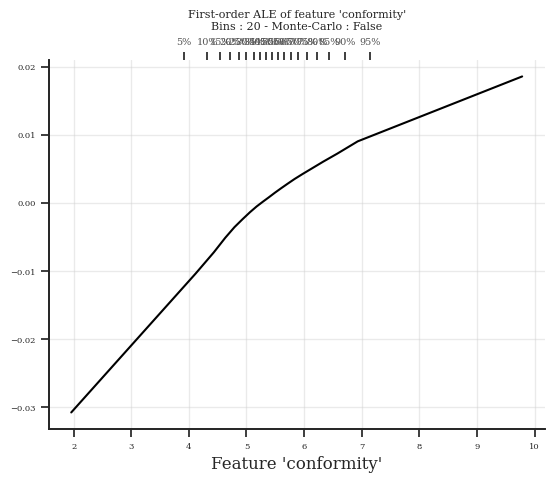

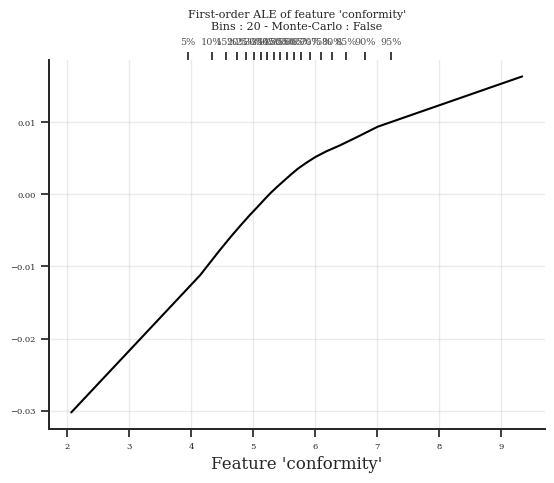

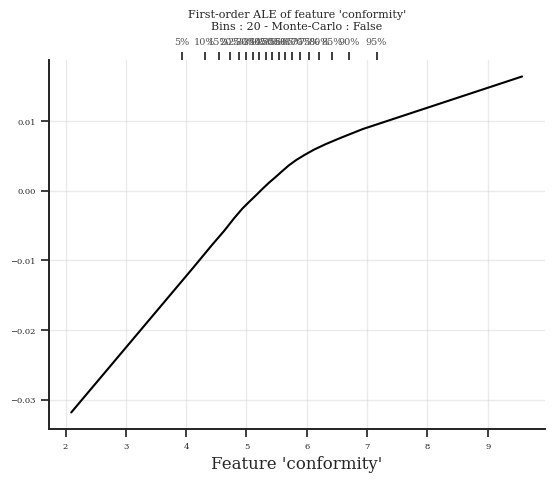

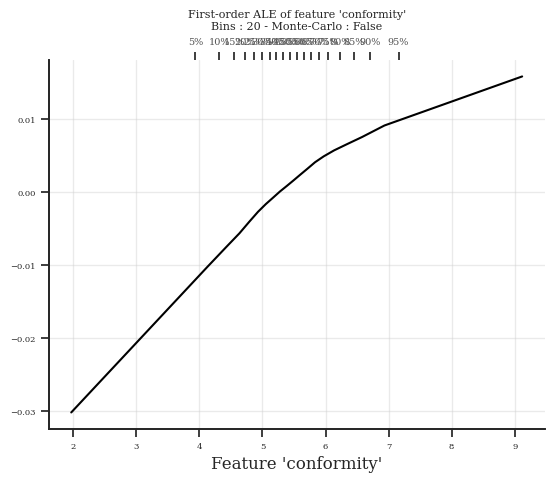

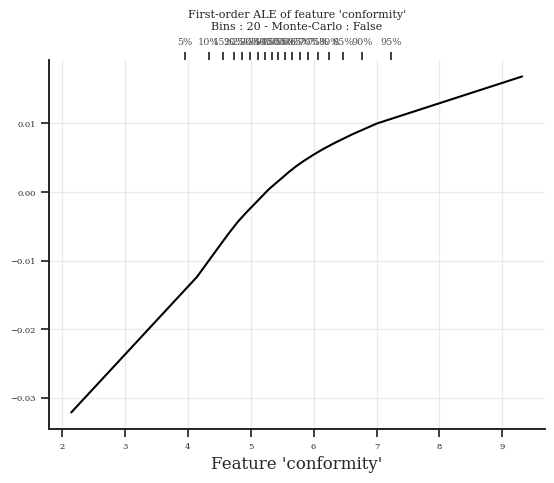

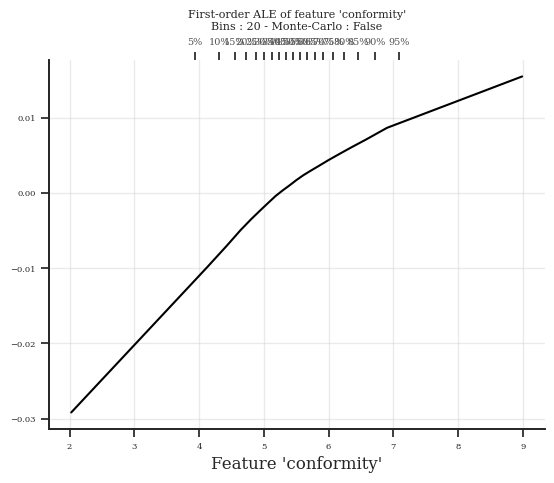

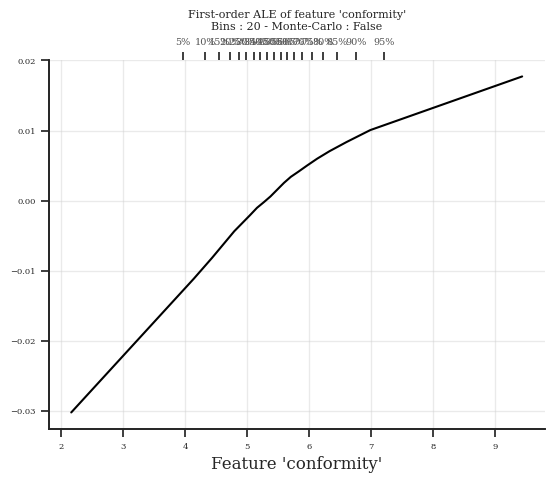

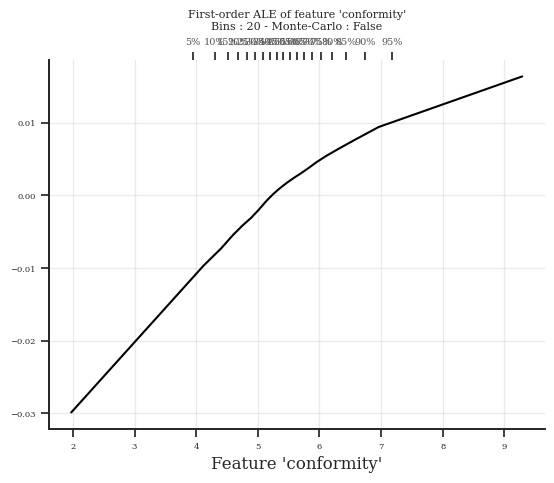

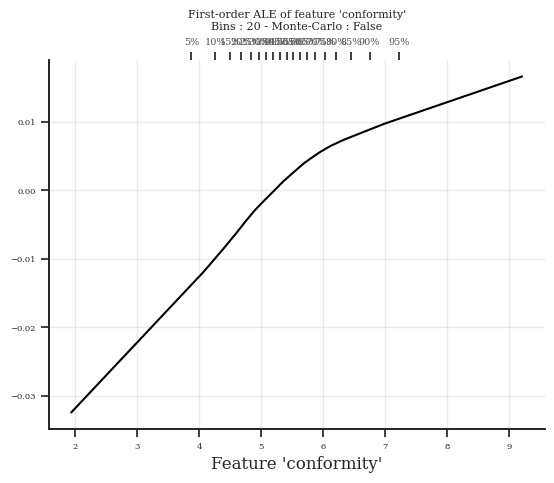

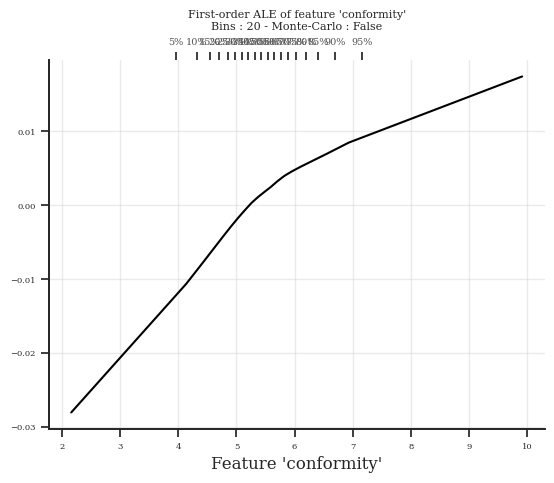

In [10]:
# 计算全局ale，转化成xarray的格式
bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)

bins = (quantiles[1:] + quantiles[:-1]) / 2

data_vars = {}
n_bootstrap = 30


for i in [0,1,2]:
    dataset_year = [dataset19, dataset20, dataset23][i]
    year = [2019, 2020, 2023][i]
    ale = []
    
    for _ in range(n_bootstrap):
        sub_dataset = dataset_sampling(dataset_year, 1000)
        ale_fig, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_'+str(exp_name), b_use_predicted_confounders=False, features = ['conformity'], default_quantiles=quantiles)
        ale.append(ale_1st)
    data_vars[f"conformity__RNN_Model_{year}__ale"] = (["n_bootstrap", f"n_bins__conformity"], ale)

data_vars[f"conformity__bin_values"] = (["n_bins__conformity"], bins)

data_vars[f"conformity"] = (["n_X"],dataset['treatments'][:,:,0].flatten())
    
ale_dataset = xr.Dataset(
    data_vars=data_vars,
    #coords={
    #    "n_bootstrap": np.arange(ale.shape[0]), 
    #    f"n_bins__{feature_name}": np.arange(quantiles.shape[0]),  
    #    "n_X": np.arange(flattened_values.shape[0]),  
    #},
    attrs={
        "estimator_output": "raw",
        "estimators used": ['RNN_Model_2019', 'RNN_Model_2020', 'RNN_Model_2023'],
        "method": "ale",
        "dimension": "1D",
        "features used": "conformity",
    }
)


In [6]:
# save
# ale_dataset.to_netcdf(path='figures/figure_data/fig_1c.nc')

# read
ale_dataset = xr.open_dataset('./figures/figure_data/fig_2c.nc')
# ale_dataset

In [7]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset['conformity__RNN_Model_2019__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2019__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset['conformity__RNN_Model_2020__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2020__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset['conformity__RNN_Model_2023__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset['conformity__RNN_Model_2023__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

KeyError: 'conformity__RNN_Model_2019__ale'

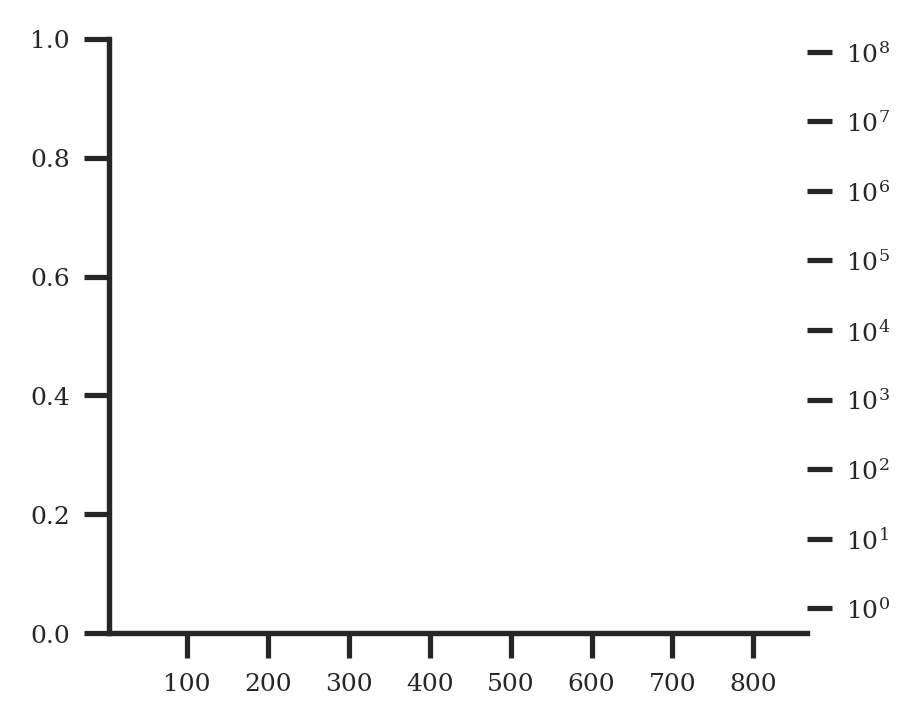

In [15]:
bins_to_keep = ale_dataset['n_bins__conformity'] != ale_dataset['n_bins__conformity'].loc[-1]
ale_dataset_select = ale_dataset.sel(n_bins__conformity=bins_to_keep)

estimator = [('RNN_Model_2019',RandomForestRegressor()),
            ('RNN_Model_2020',RandomForestRegressor()),
            ('RNN_Model_2023',RandomForestRegressor())]

explainer = skexplain.ExplainToolkit(estimator)

# 生成 cubehelix 调色盘
cubehelix_palette = sns.cubehelix_palette(n_colors=3)


fig, ax = explainer.plot_ale(
                                   ale = ale_dataset_select,
                                   features='conformity',
                                   display_units=plotting_config.display_units,
                                   display_feature_names=plotting_config.display_feature_names,
                                   line_kws={'marker': 'o', 'markersize':1.5,'linewidth':1, 'line_colors': cubehelix_palette},
hist_color = 'white', 
    edge_color= 'white'

                                  )

# ax.set_xscale('log')
ax.set_xlim(left = 0, right = 900)
# ax.set_xlim(left=1, right = 10 ** 5)
# ax.set_xlim(left=1, right = 11)
ax.set_ylim(bottom = 0.965, top = 1.02)

ax.axhline(y=1, color='black', ls='--', lw=0.8)

# ax.tick_params(axis='y', right=False, labelright=False)
# ax.tick_params(axis='y', tick1On=False, tick2On=False)
# ax.spines['bottom'].set_visible(False)
# ax.set_xticks(conformity_bin_values_original)
# ax.set_xticklabels([f'{val:.2f}' for val in conformity_bin_values_original])
ax.set_ylabel('Centered ALE', fontsize = 8)
ax.legend()

fig.axes[3].remove()
fig.axes[2].remove()
fig.axes[1].remove()



data = ale_dataset['conformity'].values
if len(data) > 1000:
    data_sample = np.random.choice(data, size=1000, replace=False)
else:
    data_sample = data
sns.rugplot(data_sample, ax=ax, color=cubehelix_palette[-2], alpha=0.1)

# plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_log_log.png',  dpi=300)
plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_SCI_log.png',  dpi=300)
# plt.savefig('./figures/fig_1c_yearly_SCI_ale_1st_raw-1.png',  dpi=300)
plt.show()

### 2.3 将figB和figC整合到一张图

In [55]:
ale_dataset_select = xr.open_dataset('figures/figure_data/fig_1b_noCI.nc')
ale_dataset_yearly = xr.open_dataset('figures/figure_data/fig_1c.nc')

数值还原

In [56]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset_select['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset_select['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset_select['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset_select['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset_select['conformity__RNN_Model__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_select['conformity__RNN_Model__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

In [57]:
# 还原SCI的log值
conformity_bin_values_log = ale_dataset_yearly['conformity__bin_values'].values
conformity_bin_values_original = np.exp(conformity_bin_values_log)-1
ale_dataset_yearly['conformity__bin_values'] = (('n_bins__conformity'), conformity_bin_values_original)

conformity_log = ale_dataset_yearly['conformity'].values
conformity_original = np.exp(conformity_log)-1
ale_dataset_yearly['conformity'] = (('n_X'), conformity_original)

# 将ALE值转换为倍数
ale_values = ale_dataset_yearly['conformity__RNN_Model_2019__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2019__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset_yearly['conformity__RNN_Model_2020__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2020__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

ale_values = ale_dataset_yearly['conformity__RNN_Model_2023__ale'].values
ale_values_original = np.exp(ale_values)
ale_dataset_yearly['conformity__RNN_Model_2023__ale'] = ([('n_bootstrap'),('n_bins__conformity')], ale_values_original)

In [58]:
# === 1) 预处理（保持不变）===
last_val_overall = ale_dataset_select['n_bins__conformity'].isel(n_bins__conformity=-1)
mask_overall = ale_dataset_select['n_bins__conformity'] != last_val_overall
ale_dataset_select_trim = ale_dataset_select.isel(n_bins__conformity=mask_overall)

last_val_yearly = ale_dataset_yearly['n_bins__conformity'].isel(n_bins__conformity=-1)
mask_yearly = ale_dataset_yearly['n_bins__conformity'] != last_val_yearly
ale_dataset_yearly_trim = ale_dataset_yearly.isel(n_bins__conformity=mask_yearly)

In [59]:
ale_dataset_select_trim

<xarray.Dataset>
Dimensions:                     (n_bootstrap: 1, n_bins__conformity: 19,
                                 n_X: 15456000)
Dimensions without coordinates: n_bootstrap, n_bins__conformity, n_X
Data variables:
    conformity__RNN_Model__ale  (n_bootstrap, n_bins__conformity) float64 0.9...
    conformity__bin_values      (n_bins__conformity) float32 4.005 ... 866.1
    conformity                  (n_X) float32 126.1 119.3 81.13 ... 235.4 100.5
Attributes:
    estimator_output:  raw
    estimators used:   RNN_Model
    method:            ale
    dimension:         1D
    features used:     conformity

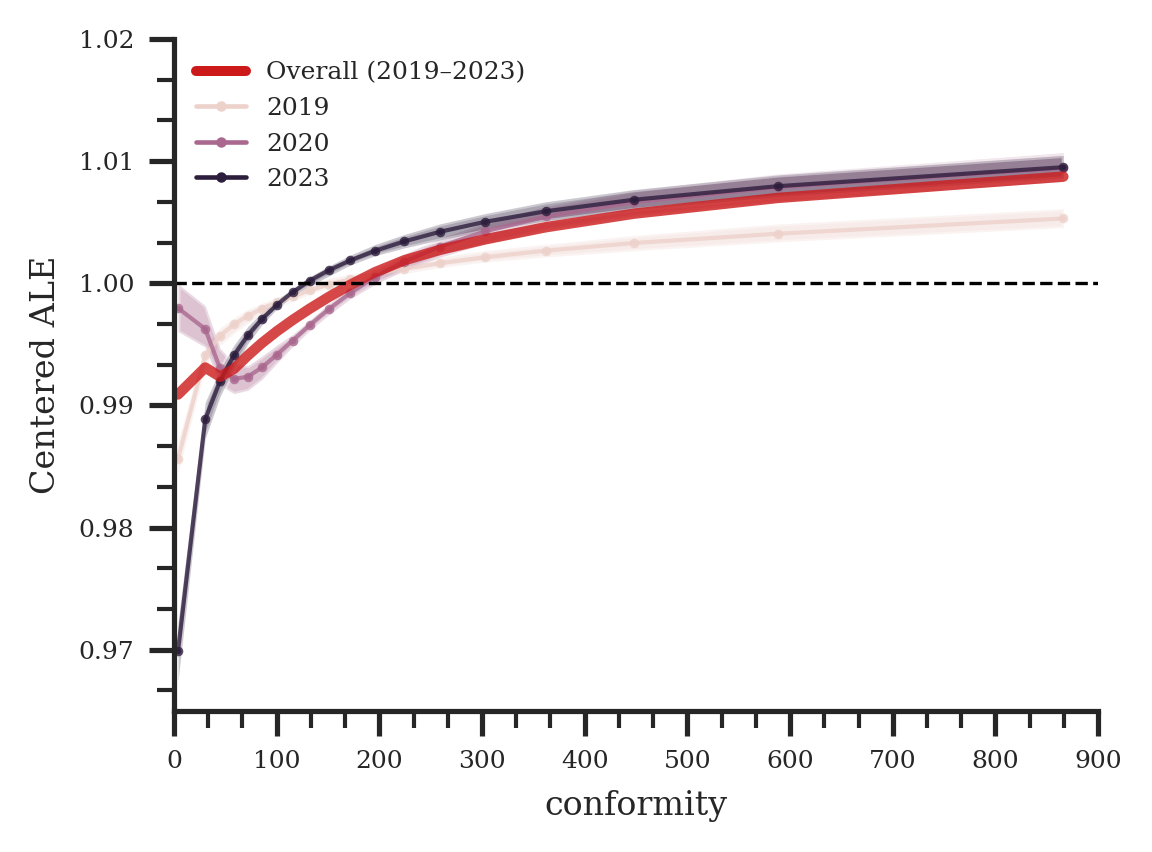

In [77]:
# 绘图
# === 2) explainer（保持不变）===
estimator_overall = [('RNN_Model', RandomForestRegressor())]
explainer_overall = skexplain.ExplainToolkit(estimator_overall)

estimator_yearly = [
    ('RNN_Model_2019', RandomForestRegressor()),
    ('RNN_Model_2020', RandomForestRegressor()),
    ('RNN_Model_2023', RandomForestRegressor()),
]
explainer_yearly = skexplain.ExplainToolkit(estimator_yearly)

# === 3) 调色盘 ===
cubehelix_palette = sns.cubehelix_palette(n_colors=3)

# === 4) 绘图 ===
fig, ax = plt.subplots(figsize=(4,3), dpi=300)

# 1. 分年度三条 ALE —— 仍然用 line_colors=cubehelix_palette
explainer_yearly.plot_ale(
    ale=ale_dataset_yearly_trim,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={'marker': 'o', 'markersize': 1.3, 'linewidth': 1, 'line_colors': cubehelix_palette},
    add_hist=False,
    ax=ax
)

# 2. 整体三年 ALE —— 关键改动：用 line_colors=['black']，不要用 color='black'
explainer_overall.plot_ale(
    ale=ale_dataset_select_trim,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    line_kws={'linewidth':2.5, 'line_colors':[[0.8, 0.1, 0.1]] },
    add_hist=False,
    plot_confidence=False,
    ax=ax
)

# === 5) 统一外观 ===
ax.axhline(y=1, color='black', ls='--', lw=0.8)
ax.set_xlim(left=0, right=900)
ax.set_ylim(bottom=0.965, top=1.02)
ax.set_ylabel('Centered ALE', fontsize=8)

# === 6) 图例（手工）===
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], linewidth=2.4, color=[0.8, 0.1, 0.1], markersize=2, label='Overall (2019–2023)'),
    Line2D([0], [0], marker='o', linewidth=1.1, color=cubehelix_palette[0], markersize=1.5, label='2019'),
    Line2D([0], [0], marker='o', linewidth=1.1, color=cubehelix_palette[1], markersize=1.5, label='2020'),
    Line2D([0], [0], marker='o', linewidth=1.1, color=cubehelix_palette[2], markersize=1.5, label='2023'),
]
ax.legend(handles=legend_lines, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('./figures/fig_1b_global_and_yearly_SCI_ale_1st_SCI_log.png',  dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>

## 3. ICE curve (Fig2.d)

### some functions

In [4]:
# # 选取一定样本，对个体计算ale
# def select_indiviudal_from_dataset(dataset, index, overall=32000):
#     indiv_indices = [index, overall+index, overall*2 + index]
#     indiv_dataset = {key: value[indiv_indices] for key, value in dataset.items()}
#     return indiv_dataset

data selection

In [3]:
def _dataset_length(dataset):
    # 用任一字段的第一维推断样本总数 N
    return min(arr.shape[0] for arr in dataset.values())

def _infer_block_len(dataset, overall=None):
    """
    兼容旧逻辑：
    - 如提供 overall（例如 32000），严格按它作为分块长度，并检查是否越界；
    - 否则用真实长度 N // 3 自动推断 block（保证不越界）。
    """
    N = _dataset_length(dataset)
    if overall is not None:
        if 3 * overall > N:
            raise ValueError(
                f"overall={overall} 需要的最小样本数为 {3*overall}，"
                f"但当前数据只有 {N}。请减小 overall 或更换数据。"
            )
        return overall
    # 自动推断：尽量复现“等长三段”的意图
    block = N // 3
    if block == 0:
        raise ValueError(f"数据太短（N={N}），无法分成三段。")
    return block

def build_individual_dataset_fixed_offsets(dataset, n_bootstrap=1000, overall=None):
    """
    保持原始结果不变的安全实现：
    第 i 次抽样返回 [i, i+block, i+2*block]，其中 block 来自 overall 或 N//3。

    返回：
      indiv_dataset: 与原字段同名的新数据集，第一维长度为 n_bootstrap*3
      chosen_idx: 形状 (n_bootstrap, 3) 的索引记录
    """
    # 1) 确定 block，检查边界
    block = _infer_block_len(dataset, overall=overall)
    if n_bootstrap > block:
        raise ValueError(
            f"n_bootstrap={n_bootstrap} 不能大于分块长度 block={block}，"
            f"否则 i+2*block 会越界。请减小 n_bootstrap 或增大数据量/overall。"
        )

    # 2) 生成与旧代码完全一致的索引序列
    idx0 = np.arange(n_bootstrap, dtype=np.int64)
    chosen_idx = np.stack([idx0, idx0 + block, idx0 + 2 * block], axis=1)
    flat_idx = chosen_idx.reshape(-1)  # 展平成一维，便于一次性索引

    # 3) 一次性切片到新数组（保持 dtype 与形状一致）
    indiv_dataset = {}
    for key, arr in dataset.items():
        # arr 的形状如 (N, 161, 23)/(N, 161, 1)/(N,) 等
        sliced = arr[flat_idx]
        indiv_dataset[key] = sliced  # 直接返回切片结果，更快更干净

    return indiv_dataset, chosen_idx


In [4]:
def construct_relevant_dataframe(dataset, model_name, b_use_predicted_confounders,):
    model_name = model_name + '_use_confounders_' + str(b_use_predicted_confounders)
    model_root = os.path.join('results', model_name)
    config = {'covariate_cols':['gender','age','income','weekday_0','weekday_1','weekday_2','weekday_3','weekday_4', 'weekday_5', 'weekday_6',
           'voluntary','festivals','year_0','year_1','year_2','edu','married','dist_yes','density',
                           'temperature','percipit','E1','E2'],
            'treatment_cols':['conformity'],
             }
    
    # shape of data
    num_samples, length, num_covariates = dataset['covariates'].shape
    _, _, num_treatments = dataset['treatments'].shape
    num_years = 3
    FE_predict = Feature_Engineering(dataset, for_factor_model = False)
    X = FE_predict.construct_dataframe(config)
    dataset['output_means'] = FE_predict.scale_params['outcomes'][:, 0]
    dataset['output_stds'] = FE_predict.scale_params['outcomes'][:, 1]
    # add timeline and week column
    X['timeline'] = np.tile(np.arange(length), num_samples)
    start_date = pd.Timestamp('2019-12-21')
    X['date'] = X['timeline'].apply(lambda x: start_date + pd.Timedelta(days=x))
    X['week'] = ((X['date'] - start_date).dt.days / 7).astype(int)
    X['pid'] = np.repeat(np.arange(int(num_samples/3)), length*3)
    
    # ############################################################################################
    def ale_use_predict(X, dataset, config, model_root, FE_predict, b_use_predicted_confounders):
        # change data
        mod_dataset = dataset.copy()
        # 将修改完的值添加到mod_dataset
        covariate_shapes = dataset['covariates'].shape
        mod_dataset['covariates'] = X[config['covariate_cols']].values.reshape(covariate_shapes[0],covariate_shapes[1],covariate_shapes[2])
        treatment_shapes = dataset['treatments'].shape
        mod_dataset['treatments'] = X[config['treatment_cols']].values.reshape(treatment_shapes[0],treatment_shapes[1],treatment_shapes[2])

        # 使用原来的参数做标准化
        mod_dataset = FE_predict.get_dataset_normalize(mod_dataset, num_covariates, num_treatments)
        # 调用函数预测
        predictions, _ = \
        rnn_predict(dataset=mod_dataset, MODEL_ROOT=model_root,
                    b_use_predicted_confounders=b_use_predicted_confounders)
        outputs = predictions.reshape(-1)
        del mod_dataset; gc.collect()
        return outputs
    # ############################################################################################
    # define predictor
    predictor = lambda x: ale_use_predict(x, dataset, config, model_root, FE_predict, b_use_predicted_confounders)
    
    return X, predictor

In [5]:
def compute_ice(predictor, train_set, feature, bins, default_quantiles=None):
    
    if default_quantiles is None:
        quantiles, real_bins = _get_quantiles(train_set, feature, bins)
    else:
        quantiles, real_bins = default_quantiles, len(default_quantiles) - 1
    # adjust week to match index
    #adjusted_weeks_list = [week - 1 for week in sorted(train_set['week'].unique())]

    num_quantiles = len(quantiles)
    num_samples = len(train_set)
    predictions = np.zeros((num_quantiles, num_samples))

    # 对每个个体的数据都换成bins去预测（类似pdp的做法）
    for i in range(num_quantiles):
        # 复制整个训练集
        mod_train_set = train_set.copy()
        # 只更新当前 week 的特定特征值
        mod_train_set[feature] = quantiles[i]
        # 对整个训练集进行预测并记录
        predictions[i] = predictor(mod_train_set)

        del mod_train_set; gc.collect()

    effects = np.diff(predictions, axis=0)

    # 获取每个样本的分位数位置
    indices = np.zeros((num_samples, num_quantiles - 1))

    for i in range(num_samples):
        indices[i] = (np.arange(num_quantiles - 1)).astype("int")

    indiv_groups = pd.DataFrame(
        {"pid": train_set["pid"].values.repeat(num_quantiles - 1),  
         "index": indices.flatten(), 
         "effects": effects.flatten()}
    )
    
    ale_list = []
    for _, group in indiv_groups.groupby("pid"):
        mean_effects = group.groupby("index")["effects"].mean().to_numpy().flatten()
        ale = np.array([0, *np.cumsum(mean_effects)])
        ale = _get_centres(ale)
        ale -= np.mean(ale)
        ale_list.append(ale)
        
    return np.array(ale_list)

In [6]:
def create_ice_dataset(ice_dict, quantiles, model_names, feature_name):
  
    # quantiles取平均
    quantiles = (quantiles[:-1] + quantiles[1:]) / 2

    # 创建data_vars字典
    data_vars = {}
    for model_name in model_names:
        ice = ice_dict[model_name]
        # 如果 ale 是一维数组，则添加一个维度
        if ice.ndim == 1:
            ice = ice[np.newaxis, :]
        
        data_vars[f"{feature_name}__{model_name}__ice"] = (["n_bootstrap", f"n_bins__{feature_name}"], ice)

    data_vars[f"{feature_name}__bin_values"] = ([f"n_bins__{feature_name}"], quantiles)

    # 创建 xarray.Dataset
    dataset = xr.Dataset(
        data_vars=data_vars,
        attrs={
            "estimator_output": "raw",
            "estimators used": model_names,
            "method": "ale",
            "dimension": "1D",
            "features used": [feature_name],
        }
    )
    
    # === 新增部分：提取 first_values 并添加到 X_sampled 和 features 中 ===
    # 提取 'conformity__RNN_Model__ice' 中每条 ICE 曲线的第一个值
    first_values = dataset[f"{feature_name}__{model_name}__ice"].values[:, 0]

    # 将 first_values 转换为 X_sampled 格式
    X_sampled = np.expand_dims(first_values, axis=1)  # 将一维数组转换为二维数组

    # 将 X_sampled 和 features 添加到数据集
    dataset = dataset.assign(X_sampled=(['n_bootstrap', 'feature'], X_sampled))
    dataset = dataset.assign(features=(['feature'], ['first_values']))

    return dataset

### 0. data load

In [7]:
dataset = load_data("../data/sample_32w_add.h5")
# dataset = load_data("../data/sample_32w.h5")

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

index_to_remove = dataset['covariates'].shape[2] - 5
dataset['covariates'] = np.delete(dataset['covariates'], index_to_remove, axis=2)

for key in dataset.keys():
    print(key)
    print(dataset[key].shape)
    print(dataset[key].dtype)

covariates
(981651, 161, 23)
float32
outcomes
(981651, 161, 1)
float32
sequence_length
(981651,)
int64
treatments
(981651, 161, 1)
float32


### 1. calculate ICE

In [8]:
bins = 20
quantiles = np.unique(
   np.quantile(
       dataset['treatments'].reshape(-1), np.linspace(0, 1, bins + 1), interpolation="lower"
   )
)

the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)


In [9]:
column_2019 = 12  # index of year 2019 indicator
column_2023 = 14  # index of year 2023 indicator
dataset19 = obtain_dataset(dataset, column_2019)
dataset19_sample = dataset_sampling(dataset19, num_select=300000)

dataset23 = obtain_dataset(dataset, column_2023)
dataset23_sample = dataset_sampling(dataset23, num_select=300000)

del dataset; gc.collect()

0

In [10]:
exp_name = "base_model_optimal_v2"

2025-10-11 00:39:52.154 | DEBUG    | ale:_first_order_ale_quant:394 - Quantiles: [ 0.         3.3941836  3.8174138  4.0797157  4.278361   4.443224
  4.5828424  4.717648   4.845433   4.967092   5.0917187  5.217296
  5.3469024  5.4894056  5.6443586  5.8213363  6.034701   6.2912364
  6.597307   7.0613527 13.234694 ].


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 0it [00:00, ?it/s]2025-10-11 00:39:53.564959: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
Predicting rnn_propensity_weighted: 16it [00:01, 13.90it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.55it/s]
2025-10-11 00:39:56.918 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.         3.3941836  3.8174138  4.0797157  4.278361   4.443224
  4.5828424  4.717648   4.845433   4.967092   5.0917187  5.217296
  5.3469024  5.4894056  5.6443586  5.8213363  6.034701   6.2912364
  6.597307   7.0613527 13.234694 ].


...

results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 16.18it/s]


results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted.csv


INFO:Successfully loaded model from results/rmsn_base_model_optimal_v2_use_confounders_False/rnn_propensity_weighted/rnn_propensity_weighted_0.1_72_200_64_0.01_0.5_60_optimal
Predicting rnn_propensity_weighted: 16it [00:00, 17.09it/s]
2025-10-11 00:41:45.911 | DEBUG    | ale:_ax_quantiles:182 - Quantiles: [ 0.6051662  3.9535131  4.3298965  4.566773   4.7402887  4.882996
  5.0116954  5.128977   5.2412667  5.3493724  5.451474   5.557142
  5.663494   5.772016   5.8973875  6.034944   6.206576   6.4266796
  6.702193   7.1630535 10.680134 ].


[2.2793398 4.1417046 4.4483347 4.653531  4.8116426 4.9473457 5.0703363
 5.1851215 5.2953196 5.400423  5.5043077 5.610318  5.7177553 5.8347015
 5.9661655 6.12076   6.3166275 6.564436  6.932623  8.921594 ]


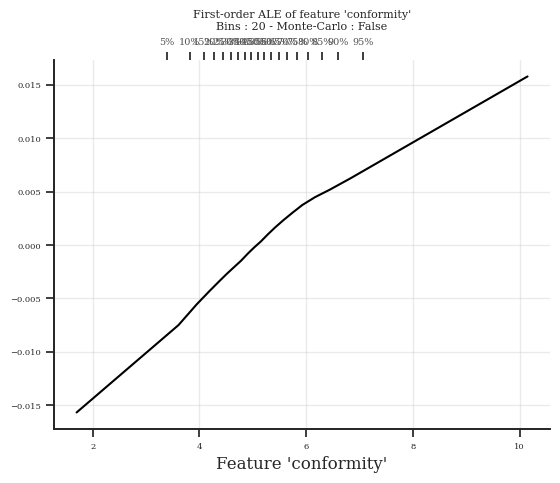

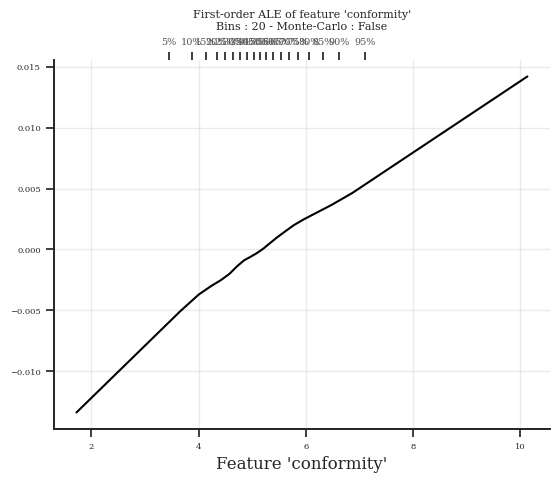

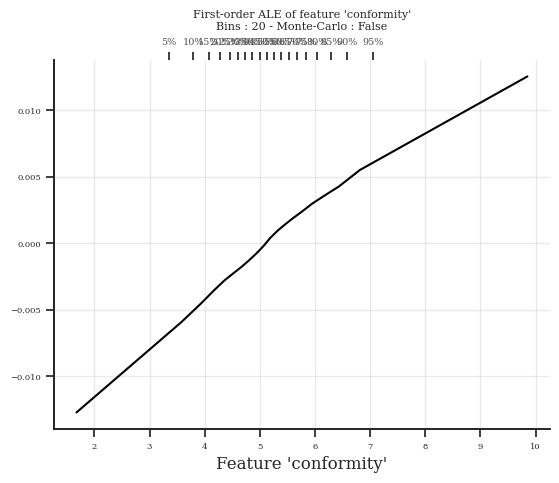

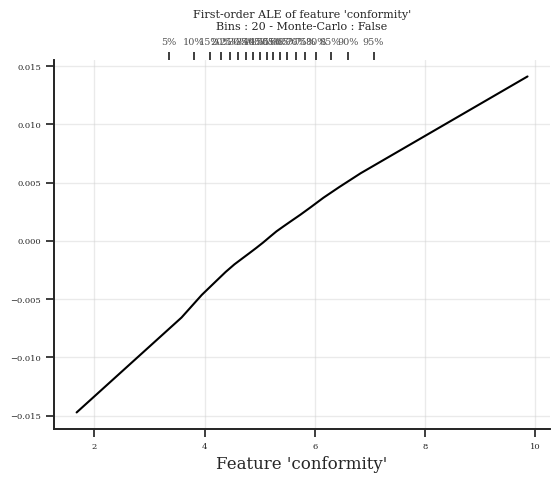

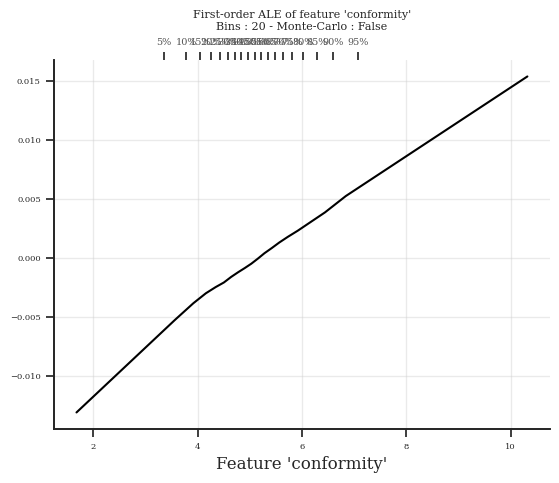

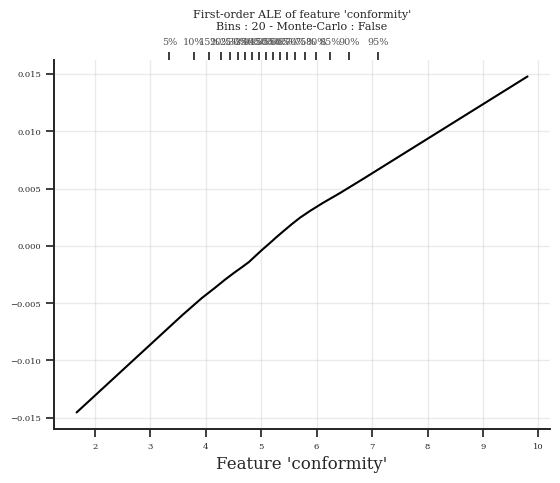

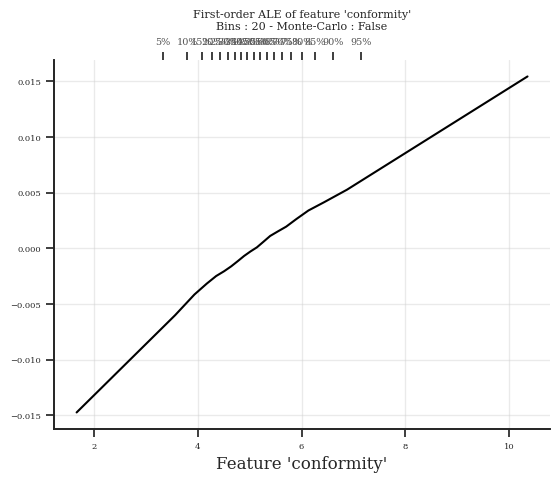

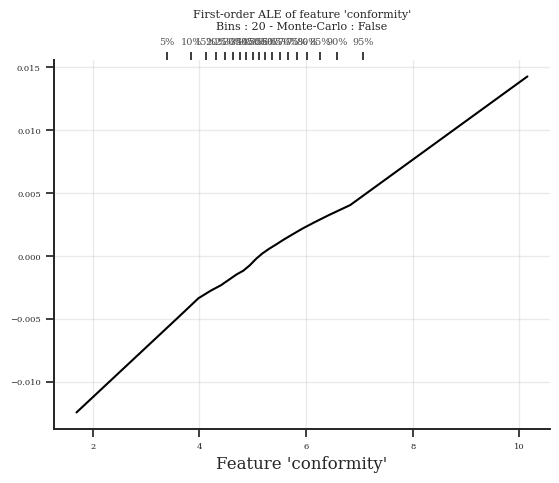

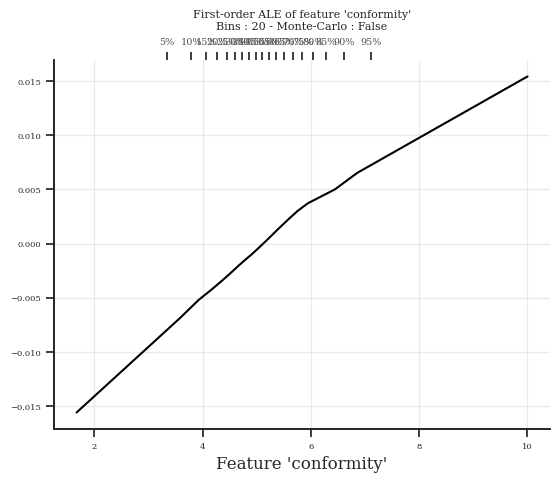

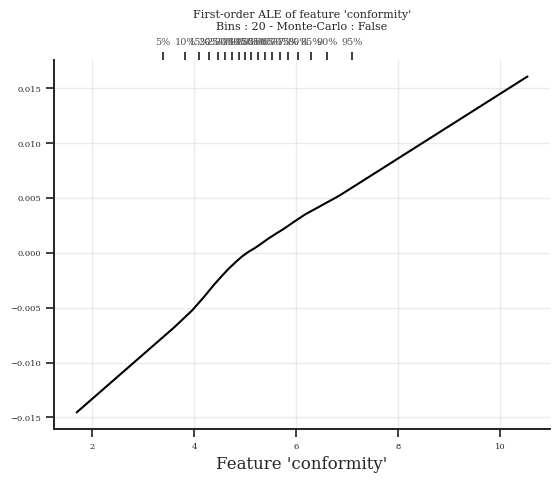

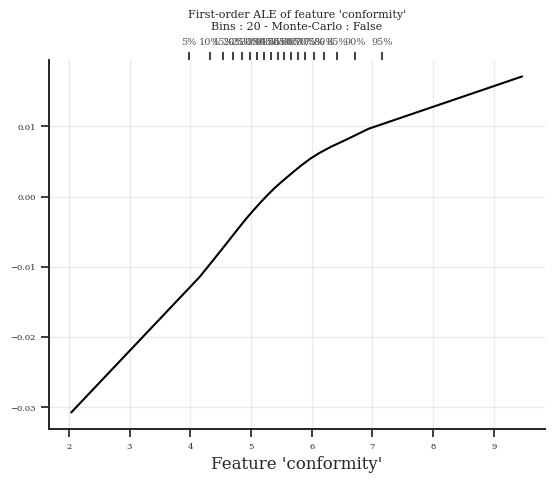

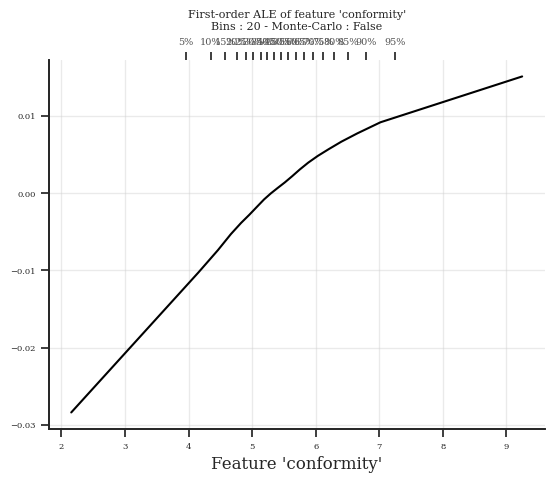

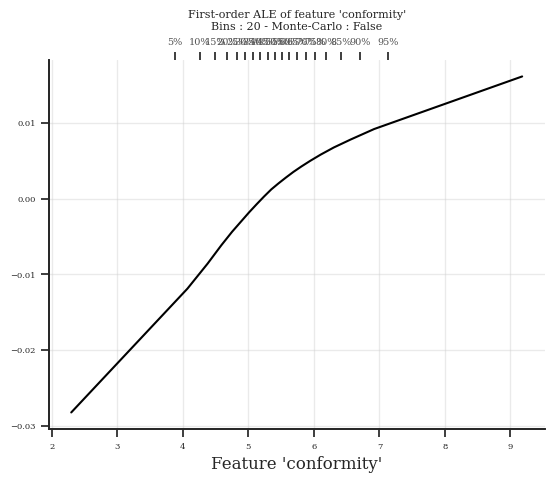

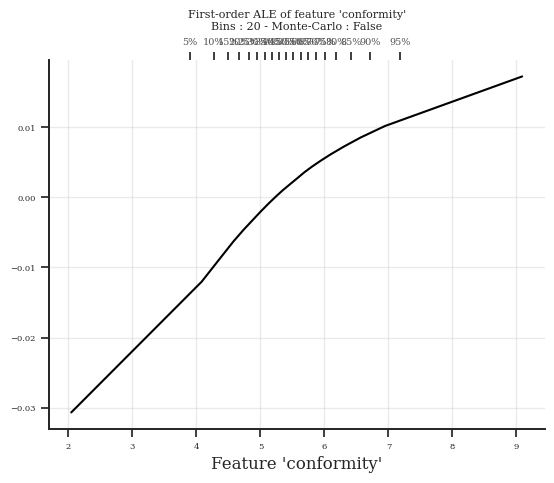

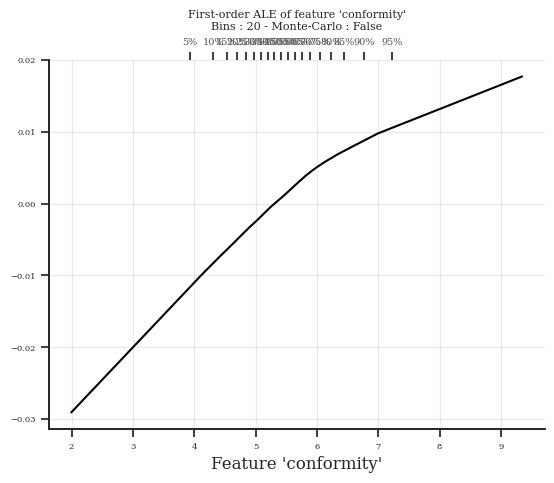

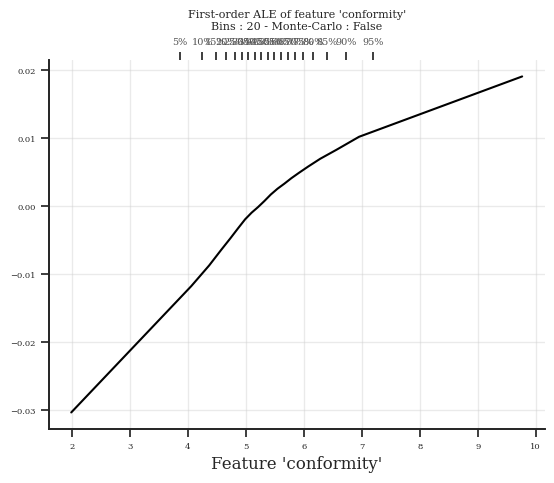

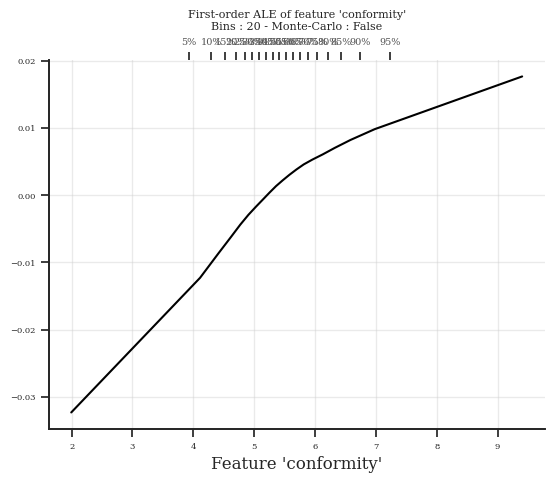

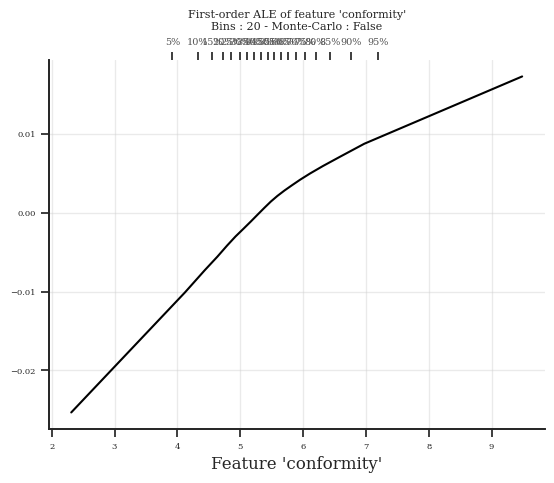

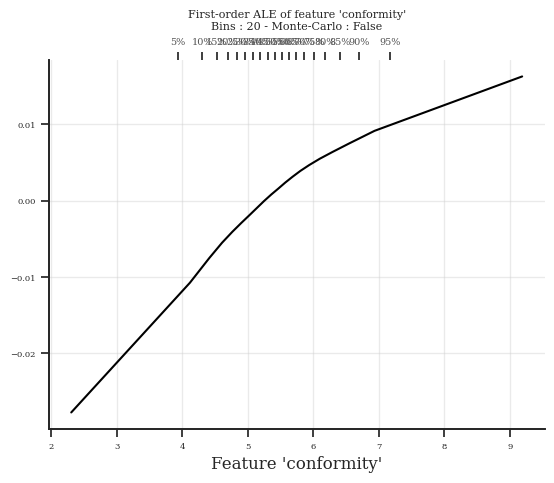

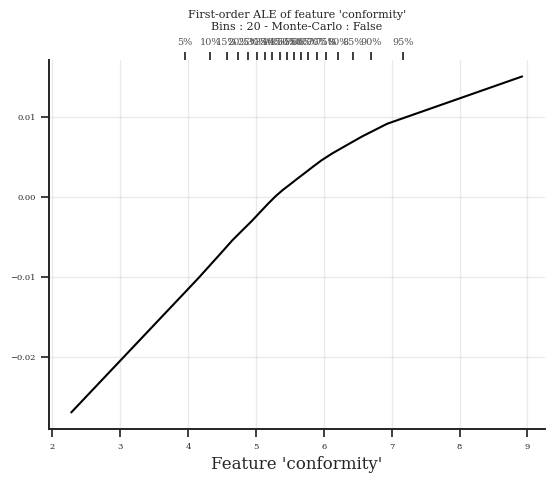

In [11]:
ALE_1ST_19 = {'RNN_Model': []}
ALE_1ST_23 = {'RNN_Model': []}
n_bootstrap = 10

for dataset, year in zip([dataset19, dataset23], ['19', '23']):
    for _ in range(n_bootstrap):
        sub_dataset = dataset_sampling(dataset, 1000)
        _, ale_1st, _ = compute_ale(sub_dataset, 'rmsn_' + str(exp_name), b_use_predicted_confounders=False, features=['conformity'], default_quantiles=quantiles)
        eval(f'ALE_1ST_{year}')['RNN_Model'].append(ale_1st)


ALE_1ST_19['RNN_Model'] = np.array(ALE_1ST_19['RNN_Model'])
ALE_1ST_23['RNN_Model'] = np.array(ALE_1ST_23['RNN_Model'])
ale_dataset_19 = create_ale_dataset(ALE_1ST_19, quantiles, dataset19['treatments'], ['RNN_Model'], 'conformity')
ale_dataset_23 = create_ale_dataset(ALE_1ST_23, quantiles, dataset23['treatments'], ['RNN_Model'], 'conformity')

In [ ]:
# 获取个体数据集
n_bootstrap = 100000
K = 3
ICE = {
    'ICE_19': [],
    'ICE_23': []
}
for dataset, ice_name in zip([dataset19, dataset23], ['ICE_19','ICE_23']):
    # 初始化新数据集
    indiv_dataset = {
        'covariates': np.zeros((n_bootstrap * 3, 161, 23), dtype='float32'),
        'outcomes': np.zeros((n_bootstrap * 3, 161, 1), dtype='float32'),
        'sequence_length': np.zeros((n_bootstrap * 3,), dtype='int64'),
        'treatments': np.zeros((n_bootstrap * 3, 161, 1), dtype='float32')
    }
    for index in range(n_bootstrap):
        indiv_dataset, chosen_idx = build_individual_dataset_fixed_offsets(
        dataset,
        n_bootstrap=n_bootstrap,   # 若不需要强行 32000，可用 overall=None 自动推断
    )
#         indiv_data = select_indiviudal_from_dataset(dataset, index)
#         start_idx = index * 3
#         end_idx = start_idx + 3

#         indiv_dataset['covariates'][start_idx:end_idx] = indiv_data['covariates']
#         indiv_dataset['outcomes'][start_idx:end_idx] = indiv_data['outcomes']
#         indiv_dataset['sequence_length'][start_idx:end_idx] = indiv_data['sequence_length']
#         indiv_dataset['treatments'][start_idx:end_idx] = indiv_data['treatments']
        
    indiv_dataframe, predictor = construct_relevant_dataframe(indiv_dataset,'rmsn_' + str(exp_name), b_use_predicted_confounders=False)

    ice = compute_ice(predictor, 
                      indiv_dataframe, 
                      ['conformity'], 
                      20, 
                      quantiles)
    ICE[ice_name] = ice

In [ ]:
ice_dataset_19 = create_ice_dataset({'RNN_Model':ICE['ICE_19']}, quantiles, ['RNN_Model'], 'conformity')
ice_dataset_23 = create_ice_dataset({'RNN_Model':ICE['ICE_23']}, quantiles, ['RNN_Model'], 'conformity')

In [ ]:
# save the sample ice data
ale_dataset_19.to_netcdf(path='figures/figure_data/fig_1d_ale19.nc')
ale_dataset_23.to_netcdf(path='figures/figure_data/fig_1d_ale23.nc')
ice_dataset_19.to_netcdf(path='figures/figure_data/fig_1d_ice19_10w.nc')
ice_dataset_23.to_netcdf(path='figures/figure_data/fig_1d_ice23_10w.nc')

### 2. plot ICE

In [4]:
ale_dataset_19 = xr.open_dataset('figures/figure_data/fig_1d_ale19.nc')
ale_dataset_23 = xr.open_dataset('figures/figure_data/fig_1d_ale23.nc')

ice_dataset_19 = xr.open_dataset('figures/figure_data/fig_1d_ice19_1w.nc')
ice_dataset_23 = xr.open_dataset('figures/figure_data/fig_1d_ice23_1w.nc')

In [5]:
replace_num = 100
feature = "conformity"
model_name = "RNN_Model"

# 1) 先检查 features 顺序一致
feat_23 = list(ice_dataset_23["features"].values)
feat_19 = list(ice_dataset_19["features"].values)
if feat_23 != feat_19:
    raise ValueError("features 顺序不一致，无法直接替换。请先对齐列顺序。")

# 2) 替换 ICE 曲线
da_name = f"{feature}__{model_name}__ice"
ice_23_vals = ice_dataset_23[da_name].values.copy()
ice_19_vals = ice_dataset_19[da_name].values
ice_23_vals[:replace_num, :] = ice_19_vals[:replace_num, :]
ice_dataset_23 = ice_dataset_23.assign(
    {da_name: (["n_bootstrap", f"n_bins__{feature}"], ice_23_vals)}
)

# 3) 同步替换 X_sampled（供 color_by 上色用）
X19 = ice_dataset_19["X_sampled"].values
ice_dataset_23 = ice_dataset_23.copy()  # 避免就地视图问题
ice_dataset_23["X_sampled"].loc[dict(n_bootstrap=slice(0, replace_num))] = X19[:replace_num, :]

In [6]:
ice_dataset_19.to_netcdf(path='figures/figure_data/fig_1d_ice19_1w_new.nc')
ice_dataset_23.to_netcdf(path='figures/figure_data/fig_1d_ice23_1w_new.nc')

测试一下自定义colorbar

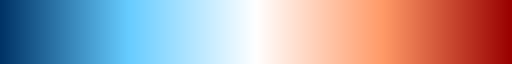

In [11]:
colors = ["#003366", "#66CCFF", "#FFFFFF", "#FF9966", "#990000"]

# 从颜色列表生成一个连续 colormap 对象
my_cmap = mcolors.LinearSegmentedColormap.from_list("111", colors)
my_cmap

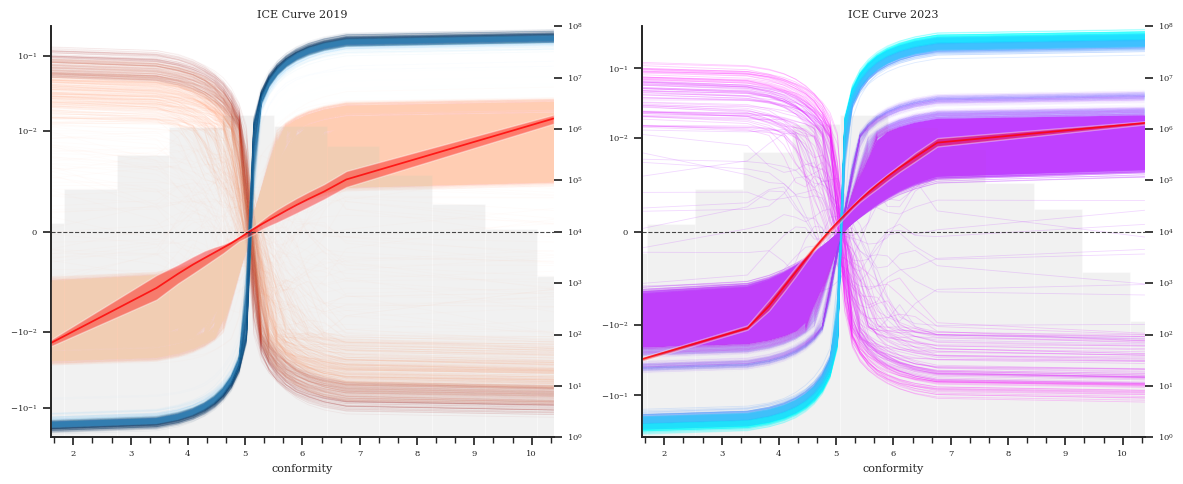

In [13]:
# 创建1×2的图窗
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1行2列的图窗，尺寸为12×6
estimator = [('RNN_Model',RandomForestRegressor())]
explainer = skexplain.ExplainToolkit(estimator)

# 绘制 RNN_Model_19 的 ALE 和 ICE 曲线

explainer.plot_ale(
    ale=ale_dataset_19,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_19,
    hist_color = 'lightgrey',
    ice_color = '#2E167E',
    ice_cmap = my_cmap,
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_alpha=0.05,
    ice_linewidth=0.6,
    wspace=0.25,
    ax=axs[0]  # 绘制在第一个子图中
)
axs[0].set_title('ICE Curve 2019')  # 设置标题

# 绘制 RNN_Model_23 的 ALE 和 ICE 曲线
explainer.plot_ale(
    ale=ale_dataset_23,
    features='conformity',
    display_units=plotting_config.display_units,
    display_feature_names=plotting_config.display_feature_names,
    ice_curves=ice_dataset_23,
    hist_color = 'lightgrey',
    ice_cmap='cool',
    color_by='first_values',
    yscale='symlog',
    y_linscale=1.2, # 越小零附近放大越强
    show_colorbar=False, 
    ice_split_threshold = [-0.05,-0.02],
    ice_alpha=[0.05,0.2],
    ice_linewidth=[0.1,0.6],
    wspace=0.25,
    ax=axs[1]  # 绘制在第二个子图中
)
axs[1].set_title('ICE Curve 2023')  # 设置标题

# 调整图窗布局
plt.tight_layout()

# 显示图窗
plt.show()